In [1]:
%load_ext autoreload
%autoreload 2

In [167]:
import re
import sys
from contextlib import contextmanager
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import yaml
from matplotlib import colors
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, VPacker
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.transforms import blended_transform_factory
from scipy import stats
from statsmodels.formula import api as smf
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd() / "notebooks" / "causal46_joined"))

from src._star_gallery import matched_n_star_plot_paper
from src.data import add_metadata_features
from src.models.sigmoid import (
    SIGMOID_2P_BOUNDS,
    SIGMOID_2P_P0_LIST,
    fit_model,
    sigmoid_model_2p,
)
from src.stimuli import PHONEME_PAIR_TO_WORD_ENDS, WORD_PHASE_DF
from src.viz_paper import (
    ACCENT_COLOR,
    ACCENT_COLOR_STRONG,
    CONJUNCTION_CATEGORIES,
    EPP_COLOR,
    F_ACOUSTIC_TYPES,
    F_EARLY,
    F_LATE,
    F_PHONEME_PAIR,
    LPP_COLOR,
    plot_behav_barplot,
    resampled_cmap,
)


In [3]:
b4_per_cell_path = "outputs/causal46_joined/t_tests/b4_per_cell.parquet"
b4_per_window_path = "outputs/causal46_joined/t_tests/b4_per_window.parquet"
a_per_window_path = "outputs/causal46_joined/acoustic_bootstrap/a_per_window_full_all.parquet"
a_per_window_by_word_end_path = "outputs/causal46_joined/acoustic_bootstrap/a_per_window_by_word_end_all.parquet"

speech_responsive_path = "outputs/causal6/find_speech_responsive"

phon_peaks_path = "outputs/causal6/acoustic_decoding_peaks/phon_peaks_all.parquet"
# early_windows_path = "outputs/causal46_joined/manual_annotations/early_acoustic_window.csv"
# filtered_manifest_path = "outputs/causal46_joined/manual_annotations/filtered_manifest.csv""

acoustic_transfer_path = "outputs/causal46_joined/acoustic_transfer/scores_all.parquet"

# per-word-end decoding at early window vs. late window
early_acoustic_decoding_summary_path = "outputs/causal46_joined/acoustic_early/acoustic_early_summary.csv"
early_acoustic_decoding_results_path = "outputs/causal46_joined/acoustic_early/acoustic_early_results.csv"
late_acoustic_decoding_summary_path = "outputs/causal46_joined/acoustic_late/acoustic_late_summary.csv"
late_acoustic_decoding_results_path = "outputs/causal46_joined/acoustic_late/acoustic_late_results.csv"

epp_path = "outputs/causal46_joined/early_perceptual_projection/all_sites.csv"
lpp_path = "outputs/causal46_joined/late_perceptual_projection/results.csv"

config_path = "config.yaml"

textgrid_dir = "textgrids"
figures_dir = "outputs/causal46_joined/figures"

alpha = 0.05

In [4]:
# Unit labeling:
# k: by early acoustic responses * word end
# n: by early acoustic responses (could combine multiple word ends)
# N: by sites (could combine multiple early acoustic responses and word ends)

RESULTS = {}

In [5]:
with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)

In [6]:
FD = Path(figures_dir)
FD.mkdir(parents=True, exist_ok=True)

In [7]:
matplotlib.rcParams.update(
    {
        "figure.dpi": 300,
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.25,
        "ytick.minor.width": 0.25,
        "lines.linewidth": 1.0,
        "font.family": "Helvetica",
        "font.sans-serif": ["Helvetica", "Arial"],
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.01,

        "mathtext.fontset": "custom",
        "mathtext.rm": "Helvetica",
        "mathtext.it": "Helvetica:italic",
        "mathtext.bf": "Helvetica:bold",
    }
)

LABEL_FONT_SIZE = plt.rcParams["axes.labelsize"]

In [8]:
def _line(*parts, align="baseline"):
    """parts: (text, color) tuples -> one horizontally packed line."""
    return HPacker(pad=0, sep=0, align=align,
                   children=[TextArea(t, textprops={"fontsize": LABEL_FONT_SIZE, "color": c})
                             for t, c in parts])

In [9]:
speech_responsive_df = pd.concat([
    pd.read_csv(p) for p in Path(speech_responsive_path).glob("*.csv")
])

In [10]:
early_acoustic_windows = pd.read_parquet("outputs/causal46_joined/acoustic_endpoint_windows/a_windows.parquet")
early_perceptual_windows = pd.read_parquet("outputs/causal46_joined/early_perceptual_windows/ep_windows.parquet")

In [11]:
acoustic_transfer_scores_all = pd.read_parquet(acoustic_transfer_path)

## Prep

In [12]:
def get_significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."

In [13]:
STAR_FIGSIZE = (3.5, 4.5)
STAR_NARROW_FIGSIZE = (2.5, 4.5)
STAR_2COL_FIGSIZE = (5, 4.5)

STAR_KWARGS = dict(
    figsize=STAR_FIGSIZE,
)

STAR_2COL_KWARGS = dict(
    figsize=STAR_2COL_FIGSIZE,
)

PDF_SAVEFIG_KWARGS = dict(
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

SUBPLOTS_KWARGS = dict(
    layout="constrained",
)
PDF_SAVEFIG_KWARGS_NEW = dict(
    dpi=300,
    transparent=True,
)

epoch_sfreq = 100
epoch_tmin = -0.4

In [14]:
other_word_end_map = {}
for w1, w2 in PHONEME_PAIR_TO_WORD_ENDS.values():
    other_word_end_map[w1] = w2
    other_word_end_map[w2] = w1

In [15]:
b4_per_cell = pl.read_parquet(b4_per_cell_path)
b4_per_window = pl.read_parquet(b4_per_window_path)

In [16]:
b4_bootstrap = pl.read_parquet("outputs/causal46_joined/t_tests/b4_bootstrap.parquet")

In [17]:
a_per_window = pl.read_parquet(a_per_window_path)
a_per_window_by_word_end = pl.read_parquet(a_per_window_by_word_end_path)

In [18]:
b4_by_behavior_windows = pd.read_parquet("outputs/causal46_joined/behavioral_discriminative_windows/b_windows.parquet")

In [19]:
epp_orig = pd.read_csv(epp_path)
epp_orig["significant"] = epp_orig.q_one_tailed < 0.05
epp_orig["significant_uncorrected"] = epp_orig.p_one_tailed < 0.05

# Retain only type1/type2
epp = epp_orig[(epp_orig.early_response_class == "acoustic_only")
               | ((epp_orig.early_response_class == "type2_aligned") & epp_orig.significant_uncorrected)]
assert epp.early_response_class.value_counts().reindex(["acoustic_only", "type2_aligned"]).notnull().all()

In [20]:
lpp = pd.read_csv(lpp_path)

In [21]:
phon_peaks = pd.read_parquet(phon_peaks_path)

### Contingency table prep

In [22]:
late_pres = (
    lpp
    .groupby(["subject", "electrode_idx", "phoneme_pair"])
    [["projection_significant", "projection_significant_uncorrected"]]
    .sum()
    .replace({
        "projection_significant": {
            0: "absent",
            1: "one-sided",
            2: "two-sided",
        },
        "projection_significant_uncorrected": {
            0: "absent",
            1: "one-sided",
            2: "two-sided",
        }
    })
    .rename(columns={"projection_significant_uncorrected": "late_category",
                     "projection_significant": "late_category_corrected"})
    .reset_index()
)

In [28]:
merged = (
    pd.merge(
        late_pres,
        (
            epp
            .assign(
                early_category=lambda df: df.early_response_class.replace({
                    "acoustic_only": "acoustic",
                    "type2_aligned": "perceptual"
                })
            )
            [["subject", "electrode_idx", "phoneme_pair",
              "early_category"]]
        ),
        on=["subject", "electrode_idx", "phoneme_pair"],
        how="outer"
    )
    # if it's not present in lpp that means there's no significant behavioral gap
    # anywhere in the late period
    .fillna({"late_category": "absent", "late_category_corrected": "absent"})
)

merged["early_label"] = merged.early_category.replace(F_EARLY.label_dict)
merged["late_label"] = merged.late_category.replace(F_LATE.label_dict)

# Track the sites that will be dropped because they were assigned a null early_label or a null late_label
dropped_sites = merged[merged["early_label"].isna() | merged["late_label"].isna()][["subject", "electrode_idx", "phoneme_pair"]]
dropped_sites = {tuple(xs) for xs in dropped_sites.values}
print(f"Dropping {len(dropped_sites)} sites with null early_label or late_label")
merged = merged.dropna(subset=["early_category", "early_label", "late_category", "late_label"])

merged["conjunction_category"] = None
for cat_name, cat_def in CONJUNCTION_CATEGORIES.items():
    early_type = cat_def["early_category"]
    late_type = cat_def["late_category"]
    if isinstance(late_type, str):
        late_type = [late_type]
    merged.loc[
        (merged["early_category"] == early_type) & (merged["late_category"].isin(late_type)),
        "conjunction_category"
    ] = cat_name

print(f"Site×pair cells total: {len(merged)}")
print("\nFlow table (rows=early type, cols=late category):")
ct = (
    merged
    .groupby(["early_category", "late_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(F_EARLY.order, axis=0)
    [list(F_LATE.order)]
)
print(ct)

# print("\nFlow table (rows=early type, cols=late category) [corrected]:")
# ct_corrected = (
#     merged
#     .groupby(["early_category_corrected", "late_category_corrected"])
#     .size()
#     .unstack(fill_value=0)
#     .reindex(EARLY_ORDER, fill_value=np.nan, axis=0)
#     # [LATE_ORDER]
# )
# print(ct_corrected)

Dropping 0 sites with null early_label or late_label
Site×pair cells total: 52

Flow table (rows=early type, cols=late category):
late_category   absent  one-sided  two-sided
early_category                              
perceptual           7          3          1
acoustic            34          7          0


### Latest round of decoding

In [29]:
early_sig_df = pd.read_csv(early_acoustic_decoding_summary_path)
# bring in smin, smax from full results
early_sig_df = pd.merge(
    early_sig_df,
    (
        pd.read_csv(early_acoustic_decoding_results_path)
        [["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]]
    ).drop_duplicates(),
    how="left",
    on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    validate="m:1",
)
# bring in phon peak information
early_sig_df = pd.merge(
    early_sig_df,
    (
        phon_peaks
        [["subject", "electrode_idx", "phoneme_pair", "test_roc_auc", "smin", "smax"]]
        .rename(columns={"test_roc_auc": "early_test_roc_auc",
                         "smin": "early_decoder_smin",
                         "smax": "early_decoder_smax"})
    ),
    how="left",
    on=["subject", "electrode_idx", "phoneme_pair"],
    validate="m:1"
)

assert pd.merge(early_sig_df[["subject", "electrode_idx", "phoneme_pair"]].drop_duplicates(),
         merged[["subject", "electrode_idx", "phoneme_pair"]].drop_duplicates(),
            how="outer", indicator=True)._merge.value_counts().loc["both"] \
            == len(early_sig_df[["subject", "electrode_idx", "phoneme_pair"]].drop_duplicates())

In [30]:
late_sig_df = pd.read_csv(late_acoustic_decoding_summary_path)
# bring in smin, smax from full results
late_sig_df = pd.merge(
    late_sig_df,
    (
        pd.read_csv(late_acoustic_decoding_results_path)
        [["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]]
    ).drop_duplicates(),
    how="left",
    on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    validate="m:1",
)
# bring in phon peak information
late_sig_df = pd.merge(
    late_sig_df,
    (
        phon_peaks
        [["subject", "electrode_idx", "phoneme_pair", "test_roc_auc", "smin", "smax"]]
        .rename(columns={"test_roc_auc": "early_test_roc_auc", "smin": "early_decoder_smin", "smax": "early_decoder_smax"})
    ),
    how="left",
    on=["subject", "electrode_idx", "phoneme_pair"],
    validate="m:1"
)

assert pd.merge(late_sig_df[["subject", "electrode_idx", "phoneme_pair"]].drop_duplicates(),
         merged[["subject", "electrode_idx", "phoneme_pair"]].drop_duplicates(),
            how="outer", indicator=True)._merge.value_counts().loc["both"] \
            == len(late_sig_df[["subject", "electrode_idx", "phoneme_pair"]].drop_duplicates())

#### Induce actual response windows

##### Early

In [31]:
early_all_acoustic_windows = (
    pd.merge(
        early_sig_df,#.query("significant_target"),
        a_per_window_by_word_end.to_pandas(),
        how="left", on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
        suffixes=("_decoder", "_bootstrap"),
    )
    .query("smin_bootstrap >= smin_decoder and smax_bootstrap <= smax_decoder")
)

early_all_acoustic_windows["mean_diff_raw_med_abs"] = early_all_acoustic_windows["mean_diff_raw_med"].abs()

GROUP_KEYS = ["subject", "electrode_idx", "phoneme_pair", "word_end", "significant_target"]
MAX_GAP = 2  # samples of separation tolerated within a union

early_all_acoustic_windows = (
    early_all_acoustic_windows
    .sort_values(GROUP_KEYS + ["smin_bootstrap"])
    .reset_index(drop=True)
)

early_all_acoustic_windows["contrast_sign"] = np.sign(early_all_acoustic_windows["mean_diff_raw_med"])

# running max of window end within each group
_run_max = (
    early_all_acoustic_windows
    .groupby(GROUP_KEYS, sort=False)["smax_bootstrap"]
    .cummax()
)

_new_group = (
    early_all_acoustic_windows[GROUP_KEYS] != early_all_acoustic_windows[GROUP_KEYS].shift(1)
).any(axis=1)
_gap = early_all_acoustic_windows["smin_bootstrap"] > _run_max.shift(1) + MAX_GAP
_sign_flip = (
    early_all_acoustic_windows["contrast_sign"]
    != early_all_acoustic_windows["contrast_sign"].shift(1)
)

_starts_new = _new_group | _gap | _sign_flip
_starts_new.iloc[0] = True

early_all_acoustic_windows["union_id"] = _starts_new.cumsum()

# collapse each union to a single interval, scored by mean contrast
early_all_acoustic_windows = (
    early_all_acoustic_windows
    .groupby(GROUP_KEYS + ["union_id"])
    .agg(
        smin_bootstrap=("smin_bootstrap", "min"),
        smax_bootstrap=("smax_bootstrap", "max"),
        smin_decoder=("smin_decoder", "first"),
        smax_decoder=("smax_decoder", "first"),
        mean_diff_raw_med_abs=("mean_diff_raw_med_abs", "mean"),
        mean_diff_raw_med=("mean_diff_raw_med", "mean"),
        n_windows=("smin_bootstrap", "size"),
        n_positive=("mean_diff_raw_med", lambda s: (s > 0).sum()),
    )
    .reset_index()
)

# retain union with largest mean contrast
early_all_acoustic_windows = (
    early_all_acoustic_windows
    .sort_values("mean_diff_raw_med_abs")
    .groupby(GROUP_KEYS).last().reset_index()
)

# compare to pod
early_all_acoustic_windows = pd.merge(
    early_all_acoustic_windows,
    WORD_PHASE_DF.set_index("phase").loc["pod"][["word", "start"]].rename(columns={"start": "t_pod"}),
    left_on="word_end", right_on="word",
    how="left", validate="m:1"
)
early_all_acoustic_windows["tcenter_bootstrap"] = (early_all_acoustic_windows["smin_bootstrap"] + early_all_acoustic_windows["smax_bootstrap"]) / 2 / epoch_sfreq + epoch_tmin
early_all_acoustic_windows["tcenter_bootstrap_from_pod"] = early_all_acoustic_windows["tcenter_bootstrap"] - early_all_acoustic_windows["t_pod"]
early_all_acoustic_windows["twidth"] = (early_all_acoustic_windows["smax_bootstrap"] - early_all_acoustic_windows["smin_bootstrap"]) / epoch_sfreq
early_all_acoustic_windows["tmin_bootstrap"] = early_all_acoustic_windows["smin_bootstrap"] / epoch_sfreq + epoch_tmin

early_sig_acoustic_windows = early_all_acoustic_windows.query("significant_target").copy()

##### Late

In [32]:
late_acoustic_windows = (
    pd.merge(
        late_sig_df.query("significant_target"),
        a_per_window_by_word_end.to_pandas(),
        how="left", on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
        suffixes=("_decoder", "_bootstrap"),
    )
    .query("smin_bootstrap >= smin_decoder and smax_bootstrap <= smax_decoder")
)

late_acoustic_windows["mean_diff_raw_med_abs"] = late_acoustic_windows["mean_diff_raw_med"].abs()

GROUP_KEYS = ["subject", "electrode_idx", "phoneme_pair", "word_end"]
MAX_GAP = 2  # samples of separation tolerated within a union

late_acoustic_windows = (
    late_acoustic_windows
    .sort_values(GROUP_KEYS + ["smin_bootstrap"])
    .reset_index(drop=True)
)

late_acoustic_windows["contrast_sign"] = np.sign(late_acoustic_windows["mean_diff_raw_med"])

# running max of window end within each group
_run_max = (
    late_acoustic_windows
    .groupby(GROUP_KEYS, sort=False)["smax_bootstrap"]
    .cummax()
)

_new_group = (
    late_acoustic_windows[GROUP_KEYS] != late_acoustic_windows[GROUP_KEYS].shift(1)
).any(axis=1)
_gap = late_acoustic_windows["smin_bootstrap"] > _run_max.shift(1) + MAX_GAP
_sign_flip = (
    late_acoustic_windows["contrast_sign"]
    != late_acoustic_windows["contrast_sign"].shift(1)
)

_starts_new = _new_group | _gap | _sign_flip
_starts_new.iloc[0] = True

late_acoustic_windows["union_id"] = _starts_new.cumsum()

# collapse each union to a single interval, scored by mean contrast
late_acoustic_windows = (
    late_acoustic_windows
    .groupby(GROUP_KEYS + ["union_id", "s_early_offset"])
    .agg(
        smin_bootstrap=("smin_bootstrap", "min"),
        smax_bootstrap=("smax_bootstrap", "max"),
        smin_decoder=("smin_decoder", "first"),
        smax_decoder=("smax_decoder", "first"),
        mean_diff_raw_med_abs=("mean_diff_raw_med_abs", "mean"),
        mean_diff_raw_med=("mean_diff_raw_med", "mean"),
        n_windows=("smin_bootstrap", "size"),
        n_positive=("mean_diff_raw_med", lambda s: (s > 0).sum()),
    )
    .reset_index()
)

# retain union with largest mean contrast
late_acoustic_windows = (
    late_acoustic_windows
    .sort_values("mean_diff_raw_med_abs")
    .groupby(GROUP_KEYS + ["s_early_offset"]).last().reset_index()
)

# compare to pod
late_acoustic_windows = pd.merge(
    late_acoustic_windows,
    WORD_PHASE_DF.set_index("phase").loc["pod"][["word", "start"]].rename(columns={"start": "t_pod"}),
    left_on="word_end", right_on="word",
    how="left", validate="m:1"
)
late_acoustic_windows["tcenter_bootstrap"] = (late_acoustic_windows["smin_bootstrap"] + late_acoustic_windows["smax_bootstrap"]) / 2 / epoch_sfreq + epoch_tmin
late_acoustic_windows["tcenter_bootstrap_from_pod"] = late_acoustic_windows["tcenter_bootstrap"] - late_acoustic_windows["t_pod"]
late_acoustic_windows["twidth"] = (late_acoustic_windows["smax_bootstrap"] - late_acoustic_windows["smin_bootstrap"]) / epoch_sfreq

late_acoustic_windows["t_early_offset"] = late_acoustic_windows["s_early_offset"] / epoch_sfreq + epoch_tmin
late_acoustic_windows["tcenter_from_early_offset"] = late_acoustic_windows["tcenter_bootstrap"] - late_acoustic_windows["t_early_offset"]

late_acoustic_windows["tmin_bootstrap"] = late_acoustic_windows["smin_bootstrap"] / epoch_sfreq + epoch_tmin
late_acoustic_windows["tmin_bootstrap_from_pod"] = late_acoustic_windows["tmin_bootstrap"] - late_acoustic_windows["t_pod"]
late_acoustic_windows["tmin_from_early_offset"] = late_acoustic_windows["tmin_bootstrap"] - late_acoustic_windows["t_early_offset"]

late_acoustic_windows["lexical_evidence"] = (late_acoustic_windows.word_end.str[0] != late_acoustic_windows.phoneme_pair.str[0]).astype(int)
late_acoustic_windows["late_acoustic_tuning_dummy"] = (late_acoustic_windows.mean_diff_raw_med > 0).astype(int)
late_acoustic_windows["late_acoustic_tuning"] = late_acoustic_windows.apply(
    lambda xs: xs.phoneme_pair[xs.late_acoustic_tuning_dummy], axis=1
)

late_acoustic_windows["late_acoustic_tuning_matches_we"] = late_acoustic_windows["late_acoustic_tuning"] == late_acoustic_windows["word_end"].str[0]

### Response counts

In [33]:
ct

late_category,absent,one-sided,two-sided
early_category,,,
perceptual,7,3,1
acoustic,34,7,0


In [34]:
ct.loc["perceptual"].sum() / ct.sum().sum()

np.float64(0.21153846153846154)

In [35]:
ct.loc["acoustic"].sum()

np.int64(41)

In [36]:
ct[["one-sided", "two-sided"]].sum().sum(), \
     ct[["one-sided", "two-sided"]].sum().sum() / ct.sum().sum()

(np.int64(11), np.float64(0.21153846153846154))

### Site counts

In [37]:
print("Sites with a perceptual effect:")
print(
    merged.assign(early_perceptual=lambda df: df.early_category == "perceptual")
    .groupby(["subject", "electrode_idx"])
    .early_perceptual.any()
    .agg(["sum", "mean"])
)

print("Sites without a perceptual effect:")
print(
    merged.assign(early_perceptual=lambda df: df.early_category == "perceptual")
    .groupby(["subject", "electrode_idx"])
    .early_perceptual.apply(lambda x: ~x.any())
    .agg(["sum", "mean"])
)

Sites with a perceptual effect:
sum     11.00
mean     0.25
Name: early_perceptual, dtype: float64
Sites without a perceptual effect:
sum     33.00
mean     0.75
Name: early_perceptual, dtype: float64


In [38]:
(
    merged.assign(has_late_response=lambda df: df.late_category != "absent")
    .groupby(["subject", "electrode_idx"])
    .has_late_response.any()
    .agg(["sum", "mean"])
)

sum     10.000000
mean     0.227273
Name: has_late_response, dtype: float64

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


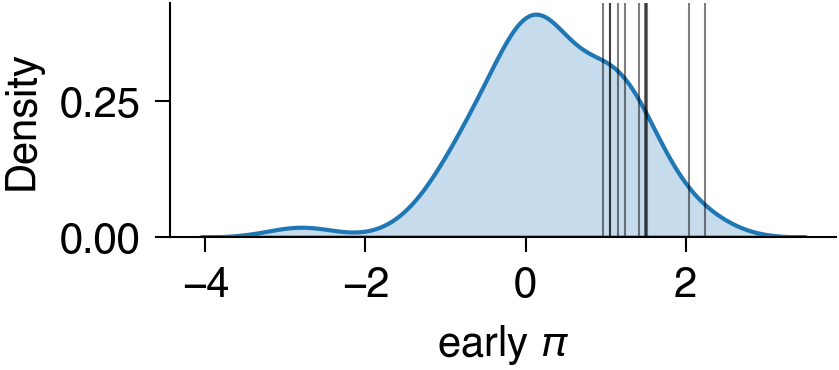

In [39]:
g = sns.displot(data=epp, x="pi_pooled", kind="kde",
                fill=True, height=1.5, aspect=2)
g.set_axis_labels(r"early $\pi$")
for _, row in epp.query("significant_uncorrected").iterrows():
    g.ax.axvline(row.pi_pooled, color="black", alpha=0.5, lw=0.5)

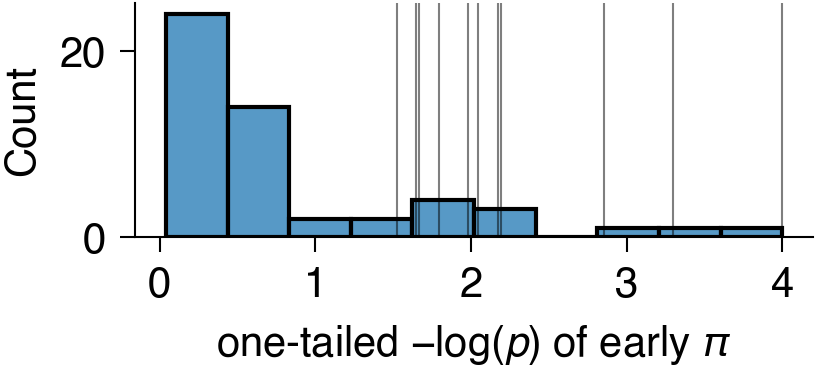

In [40]:
g = sns.displot(data=epp.assign(logp_one_tailed=-np.log10(epp["p_one_tailed"])),
                x="logp_one_tailed", kind="hist",
                fill=True, height=1.5, aspect=2)
g.set_axis_labels(r"one-tailed $-\log(p)$ of early $\pi$")
for _, row in epp.query("significant_uncorrected").iterrows():
    g.ax.axvline(-np.log10(row.p_one_tailed), color="black", alpha=0.5, lw=0.5)

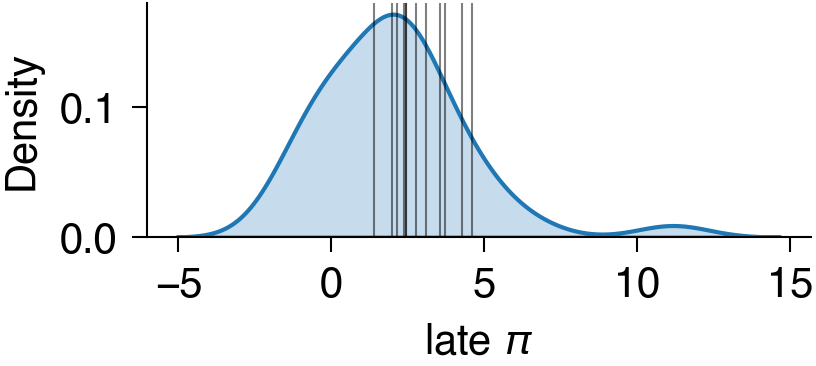

In [41]:
g = sns.displot(data=lpp.assign(projection_logp=lambda df: -np.log10(df["projection_p_value"])),
                x="projection", kind="kde",
                fill=True, height=1.5, aspect=2)
g.set_axis_labels(r"late $\pi$")
for _, row in lpp.query("projection_significant_uncorrected").iterrows():
    g.ax.axvline(row.projection, color="black", alpha=0.5, lw=0.5)

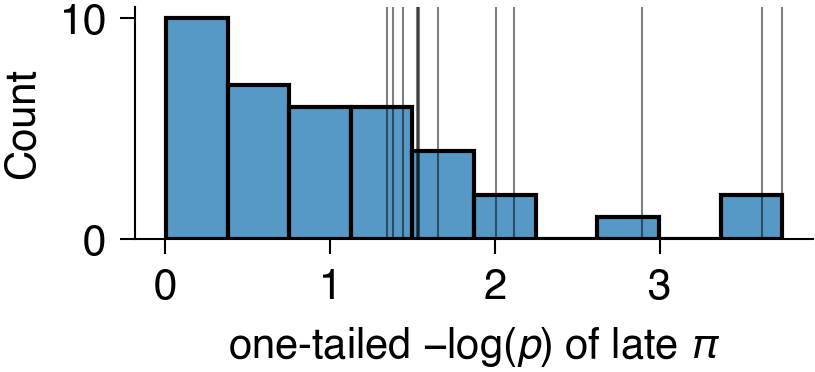

In [42]:
g = sns.displot(data=lpp.assign(projection_logp=lambda df: -np.log10(df["projection_p_value"])),
                x="projection_logp",
                kind="hist", bins=10,
                fill=True, height=1.5, aspect=2)
g.set_axis_labels(r"one-tailed $-\log(p)$ of late $\pi$")
for _, row in lpp.query("projection_significant_uncorrected").iterrows():
    g.ax.axvline(-np.log10(row.projection_p_value), color="black", alpha=0.5, lw=0.5)

In [43]:
merged.to_csv(FD / "merged_early_late_categories.csv", index=False)

In [44]:
epochs_dict = {}
for p in Path("outputs/epochs_preprocessed").glob("*.fif"):
    ep = mne.read_epochs(p, verbose=False)
    ep.metadata = add_metadata_features(ep.metadata)
    epochs_dict[p.stem.rstrip("_epo")] = ep

Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 107 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns


In [45]:
RESULTS["n_subjects"] = len(epochs_dict)
RESULTS["n_subjects_lh"] = (speech_responsive_df.groupby("subject").x.min() < 0).sum()

('perceptual', '#4e79a7', 'Perceptual')


In [46]:
all_md = pl.concat([pl.from_pandas(
        ep.metadata[["phoneme_pair", "word_end", "resampled", "behavior_dummy_forced", "label_behavior"]].rename_axis("epoch_idx").reset_index()
    ).with_columns(pl.lit(subject).alias("subject")) for subject, ep in epochs_dict.items()])

### Early window prep

In [47]:
# Only retain sites that are in `merged`
early_acoustic_windows = pd.merge(
    early_acoustic_windows,
    merged[["subject", "electrode_idx", "phoneme_pair"]],
    on=["subject", "electrode_idx", "phoneme_pair"],
    how="inner",
)

In [48]:
early_perceptual_windows = pd.merge(
    early_perceptual_windows,
    merged[["subject", "electrode_idx", "phoneme_pair"]],
    on=["subject", "electrode_idx", "phoneme_pair"],
    how="inner",
)

### Acoustic transfer prep

In [49]:
# Subset: only retain sites that have sig late results
acoustic_transfer_scores = pd.merge(
    acoustic_transfer_scores_all,
    lpp[["subject", "electrode_idx", "phoneme_pair", "word_end",
         "projection_p_value"]],
    how="inner",
    on=["subject", "electrode_idx", "phoneme_pair", "word_end"]
).query(f"projection_p_value < {alpha}")

# Take the latest behavioral window for each cell
acoustic_transfer_scores = (
    acoustic_transfer_scores
    .sort_values("window_id")
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "fold"])
    .last()
    .reset_index()
)

In [50]:
CELL_KEYS = ["subject", "electrode_idx", "phoneme_pair", "word_end", "window_id",
             "phon_smin", "phon_smax", "behav_smin", "behav_smax",
             "late_projection", "late_projection_p_value", "late_projection_q_value"]

# Mean acoustic decoding performance across folds at the two windows
acoustic_cell_means = (
    acoustic_transfer_scores
    .groupby(CELL_KEYS)
    [["phon_roc_auc", "behav_roc_auc"]]
    .mean()
    .reset_index()
    .assign(
        phon_tcenter=lambda df: (df["phon_smin"] + df["phon_smax"]) / 2 / epoch_sfreq + epoch_tmin,
        behav_tcenter=lambda df: (df["behav_smin"] + df["behav_smax"]) / 2 / epoch_sfreq + epoch_tmin,
    )
)

## Plot

In [54]:
def prepare_star_plot(subject, electrode_idx, phoneme_pair, word_end):
    row = b4_per_cell.filter(
        (pl.col("subject") == subject)
        & (pl.col("electrode_idx") == electrode_idx)
        & (pl.col("phoneme_pair") == phoneme_pair)
        & (pl.col("word_end") == word_end)
    ).to_pandas()

    sig_wins = None
    mda = None
    qs = None

    if row.empty:
        # find phon_smin, phon_smax from the companion WE
        other_we = [we for we in PHONEME_PAIR_TO_WORD_ENDS[phoneme_pair] if we != word_end][0]
        other_row = b4_per_cell.filter(
            (pl.col("subject") == subject)
            & (pl.col("electrode_idx") == electrode_idx)
            & (pl.col("phoneme_pair") == phoneme_pair)
            & (pl.col("word_end") == other_we)
        ).to_pandas().iloc[0]
        row = {
            "subject": subject,
            "electrode_idx": electrode_idx,
            "phoneme_pair": phoneme_pair,
            "word_end": word_end,
            "qualifying_steps": [],
            "n_per_class": 0,
            "phon_smin": other_row["phon_smin"],
            "phon_smax": other_row["phon_smax"],
        }
    else:
        row = row.iloc[0]

        qs = row.get("qualifying_steps")
        if isinstance(qs, str):
            qs = [int(s) for s in qs.split(",") if s]
        else:
            qs = [int(s) for s in qs] if qs is not None else []

        site_pw = b4_per_window.filter((pl.col("subject") == row["subject"])
            & (pl.col("electrode_idx") == row["electrode_idx"])
            & (pl.col("phoneme_pair") == row["phoneme_pair"])
            & (pl.col("word_end") == row["word_end"])) if b4_per_window.height else pl.DataFrame()
    
        if site_pw.height:
            pw_s = site_pw.sort("tmin")
            sig_list = [
                (float(r["tmin"]), float(r["tmax"]))
                for r in pw_s.filter(pl.col("ci_aligned_excludes_zero")).iter_rows(named=True)
            ]
            sig_wins = sig_list or None
            mda = {
                "tcenter": ((pw_s["tmin"] + pw_s["tmax"]) / 2).to_numpy().astype(float),
                "mean": pw_s["mean_diff_aligned_mean"].to_numpy().astype(float),
                "ci_lo": pw_s["mean_diff_aligned_ci_lo"].to_numpy().astype(float),
                "ci_hi": pw_s["mean_diff_aligned_ci_hi"].to_numpy().astype(float),
            }

    qs = qs or []

    epp_row = epp.query(f"subject == '{subject}' and electrode_idx == {electrode_idx} and phoneme_pair == '{phoneme_pair}'")
    lpp_row = lpp.query(f"subject == '{subject}' and electrode_idx == {electrode_idx} and phoneme_pair == '{phoneme_pair}' and word_end == '{word_end}'")

    return row, qs, epp_row, lpp_row, sig_wins, mda


def plot_both(subject, electrode_idx, phoneme_pair,
              figsize=(9, 4.5), sharey=True, **kwargs):
    word_ends = PHONEME_PAIR_TO_WORD_ENDS[phoneme_pair]
    f, axs = plt.subplots(figsize=figsize, nrows=2, ncols=2,
                          sharex=True, sharey=sharey, **SUBPLOTS_KWARGS)

    for i, we in enumerate(word_ends):
        plot(subject, electrode_idx, phoneme_pair, we,
             figsize=(figsize[0] / 2, figsize[1]),
             axs=axs[:, i],
             **kwargs)

    axs[0, 1].set_ylabel(None)
    axs[1, 1].set_ylabel(None)

    # why are xticklabels missing? fix
    for ax in axs[1, :]:
        # if not ax.get_xticklabels():
        ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())

    return axs


def plot_both_unambiguous_only(subject, electrode_idx, phoneme_pair, figsize=(9, 4.5), **kwargs):
    """
    Plot both word-ends but only endpoint/unambiguous trials
    """
    axs = plot_both(
        subject=subject,
        electrode_idx=electrode_idx,
        phoneme_pair=phoneme_pair,
        figsize=figsize,
        **kwargs
    )

    for j, ax in enumerate(axs[1, :]):
        ax.remove()
    f = plt.gcf()
    ncols = axs.shape[1]
    gs = GridSpec(1, ncols, figure=f)
    for j, ax in enumerate(axs[0, :]):
        ax.set_subplotspec(gs[0, j])

        # why are xticklabels missing? fix
        ax.tick_params(axis="x", which="both", labelsize=8, labelbottom=True)
        ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())

    return axs[0, :]


def plot(subject, electrode_idx, phoneme_pair, word_end,
         plot_phon_window=False,
         plot_epp=True, plot_lpp=True,
         plot_early_acoustic=False,
         plot_late_acoustic=False,
         figsize=(4.5, 4.5),
         axs=None, qs=None, resampled_cmap=resampled_cmap,
         **kwargs):
    row, qs_default, epp_row, lpp_row, sig_wins, mda = prepare_star_plot(
        subject, electrode_idx, phoneme_pair, word_end)
    
    # allow qs override
    if qs is None:
        qs = qs_default
        print("Using qualifying steps from b4_per_cell:", qs)
    if len(qs) == 0:
        print(f"No qualifying steps for {subject} {electrode_idx} {phoneme_pair} {word_end}")
        return None

    if plot_phon_window:
        phon_smin, phon_smax = int(row["phon_smin"]), int(row["phon_smax"])
    else:
        phon_smin, phon_smax = None, None

    top_early_window, top_late_window = None, None
    bottom_early_window, bottom_late_window = None, None
    if plot_epp:
        bottom_early_window = epp_row.iloc[0][["window_smin", "window_smax"]].values if not epp_row.empty and epp_row.iloc[0].significant_uncorrected else None
    if plot_early_acoustic:
        early_acoustic_row = early_all_acoustic_windows[
            (early_all_acoustic_windows.subject == subject) &
            (early_all_acoustic_windows.electrode_idx == electrode_idx) &
            (early_all_acoustic_windows.phoneme_pair == phoneme_pair) &
            (early_all_acoustic_windows.word_end == word_end)
        ]
        top_early_window = early_acoustic_row.iloc[0][["smin_bootstrap", "smax_bootstrap"]].values if not early_acoustic_row.empty else None

    if plot_lpp:
        bottom_late_window = lpp_row.iloc[0][["smin", "smax"]].values if not lpp_row.empty and lpp_row.iloc[0].projection_significant_uncorrected else None
    if plot_late_acoustic:
        late_acoustic_row = late_acoustic_windows[
            (late_acoustic_windows.subject == subject) &
            (late_acoustic_windows.electrode_idx == electrode_idx) &
            (late_acoustic_windows.phoneme_pair == phoneme_pair) &
            (late_acoustic_windows.word_end == word_end)
        ]
        top_late_window = late_acoustic_row.iloc[0][["smin_bootstrap", "smax_bootstrap"]].values if not late_acoustic_row.empty else None

    f = matched_n_star_plot_paper(
        subject=row["subject"],
        electrode_idx=int(row["electrode_idx"]),
        phoneme_pair=row["phoneme_pair"],
        word_end=row["word_end"],
        qualifying_steps=list(qs),
        epochs_dict=epochs_dict,

        top_early_window=top_early_window,
        top_late_window=top_late_window,
        bottom_early_window=bottom_early_window,
        bottom_late_window=bottom_late_window,

        phon_smin=phon_smin,
        phon_smax=phon_smax,

        textgrid_dir=textgrid_dir,
        resampled_cmap=resampled_cmap,
        figsize=figsize,
        axs=axs,
        **kwargs,
    )

    # f.axes[0].set_xticklabels([])

    return f

## Fig 1: example electrodes

In [55]:
@contextmanager
def plot_1_example(
        subject, electrode_idx, phoneme_pair, word_end,
        xlim=None,
        qualifying_steps=None,
        behav_figsize=(1.2, 1.4),
        behav_hspace=0.7,
        file_prefix=None,
        width_multiplier=1.0,
        savefig=True,
        close=True,
        **hga_kwargs
    ):
    hga_height = 4
    _f_hga = plot(
        subject=subject,
        electrode_idx=electrode_idx,
        phoneme_pair=phoneme_pair,
        word_end=word_end,
        qs=qualifying_steps,
        plot_phonemes=True,
        plot_pod=True,
        figsize=(3, hga_height),
        resampled_cmap=resampled_cmap,
        xlim=xlim,
        **hga_kwargs
    )

    f_bhv, (ax_bhv_unambig, ax_bhv_ambig) = \
        plt.subplots(figsize=behav_figsize, nrows=2, ncols=1,
                     gridspec_kw={'height_ratios': [1.2, 1], "hspace": behav_hspace},
                     sharex=True)

    plot_behav_barplot(
        all_md=all_md,
        plot_subject=subject,
        plot_phoneme_pair=phoneme_pair,
        plot_word_end=word_end,
        plot_resampled_steps=[1, 6],
        resampled_palette=resampled_cmap,
        # figsize=(1.5, 0.7),
        legend=False,
        collapse_zero_bars=True,
        ax=ax_bhv_unambig
    )
    ax_bhv_unambig.set_xlabel(None)
    ax_bhv_unambig.set_xticklabels([])

    plot_behav_barplot(
        all_md=all_md,
        plot_subject=subject,
        plot_phoneme_pair=phoneme_pair,
        plot_word_end=word_end,
        plot_resampled_steps=qualifying_steps,
        resampled_palette=resampled_cmap,
        # figsize=(1.5, 1.3 * 0.8),
        legend=False,
        ax=ax_bhv_ambig
    )

    # behav plots shared ylabel
    # ax_bhv_ambig.set_ylabel(None)
    # ax_bhv_unambig.set_ylabel(None)
    # f_bhv.supylabel("Step", x=-0.2)

    for ax in _f_hga.axes:
        ax.set_ylabel(None)
    _f_hga.axes[0].set_ylabel("HGA (z)")

    try:
        yield _f_hga, f_bhv
    finally:
        if savefig:
            _f_hga.savefig(FD / f"{file_prefix}_hga.pdf", **PDF_SAVEFIG_KWARGS)
            f_bhv.savefig(FD / f"{file_prefix}_bhv.pdf", **PDF_SAVEFIG_KWARGS)

        if close:
            plt.close(_f_hga)
            plt.close(f_bhv)

Applying baseline correction (mode: mean)


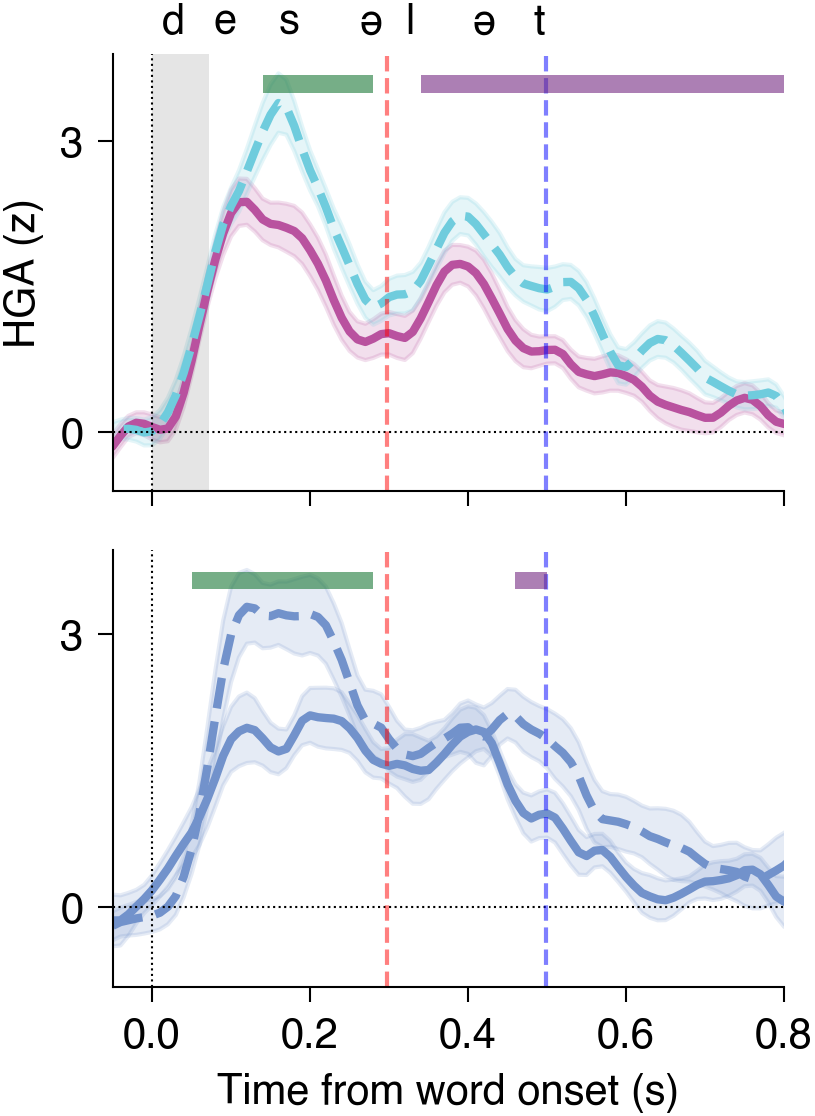

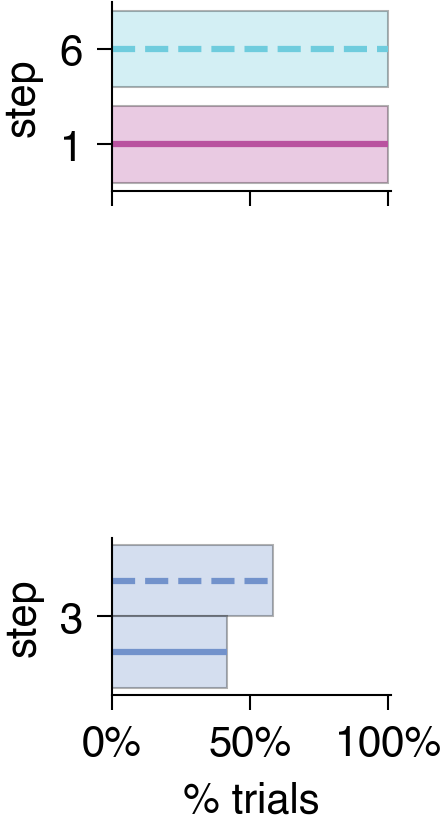

In [ ]:
# This has a nice pattern in the ambig trials but is not significant in the unambig trials
# so not a good example
plot_1a_subject = "EC253"
plot_1a_electrode_idx = 197
plot_1a_phoneme_pair = "dn"
plot_1a_lexical_evidence = 0
plot_1a_word_end = "desolate"
plot_1a_qualifying_steps = [3]

with plot_1_example(
    subject=plot_1a_subject,
    electrode_idx=plot_1a_electrode_idx,
    phoneme_pair=plot_1a_phoneme_pair,
    word_end=plot_1a_word_end,
    qualifying_steps=plot_1a_qualifying_steps,

    plot_early_acoustic=True,
    plot_late_acoustic=True,

    behav_figsize=(1.2, 3),
    behav_hspace=2,

    # xlim=0.6,
    xlim=0.8,
    file_prefix="plot_1a",
) as (f_hga, f_bhv):
    for ax in f_hga.axes:
        ax.set_yticks([0, 3])

RESULTS["e1_word_end"] = plot_1a_word_end
RESULTS["e1_word_end_stripped"] = plot_1a_word_end[1:]
RESULTS["e1_word_end_other_phoneme"] = plot_1a_phoneme_pair[1 - plot_1a_lexical_evidence] + plot_1a_word_end[1:]

RESULTS["e1_behavior_chose_consistent"] = (
    (
        all_md
        .to_pandas()
        .query(f"subject == '{plot_1a_subject}' and phoneme_pair == '{plot_1a_phoneme_pair}' and word_end == '{plot_1a_word_end}' and resampled in {plot_1a_qualifying_steps}")
        .behavior_dummy_forced == plot_1a_lexical_evidence
    ).sum()
)
RESULTS["e1_behavior_chose_inconsistent"] = (
    (
        all_md
        .to_pandas()
        .query(f"subject == '{plot_1a_subject}' and phoneme_pair == '{plot_1a_phoneme_pair}' and word_end == '{plot_1a_word_end}' and resampled in {plot_1a_qualifying_steps}")
        .behavior_dummy_forced != plot_1a_lexical_evidence
    ).sum()
)

plot_1a_late_acoustic_row = late_sig_df.query(f"subject == '{plot_1a_subject}' and electrode_idx == {plot_1a_electrode_idx} and word_end == '{plot_1a_word_end}'").iloc[0]
RESULTS["e1_late_acoustic_decoding_roc_auc"] = plot_1a_late_acoustic_row.real_test_roc_auc
RESULTS["e1_late_acoustic_decoding_p"] = plot_1a_late_acoustic_row.p_value_target
RESULTS["e1_late_acoustic_decoding_q"] = plot_1a_late_acoustic_row.p_value_target_fdr

plot_1a_late_acoustic_window = late_acoustic_windows.query(f"subject == '{plot_1a_subject}' and electrode_idx == {plot_1a_electrode_idx} and word_end == '{plot_1a_word_end}'").iloc[0]
RESULTS["e1_late_acoustic_contrast_latency"] = plot_1a_late_acoustic_window.tmin_bootstrap
plot_1a_late_perceptual_window = lpp.query(f"subject == '{plot_1a_subject}' and electrode_idx == {plot_1a_electrode_idx} and word_end == '{plot_1a_word_end}'").iloc[0]
RESULTS["e1_late_perceptual_contrast_latency"] = plot_1a_late_perceptual_window.tmin
RESULTS["e1_late_perceptual_contrast_pod_latency"] = plot_1a_late_perceptual_window.tmin - WORD_PHASE_DF.query(f"word == '{plot_1a_word_end}' and phase == 'pod'").iloc[0].start
RESULTS["e1_late_perceptual_contrast_p"] = plot_1a_late_perceptual_window.projection_p_value
RESULTS["e1_late_perceptual_contrast_q"] = plot_1a_late_perceptual_window.projection_q_value

plot_1a_early_perceptual_window = epp.query(f"subject == '{plot_1a_subject}' and electrode_idx == {plot_1a_electrode_idx}").iloc[0]
RESULTS["e1_early_perceptual_contrast_p"] = plot_1a_early_perceptual_window.p_one_tailed
RESULTS["e1_early_perceptual_contrast_q"] = plot_1a_early_perceptual_window.q_one_tailed

In [57]:
plot_1b_subject = "EC253"
plot_1b_electrode_idx = 197
plot_1b_phoneme_pair = "pb"
plot_1b_word_end = "beneficial"
plot_1b_qualifying_steps = [4]

with plot_1_example(
    subject=plot_1b_subject,
    electrode_idx=plot_1b_electrode_idx,
    phoneme_pair=plot_1b_phoneme_pair,
    word_end=plot_1b_word_end,
    qualifying_steps=plot_1b_qualifying_steps,
    xlim=0.6,
    file_prefix="plot_1b",
) as (f_hga, f_bhv):
    for ax in f_hga.axes:
        ax.set_yticks([0, 3])

Applying baseline correction (mode: mean)


In [58]:
late_acoustic_windows

,subject,electrode_idx,phoneme_pair,word_end,s_early_offset,union_id,smin_bootstrap,smax_bootstrap,smin_decoder,smax_decoder,...,twidth,t_early_offset,tcenter_from_early_offset,tmin_bootstrap,tmin_bootstrap_from_pod,tmin_from_early_offset,lexical_evidence,late_acoustic_tuning_dummy,late_acoustic_tuning,late_acoustic_tuning_matches_we
0,EC243,87,dn,desolate,64,3,70,80,64,139,...,0.10,0.24,0.11,0.30,0.003,0.06,0,0,d,True
1,EC243,101,dn,desolate,76,8,92,138,76,139,...,0.46,0.36,0.39,0.52,0.223,0.16,0,1,n,False
2,EC243,102,dn,desolate,74,10,84,138,74,139,...,0.54,0.34,0.37,0.44,0.143,0.10,0,1,n,False
3,EC243,102,dn,necessary,74,11,74,138,74,139,...,0.64,0.34,0.32,0.34,0.043,0.00,1,0,d,False
4,EC243,105,dn,necessary,68,12,68,138,68,139,...,0.70,0.28,0.35,0.28,-0.017,0.00,1,0,d,False
5,EC250,195,dn,desolate,74,14,78,138,74,139,...,0.60,0.34,0.34,0.38,0.083,0.04,0,1,n,False
6,EC250,215,pb,beneficial,76,17,82,122,76,122,...,0.40,0.36,0.26,0.42,0.208,0.06,1,0,p,False
7,EC250,215,pb,penecillin,76,18,76,112,76,122,...,0.36,0.36,0.18,0.36,0.148,0.00,0,1,b,False
8,EC250,216,bm,mountains,98,21,98,118,98,118,...,0.20,0.58,0.10,0.58,0.246,0.00,1,0,b,False
9,EC250,216,pb,penecillin,74,22,74,122,74,122,...,0.48,0.34,0.24,0.34,0.128,0.00,0,1,b,False


In [59]:
# original example, but not actually significant late
plot_1c_subject = "EC250"
plot_1c_electrode_idx = 215
plot_1c_phoneme_pair = "dn"
plot_1c_word_end = "desolate"
plot_1c_qualifying_steps = [3]

# looks good but has contiguous significant regions
plot_1c_subject = "EC243"
plot_1c_electrode_idx = 105
plot_1c_phoneme_pair = "dn"
plot_1c_word_end = "necessary"
plot_1c_qualifying_steps = None

# looks good but super high variance in the early ambig response
plot_1c_subject = "EC250"
plot_1c_electrode_idx = 195
plot_1c_phoneme_pair = "dn"
plot_1c_word_end = "desolate"
plot_1c_qualifying_steps = [3]

# looks good, also high variance in early ambig but better
plot_1c_subject = "EC282"
plot_1c_electrode_idx = 84
plot_1c_phoneme_pair = "bm"
plot_1c_word_end = "mountains"
plot_1c_qualifying_steps = [2]

with plot_1_example(
    subject=plot_1c_subject,
    electrode_idx=plot_1c_electrode_idx,
    phoneme_pair=plot_1c_phoneme_pair,
    word_end=plot_1c_word_end,
    qualifying_steps=plot_1c_qualifying_steps,
    plot_early_acoustic=True,
    plot_late_acoustic=True,
    xlim=0.7,
    file_prefix="plot_1c",
) as (f_hga, f_bhv):
    for ax in f_hga.axes:
        ax.set_yticks([0, 3])

Applying baseline correction (mode: mean)


## Fig 2

In [60]:
# For the purposes of this comparison, we want "acoustic" to mean NOT perceptual
# so we'll filter out those acoustic windows that also have a corresponding
# early perceptual window
early_acoustic_exclusive_windows = early_acoustic_windows.merge(
    early_perceptual_windows[["subject", "electrode_idx", "phoneme_pair"]],
    on=["subject", "electrode_idx", "phoneme_pair"],
    how="left",
    indicator=True,
).query('_merge == "left_only"').drop(columns="_merge")

### Compare ambig vs. unambig within perceptual sites

In [61]:
# If there are multiple windows per cell, average effects across windows
# first validate that the sign of the effect is the same direction (impossible that it'd
# be otherwise at this point, but just a sanity check)
assert (
    early_perceptual_windows.groupby(["subject", "electrode_idx", "phoneme_pair", "word_end"]).apply(lambda xs: np.sign(xs.beta_ambig_median).nunique()) == 1
).all()

early_perceptual_effects = (
    early_perceptual_windows
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end"])
    .agg({"beta_ambig_median": "mean",
          "smin": "min",
          "smax": "max"})
    .rename(columns={"beta_ambig_median": "beta_perceptual"})
    .reset_index()
)

perc_ac_comp_df = pd.merge(
    early_perceptual_effects,
    (
        early_all_acoustic_windows
        [["subject", "electrode_idx", "phoneme_pair", "word_end",
          "smin_bootstrap", "smax_bootstrap", "mean_diff_raw_med"]]
        .rename(columns={"smin_bootstrap": "smin", "smax_bootstrap": "smax",
                         "mean_diff_raw_med": "beta_acoustic"})
    ),
    on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    suffixes=("_perceptual", "_acoustic"),
    how="left",
    indicator=True
)
assert len(perc_ac_comp_df) == len(early_perceptual_effects)

_missing_acoustic = perc_ac_comp_df.query('_merge == "left_only"')
if not _missing_acoustic.empty:
    print(f"Warning: {len(_missing_acoustic)} perceptual windows have no corresponding acoustic window. These will be dropped from the comparison.")

# merge in acoustic response in same time window from other word end
perc_ac_comp_df["other_word_end"] = perc_ac_comp_df.word_end.map(other_word_end_map)
perc_ac_comp_df = (
    pd.merge(
        perc_ac_comp_df,
        (
            a_per_window_by_word_end
            .to_pandas()
            [["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax",
            "mean_diff_raw_med", "ci_raw_excludes_zero"]]
            .rename(columns={"smin": "smin_other", "smax": "smax_other",
                             "mean_diff_raw_med": "mean_diff_raw_med_other",
                             "ci_raw_excludes_zero": "ci_raw_excludes_zero_other"})
        ),
        how="left",
        left_on=["subject", "electrode_idx", "phoneme_pair", "other_word_end"],
        right_on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
        suffixes=("", "_other")
    )
    .query("smin_other >= smin_perceptual and smax_other <= smax_perceptual")
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "other_word_end",
              "smin_perceptual", "smax_perceptual", "smin_acoustic", "smax_acoustic",
              "beta_perceptual", "beta_acoustic"])
    .mean_diff_raw_med_other.mean().rename("beta_acoustic_other")
    .reset_index()
)
assert len(perc_ac_comp_df) == len(early_perceptual_effects)

for suffix in ["perceptual", "acoustic"]:
    perc_ac_comp_df[f"tmin_{suffix}"] = perc_ac_comp_df[f"smin_{suffix}"] / epoch_sfreq + epoch_tmin
    perc_ac_comp_df[f"tmax_{suffix}"] = perc_ac_comp_df[f"smax_{suffix}"] / epoch_sfreq + epoch_tmin
    perc_ac_comp_df[f"twidth_{suffix}"] = perc_ac_comp_df[f"tmax_{suffix}"] - perc_ac_comp_df[f"tmin_{suffix}"]

    perc_ac_comp_df[f"beta_abs_{suffix}"] = perc_ac_comp_df[f"beta_{suffix}"].abs()

perc_ac_comp_df["diff_tmin"] = perc_ac_comp_df["tmin_perceptual"] - perc_ac_comp_df["tmin_acoustic"]
perc_ac_comp_df["diff_tmax"] = perc_ac_comp_df["tmax_perceptual"] - perc_ac_comp_df["tmax_acoustic"]
perc_ac_comp_df["diff_twidth"] = perc_ac_comp_df["twidth_perceptual"] - perc_ac_comp_df["twidth_acoustic"]

perc_ac_comp_df["diff_beta"] = perc_ac_comp_df["beta_perceptual"] - perc_ac_comp_df["beta_acoustic"]
perc_ac_comp_df["diff_beta_abs"] = perc_ac_comp_df["beta_abs_perceptual"] / perc_ac_comp_df["beta_abs_acoustic"]

In [62]:
g = sns.displot(
    data=perc_ac_comp_df.melt(
        id_vars=["subject", "electrode_idx", "phoneme_pair", "word_end"],
        value_vars=["diff_tmin", "diff_twidth", "diff_beta_abs"],
        var_name="diff_type",
        value_name="diff_value"
    ),
    x="diff_value",
    col="diff_type",
    kind="kde", fill=True,
    height=1.5, aspect=1.5,
    facet_kws={"sharex": False, "sharey": False},
)
g.set_axis_labels("Perceptual - Acoustic", "")

_ax_titles = {
    "diff_tmin": "Onset (s)",
    "diff_tmax": "Offset (s)",
    "diff_twidth": "Duration (s)",
    "diff_beta_abs": "Effect size",
}
_sig_xpos = {
    "diff_tmin": 0.12,
    "diff_tmax": 0.02,
    "diff_twidth": 0.075,
    "diff_beta_abs": 0.3,
}
for diff_type, ax in g.axes_dict.items():
    if diff_type == "diff_beta_abs":
        ax.axvline(1, color="k", linestyle="--", alpha=0.5)
        ax.set_xlabel("Perceptual / Acoustic")
    else:
        ax.axvline(0, color="k", linestyle="--", alpha=0.5)
    ax.set_title(_ax_titles[diff_type])
    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.spines["left"].set_visible(False)

    var = diff_type.replace("diff_", "")
    var_test_df = perc_ac_comp_df[[f"{var}_perceptual", f"{var}_acoustic"]].dropna()
    t_stat, p_val = stats.ttest_rel(var_test_df[f"{var}_perceptual"], var_test_df[f"{var}_acoustic"])
    print(get_significance_stars(p_val), f"{diff_type}: t={t_stat:.3f}, p={p_val:.3e}, n={len(var_test_df)}")
    sig_text = get_significance_stars(p_val)
    ax.text(_sig_xpos[diff_type], 0.95, sig_text,
            transform=blended_transform_factory(ax.transData, ax.transAxes),
            ha="right", va="top", fontweight="bold" if sig_text != "n.s." else "normal")

g.fig.subplots_adjust(wspace=0.1)
g.savefig(FD / "perceptual_ambig_vs_unambig.pdf", **PDF_SAVEFIG_KWARGS)
plt.close(g.fig)

n.s. diff_tmin: t=-0.761, p=4.583e-01, n=16
n.s. diff_twidth: t=-1.463, p=1.642e-01, n=16
*** diff_beta_abs: t=4.074, p=9.969e-04, n=16


In [63]:
def scatter_panel(fig, subplot_spec, data, x, y, color=None, xlabel=None, ylabel=None,
                  show_ylabel=True, xlim=None, ylim=None):
    ax = fig.add_subplot(subplot_spec)

    ax.axhline(0, color="k", ls="--", lw=0.5, alpha=0.5)
    ax.axvline(0, color="k", ls="--", lw=0.5, alpha=0.5)
    sns.regplot(data=data, x=x, y=y, ax=ax, color=color)

    ax.set_xlabel(xlabel or x)
    if show_ylabel:
        ax.set_ylabel(ylabel or y)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    return ax


xcols = ["beta_acoustic", "beta_acoustic_other"]
# xcols = ["sum_unambig_matched_effect_scaled", "sum_unambig_mismatched_effect_scaled"]
ycol = "beta_perceptual"
# ycol = "sum_ambig_effect_scaled"

# shared limits
xall = pd.concat([perc_ac_comp_df[c] for c in xcols])
pad = lambda v: (v.min() - 0.1 * (v.max() - v.min()),
                 v.max() + 0.1 * (v.max() - v.min()))
xlim, ylim = pad(xall), pad(perc_ac_comp_df[ycol])

fig = plt.figure(figsize=(4, 2), **SUBPLOTS_KWARGS)
outer = GridSpec(1, 2, figure=fig, wspace=0.1)
scatter_axes = []

for i, (xcol, title, key) in enumerate(zip(xcols, ["Same word", "Different word"], ["same", "other"])):
    # quant evaluations should only happen on the population that are
    # actually significant perceptual responses
    df_i = perc_ac_comp_df
    r, p = stats.pearsonr(df_i[xcol], df_i[ycol])
    print(f"{xcol} vs {ycol}: r={r:.3f}, p={p:.3e}")
    RESULTS[f"early_perceptual_acoustic_{key}_word_pearson_r"] = r
    RESULTS[f"early_perceptual_acoustic_{key}_word_pearson_p"] = p

    ax = scatter_panel(
        fig, outer[i], perc_ac_comp_df, xcol, ycol,
        color=f"C{i}",
        xlabel=f"Early acoustic contrast\n({title.lower()})",
        ylabel="Early\nperceptual\ncontrast",
        show_ylabel=(i == 0),
        xlim=xlim, ylim=ylim,
    )
    scatter_axes.append(ax)
    if i == 0:
        ax.text(0.05, 0.95, f"r={r:.2f}\np={p:.1e}", transform=ax.transAxes,
                va="top", ha="left", fontsize=8)
    else:
        ax.text(0.95, 0.95, f"r={r:.2f}\np={p:.1e}", transform=ax.transAxes,
                va="top", ha="right", fontsize=8)

def cluster_bootstrap_r_diff(df, xcol_a, xcol_b, ycol,
                             cluster_cols=("subject", "electrode_idx"),
                             n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    z = lambda r: np.arctanh(np.clip(r, -0.9999999, 0.9999999))

    # index rows by cluster
    keys, inv = np.unique(
        df[list(cluster_cols)].astype(str).agg("|".join, axis=1).values,
        return_inverse=True,
    )
    row_idx_by_cluster = [np.flatnonzero(inv == k) for k in range(len(keys))]
    n_clusters = len(keys)

    xa = df[xcol_a].to_numpy(float)
    xb = df[xcol_b].to_numpy(float)
    y  = df[ycol].to_numpy(float)

    def rs(idx):
        return (stats.pearsonr(xa[idx], y[idx])[0],
                stats.pearsonr(xb[idx], y[idx])[0])

    all_idx = np.arange(len(df))
    r_a_obs, r_b_obs = rs(all_idx)
    obs_dz = z(r_a_obs) - z(r_b_obs)
    obs_dr = r_a_obs - r_b_obs

    dz = np.empty(n_boot)
    dr = np.empty(n_boot)
    for b in range(n_boot):
        draw = rng.integers(0, n_clusters, n_clusters)
        idx = np.concatenate([row_idx_by_cluster[c] for c in draw])
        r_a, r_b = rs(idx)
        dz[b] = z(r_a) - z(r_b)
        dr[b] = r_a - r_b

    # one-sided (H1: matched correlation stronger), +1 correction
    p = (np.sum(dz <= 0) + 1) / (n_boot + 1)
    ci = np.percentile(dr, [2.5, 97.5])

    return dict(
        n_sites=n_clusters, n_rows=len(df),
        r_matched=r_a_obs, r_mismatched=r_b_obs,
        delta_r=obs_dr, delta_r_ci=tuple(ci),
        delta_z=obs_dz, delta_z_ci=tuple(np.percentile(dz, [2.5, 97.5])),
        p_one_sided=p, boot_delta_z=dz,
    )


boot = cluster_bootstrap_r_diff(
    perc_ac_comp_df,
    xcols[0], xcols[1], ycol, n_boot=10000, seed=0
)
print(
    f"sites={boot['n_sites']} (rows={boot['n_rows']})\n"
    f"r_matched={boot['r_matched']:.3f}  r_mismatched={boot['r_mismatched']:.3f}\n"
    f"Δr={boot['delta_r']:.3f} [{boot['delta_r_ci'][0]:.3f}, {boot['delta_r_ci'][1]:.3f}]\n"
    f"Δz={boot['delta_z']:.3f} [{boot['delta_z_ci'][0]:.3f}, {boot['delta_z_ci'][1]:.3f}]\n"
    f"one-sided p={boot['p_one_sided']:.4f}"
)

fig.axes[0].set_ylabel(fig.axes[0].get_ylabel(), rotation=0, labelpad=25, y=0.4)
for ax, xcol in zip(scatter_axes, xcols):
    ax.set_xticks([0])
    ax.set_yticks([0])
    sns.despine(ax=ax, top=True, right=True)

    # # highlight electrode
    # ax.scatter(
    #     plot_lpp_specific_row[xcol],
    #     plot_lpp_specific_row[ycol],
    #     color=None, s=50, edgecolor="red", lw=2, zorder=10
    # )

RESULTS["early_perceptual_same_vs_other_bootstrap_p"] = boot["p_one_sided"]

fig.savefig(FD / "epp_matched_vs_mismatched.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(fig)

beta_acoustic vs beta_perceptual: r=0.539, p=3.120e-02
beta_acoustic_other vs beta_perceptual: r=0.722, p=1.592e-03
sites=9 (rows=16)
r_matched=0.539  r_mismatched=0.722
Δr=-0.183 [-0.650, 0.150]
Δz=-0.309 [-1.150, 0.328]
one-sided p=0.8211


### Compare unambig at perceptual vs. acoustic-only sites

In [64]:
early_acoustic_study = (
    early_acoustic_exclusive_windows
    .query("ci_excludes_zero")
    .assign(beta_endpoint_median_abs=lambda df: df["beta_endpoint_median"].abs())
    .groupby(["subject", "electrode_idx", "phoneme_pair"])
    .agg({"beta_endpoint_median_abs": "mean",
          "smin": "min",
          "smax": "max"})
)

early_acoustic_study["tmin"] = early_acoustic_study["smin"] / epoch_sfreq + epoch_tmin
early_acoustic_study["tmax"] = early_acoustic_study["smax"] / epoch_sfreq + epoch_tmin
early_acoustic_study["twidth"] = early_acoustic_study["tmax"] - early_acoustic_study["tmin"]

In [65]:
early_perceptual_study = (
    pd.merge(
        early_perceptual_windows[["subject", "electrode_idx", "phoneme_pair"]].drop_duplicates(),
        early_acoustic_windows,
        on=["subject", "electrode_idx", "phoneme_pair"],
        how="left",
    )
)
if early_perceptual_study.ci_excludes_zero.isna().any():
    print("Warning: some early perceptual windows have no corresponding acoustic window. These will be dropped from the comparison.")
    early_perceptual_study = early_perceptual_study.dropna(subset=["ci_excludes_zero"])
early_perceptual_study = (
    early_perceptual_study
    .query("ci_excludes_zero")
    .assign(beta_endpoint_median_abs=lambda df: df["beta_endpoint_median"].abs())
    .groupby(["subject", "electrode_idx", "phoneme_pair"])
    .agg({"beta_endpoint_median_abs": "mean",
            "smin": "min",
            "smax": "max"})
)

early_perceptual_study["tmin"] = early_perceptual_study["smin"] / epoch_sfreq + epoch_tmin
early_perceptual_study["tmax"] = early_perceptual_study["smax"] / epoch_sfreq + epoch_tmin
early_perceptual_study["twidth"] = early_perceptual_study["tmax"] - early_perceptual_study["tmin"]

In [68]:
comp_study_df = pd.concat([
    early_acoustic_study.assign(site_type="Acoustic"),
    early_perceptual_study.assign(site_type="Perceptual")
]).reset_index()
# add decoding results
comp_study_df = pd.merge(
    comp_study_df, phon_peaks, on=["subject", "electrode_idx", "phoneme_pair"], how="left", validate="1:1"
)

g = sns.displot(
    data=comp_study_df.melt(
        id_vars=["subject", "electrode_idx", "phoneme_pair", "site_type"],
        value_vars=["tmin", "twidth", "beta_endpoint_median_abs", "test_roc_auc"],
        var_name="measure",
        value_name="value"
    ),
    x="value",
    col="measure",
    hue="site_type", hue_order=F_EARLY.label_order, palette=F_EARLY.label_colors,
    kind="kde", fill=True, common_norm=False,
    height=1.75, aspect=2 / 1.75, col_wrap=2,
    facet_kws={"sharex": False, "sharey": False},
)
g.set_axis_labels("", "")
# g.add_legend(loc="upper center")
sns.move_legend(g, "upper center", bbox_to_anchor=(0.415, 0.45), title=None)

_ax_titles = {
    "tmin": "Onset (s)",
    "twidth": "Duration (s)",
    "beta_endpoint_median_abs": "Effect size",
    "test_roc_auc": "Acoustic decoding",
}
_ax_result_keys = {
    "tmin": "tmin",
    "twidth": "twidth",
    "beta_endpoint_median_abs": "effect_size",
    "test_roc_auc": "decoding",
}
_sig_xpos = {
    "tmin": 0.175,
    "twidth": 0.125,
    "beta_endpoint_median_abs": 0.45,
    "test_roc_auc": 0.87,
}
for measure, ax in g.axes_dict.items():
    ax.set_title(_ax_titles[measure], fontsize=10)
    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.spines["left"].set_visible(False)

    _perc_pop = comp_study_df.query(f"site_type == 'Perceptual'")[measure].dropna()
    _ac_pop = comp_study_df.query(f"site_type == 'Acoustic'")[measure].dropna()

    u_stat, p_val = stats.mannwhitneyu(_perc_pop, _ac_pop, alternative="two-sided")
    RESULTS[f"early_perceptual_acoustic_{_ax_result_keys[measure]}_mean"] = _perc_pop.mean()
    RESULTS[f"not_early_perceptual_acoustic_{_ax_result_keys[measure]}_mean"] = _ac_pop.mean()
    RESULTS[f"early_perceptual_vs_not_acoustic_{_ax_result_keys[measure]}_u"] = u_stat
    RESULTS[f"early_perceptual_vs_not_acoustic_{_ax_result_keys[measure]}_p"] = p_val
    print(get_significance_stars(p_val), f"{measure}: U={u_stat:.3f}, p={p_val:.3e}, n_perc={len(_perc_pop)}, n_ac={len(_ac_pop)}")
    sig_text = get_significance_stars(p_val)
    ax.text(_sig_xpos[measure], 0.95, sig_text,
            transform=blended_transform_factory(ax.transData, ax.transAxes),
            ha="right", va="top", fontweight="bold" if sig_text != "n.s." else "normal")

g.axes_dict["test_roc_auc"].xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

g.fig.subplots_adjust(wspace=0.1)
g.savefig(FD / "perceptual_vs_acoustic.pdf", **PDF_SAVEFIG_KWARGS)
plt.close(g.fig)

n.s. tmin: U=225.500, p=3.665e-01, n_perc=9, n_ac=42
n.s. twidth: U=158.500, p=4.572e-01, n_perc=9, n_ac=42
n.s. beta_endpoint_median_abs: U=177.000, p=7.763e-01, n_perc=9, n_ac=42
n.s. test_roc_auc: U=231.000, p=3.052e-01, n_perc=9, n_ac=42


In [69]:
epp.query("early_response_class == 'type2_aligned'")

,subject,electrode_idx,phoneme_pair,a_norm,n_step1,n_step6,window_smin,window_smax,window_size,stride,...,q_we0_two_tailed,fdr_sig_we0_two_tailed,q_we1_one_tailed,fdr_sig_we1_one_tailed,q_we1_two_tailed,fdr_sig_we1_two_tailed,computed_site_type,early_response_class,significant,significant_uncorrected
5,EC243,101,dn,1.387013,48,48,45,68,2,2,...,0.558773,False,0.363235,False,0.646528,False,type1_acoustic_only,type2_aligned,False,True
7,EC243,102,dn,3.609863,48,48,45,68,2,2,...,0.777468,False,0.320150,False,0.527250,False,type2_early_perceptual,type2_aligned,False,True
39,EC253,52,dn,2.701021,48,48,45,68,2,2,...,0.792843,False,0.320150,False,0.527250,False,type3_asymmetric,type2_aligned,False,True
40,EC253,53,dn,1.272903,48,48,45,68,2,2,...,0.090250,False,0.356929,False,0.615125,False,complex,type2_aligned,True,True
51,EC253,197,dn,2.950013,48,48,45,68,2,2,...,0.266000,False,0.320150,False,0.527250,False,type2_early_perceptual,type2_aligned,True,True
54,EC253,238,bm,1.269031,48,48,45,68,2,2,...,0.556700,False,0.717378,False,0.971891,False,complex,type2_aligned,False,True
75,EC279,42,dn,1.616406,48,48,45,68,2,2,...,0.090250,False,0.320150,False,0.527250,False,type3_asymmetric,type2_aligned,True,True
84,EC282,98,pb,1.574968,24,24,45,68,2,2,...,1.000000,False,0.320150,False,0.527250,False,grab_bag,type2_aligned,False,True
86,EC282,106,dn,2.422982,24,24,45,68,2,2,...,0.633333,False,0.677391,False,0.893226,False,complex,type2_aligned,False,True
87,EC287,8,pb,1.222804,32,32,45,68,2,2,...,0.633333,False,0.320150,False,0.527250,False,complex,type2_aligned,False,True


In [70]:
# best so far
_plot_subject = "EC243"
_plot_electrode_idx = 102
_plot_phoneme_pair = "dn"

axs = plot_both(
    subject=_plot_subject,
    electrode_idx=_plot_electrode_idx,
    phoneme_pair=_plot_phoneme_pair,
    plot_early_acoustic=True, plot_epp=False,
    figsize=(3, 2.5),
    xlim=0.4
)
for ax in axs.flat:
    ax.set_xlabel(None)

f = plt.gcf()
f.supxlabel("Time from word onset (s)", fontsize=axs.flat[0].yaxis.label.get_fontsize())

f.savefig(FD / f"early_perceptual_example_{_plot_subject}_{_plot_electrode_idx}_{_plot_phoneme_pair}.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

Using qualifying steps from b4_per_cell: [2, 3, 4]
Applying baseline correction (mode: mean)


/userdata/jgauthier/projects/barakeet-epp/src/_star_gallery.py:603: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Using qualifying steps from b4_per_cell: [2, 3, 4, 5]
Applying baseline correction (mode: mean)


/tmp/ipykernel_3277766/1053007856.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())
/tmp/ipykernel_3277766/1053007856.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())


### Gradient response

In [71]:
gradient_summary_df = pd.read_parquet("outputs/causal46_joined/acoustic_univariate_gradient/model_comparison_df_all.parquet")
gradient_summary_df = pd.merge(
    gradient_summary_df,
    phon_peaks[["subject", "electrode_idx", "phoneme_pair", "test_roc_auc"]],
    on=["subject", "electrode_idx", "phoneme_pair"],
    how="left", validate="1:1"
)

In [72]:
gradient_comp_df = (
    pd.merge(
        gradient_summary_df,
        epp[["subject", "electrode_idx", "phoneme_pair", "early_response_class"]],
        on=["subject", "electrode_idx", "phoneme_pair"],
        how="inner"
    )
    .assign(site_type=lambda xs: xs.early_response_class.map({"acoustic_only": "Acoustic", "type2_aligned": "Perceptual"}))
    .query("sigmoid_r2 > 0.001")
)

In [74]:
f, ax = plt.subplots(figsize=(2, 1.5), **SUBPLOTS_KWARGS)
sns.kdeplot(
    data=gradient_comp_df, x="sigmoid_r2",
    hue="site_type", hue_order=F_EARLY.label_order, palette=F_EARLY.label_colors,
    fill=True, common_norm=False, clip=(0, 1), rasterized=True,
    ax=ax, legend=False
)
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_title("Sigmoid fit $R^2$", fontsize=10)
ax.tick_params(axis="y", left=False, labelleft=False)
sns.despine(ax=ax, left=True)

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

print("Perceptual:", gradient_comp_df.query("site_type == 'Perceptual'")["sigmoid_r2"].agg(["mean", "std", "median"]))
print("Acoustic:", gradient_comp_df.query("site_type == 'Acoustic'")["sigmoid_r2"].agg(["mean", "std", "median"]))

u_stat, p_val = stats.mannwhitneyu(
    gradient_comp_df.query("site_type == 'Perceptual'")["sigmoid_r2"].dropna(),
    gradient_comp_df.query("site_type == 'Acoustic'")["sigmoid_r2"].dropna(),
    alternative="two-sided"
)
RESULTS["early_perceptual_sigmoid_r2"] = gradient_comp_df.query("site_type == 'Perceptual'")["sigmoid_r2"].dropna().mean()
RESULTS["not_early_perceptual_sigmoid_r2"] = gradient_comp_df.query("site_type == 'Acoustic'")["sigmoid_r2"].dropna().mean()
RESULTS["early_perceptual_vs_not_sigmoid_r2_u"] = u_stat
RESULTS["early_perceptual_vs_not_sigmoid_r2_p"] = p_val
print("----")
print(f"Sigmoid fit R^2: U={u_stat:.3f}, p={p_val:.3e}, n_perc={len(gradient_comp_df.query('site_type == \"Perceptual\"')['sigmoid_r2'].dropna())}, n_acous={len(gradient_comp_df.query('site_type == \"Acoustic\"')['sigmoid_r2'].dropna())}")

ax.text(0.4, 0.95, get_significance_stars(p_val),
        transform=ax.transAxes,
        ha="right", va="top", fontweight="bold" if get_significance_stars(p_val) != "n.s." else "normal")

f.savefig(FD / "perceptual_vs_acoustic_sigmoid_r2.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

Perceptual: mean      0.054862
std       0.070695
median    0.011453
Name: sigmoid_r2, dtype: float64
Acoustic: mean      0.115967
std       0.114661
median    0.075658
Name: sigmoid_r2, dtype: float64
----
Sigmoid fit R^2: U=106.000, p=4.130e-02, n_perc=10, n_acous=37


In [76]:
f, ax = plt.subplots(figsize=(2, 1.5), **SUBPLOTS_KWARGS)
sns.kdeplot(
    data=gradient_comp_df, x="sigmoid_k",
    hue="site_type", hue_order=F_EARLY.label_order, palette=F_EARLY.label_colors,
    fill=True, common_norm=False, clip=(0, None), rasterized=True,
    ax=ax, legend=False
)
ax.tick_params(axis="y", left=False, labelleft=False)
ax.set_xlabel(None)
ax.set_ylabel(None)
sns.despine(ax=ax, left=True)

ax.set_title("Sigmoid slope ($k$)", fontsize=10)

uval, pval = stats.mannwhitneyu(
    gradient_comp_df.query("site_type == 'Perceptual'")["sigmoid_k"].dropna(),
    gradient_comp_df.query("site_type == 'Acoustic'")["sigmoid_k"].dropna(),
    alternative="two-sided"
)

RESULTS["early_perceptual_sigmoid_k"] = gradient_comp_df.query("site_type == 'Perceptual'")["sigmoid_k"].dropna().mean()
RESULTS["not_early_perceptual_sigmoid_k"] = gradient_comp_df.query("site_type == 'Acoustic'")["sigmoid_k"].dropna().mean()
RESULTS["early_perceptual_vs_not_sigmoid_k_u"] = uval
RESULTS["early_perceptual_vs_not_sigmoid_k_p"] = pval

print(f"sigmoid_k: U={uval:.3f}, p={pval:.3e}, n_perc={len(gradient_comp_df.query('site_type == \"Perceptual\"')['sigmoid_k'].dropna())}, n_ac={len(gradient_comp_df.query('site_type == \"Acoustic\"')['sigmoid_k'].dropna())}")
ax.text(0.4, 0.95, get_significance_stars(pval),
        transform=ax.transAxes,
        ha="right", va="top", fontweight="bold" if get_significance_stars(pval) != "n.s." else "normal")

f.savefig(FD / "gradient_sigmoid_perc_vs_ac.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

sigmoid_k: U=195.000, p=8.050e-01, n_perc=10, n_ac=37


In [77]:
# For a given site, re-fit a sigmoid but only include trials where perceptual report was in accordance with the majority report for that acoustic step
# we are trying to remove the variation in HGA due to percept
_s_matches_df, _s_all_df = [], []

for _, row in tqdm(gradient_comp_df.iterrows(), total=len(gradient_comp_df), desc="Fitting sigmoids to behavior-matched trials"):
    _peak_row = phon_peaks.query(f"subject == '{row.subject}' and electrode_idx == {row.electrode_idx} and phoneme_pair == '{row.phoneme_pair}'").iloc[0]
    _s_md = all_md.filter(
        pl.col("subject") == row.subject,
        pl.col("phoneme_pair") == row.phoneme_pair,
    )
    # retain trials where behavior follows the majority report behavior
    _s_trials = (
        _s_md
        .group_by("resampled")
        .agg(pl.mean("behavior_dummy_forced").round().cast(int).alias("behavior_majority"))
        .join(_s_md, on="resampled")
        .with_columns(
            (pl.col("behavior_dummy_forced") == pl.col("behavior_majority")).alias("behavior_matches_majority")
        )
    ).to_pandas()
    # sanity check: we need a good number of trials per acoustic step where behavior_matches_majority
    print(_s_trials.groupby("behavior_matches_majority").resampled.value_counts())

    _s_data = epochs_dict[row.subject].copy().apply_baseline().get_data()
    _mask_matches_behavior = _s_trials.behavior_matches_majority.values
    _epoch_idxs_behavior_majority = _s_trials.loc[_mask_matches_behavior, "epoch_idx"].values
    _epoch_idxs_behavior_minority = _s_trials.loc[~_mask_matches_behavior, "epoch_idx"].values
    _hga_raw_behavior_majority = _s_data[_epoch_idxs_behavior_majority, row.electrode_idx, _peak_row.smin.item():_peak_row.smax.item()].mean(axis=1)
    _hga_raw_behavior_minority = _s_data[_epoch_idxs_behavior_minority, row.electrode_idx, _peak_row.smin.item():_peak_row.smax.item()].mean(axis=1)
    _hga_raw_all = _s_data[_s_trials.epoch_idx.values, row.electrode_idx, _peak_row.smin.item():_peak_row.smax.item()].mean(axis=1)

    _s_matches_df.append(pd.DataFrame({
        "subject": row.subject,
        "electrode_idx": row.electrode_idx,
        "phoneme_pair": row.phoneme_pair,
        "epoch_idx": _epoch_idxs_behavior_majority,
        "resampled": _s_trials.loc[_mask_matches_behavior, "resampled"].values,
        "hga_raw": _hga_raw_behavior_majority,
        "behavior_matches_majority": True
    }))
    _s_all_df.append(pd.DataFrame({
        "subject": row.subject,
        "electrode_idx": row.electrode_idx,
        "phoneme_pair": row.phoneme_pair,
        "epoch_idx": _s_trials.epoch_idx.values,
        "resampled": _s_trials.resampled.values,
        "hga_raw": _hga_raw_all,
        "behavior_matches_majority": _s_trials.behavior_matches_majority.values
    }))

Fitting sigmoids to behavior-matched trials:   0%|          | 0/47 [00:00<?, ?it/s]

behavior_matches_majority  resampled
False                      3.0          22
                           4.0           9
                           2.0           8
                           6.0           5
                           1.0           5
                           5.0           4
True                       5.0          44
                           6.0          43
                           1.0          43
                           2.0          40
                           4.0          39
                           3.0          26
Name: count, dtype: int64
Applying baseline correction (mode: mean)
behavior_matches_majority  resampled
False                      3.0          22
                           4.0           9
                           2.0           8
                           6.0           5
                           1.0           5
                           5.0           4
True                       5.0          44
                           6.0          4

In [78]:
# ## Endpoint min-max normalization with polarity flag
#
# For each (electrode, phoneme_pair) site, normalize HGA so that the endpoint
# with lower mean maps to 0 and the higher endpoint maps to 1. Track
# `hga_polarity` per site: +1 if step 6 was the high end natively (curve rises
# 1→6 unaltered), −1 if step 1 was higher (curve is flipped so normalized
# values still rise 1→6).
#
# Drop sites where the endpoint mean separation is too small (`< floor × std`)
# — normalizing by a tiny denominator amplifies noise into extreme hga_norm.

# Drop sites where |mean_step1 − mean_step6| < endpoint_separation_floor *
# pooled within-endpoint std. Inherited from causal5.
def norm_by_endpoints(_s_df):
    endpoint_separation_floor = 0.1
    endpoint_means = (
        _s_df
        .query("resampled in (1, 6)")
        .groupby(["subject", "electrode_idx", "phoneme_pair", "resampled"])["hga_raw"]
        .mean()
        .unstack("resampled")
        .rename(columns={1: "mean_hga_step1", 6: "mean_hga_step6"})
    )
    endpoint_stds = (
        _s_df
        .query("resampled in (1, 6)")
        .groupby(["subject", "electrode_idx", "phoneme_pair"])["hga_raw"]
        .std()
        .rename("hga_endpoint_std")
    )

    endpoint_stats = endpoint_means.join(endpoint_stds, how="left").reset_index()
    _n_before = len(endpoint_stats)
    endpoint_stats = endpoint_stats[
        (endpoint_stats.mean_hga_step1 - endpoint_stats.mean_hga_step6).abs()
        > endpoint_separation_floor * endpoint_stats.hga_endpoint_std
    ]
    print(f"endpoint filter: {_n_before} → {len(endpoint_stats)} sites "
        f"(dropped {_n_before - len(endpoint_stats)} below separation floor)")
    endpoint_stats["hga_polarity"] = np.where(
        endpoint_stats["mean_hga_step6"] > endpoint_stats["mean_hga_step1"], 1, -1
    )
    endpoint_stats["hga_low"] = endpoint_stats[
        ["mean_hga_step1", "mean_hga_step6"]
    ].min(axis=1)
    endpoint_stats["hga_high"] = endpoint_stats[
        ["mean_hga_step1", "mean_hga_step6"]
    ].max(axis=1)

    _s_normed_df = _s_df.merge(
        endpoint_stats[["subject", "electrode_idx", "phoneme_pair", "hga_polarity", "hga_low", "hga_high"]],
        on=["subject", "electrode_idx", "phoneme_pair"],
        how="left"
    )
    _raw_norm = (_s_normed_df.hga_raw - _s_normed_df.hga_low) / (_s_normed_df.hga_high - _s_normed_df.hga_low)
    _s_normed_df["hga_norm"] = np.where(
        _s_normed_df.hga_polarity < 0, 1 - _raw_norm, _raw_norm
    )
    return _s_normed_df

_s_matches_normed_df = norm_by_endpoints(pd.concat(_s_matches_df, ignore_index=True))
_s_all_normed_df = norm_by_endpoints(pd.concat(_s_all_df, ignore_index=True))

endpoint filter: 47 → 46 sites (dropped 1 below separation floor)
endpoint filter: 47 → 47 sites (dropped 0 below separation floor)


In [82]:
def fit_evaluate_sigmoid(_s_normed_df):
    x = _s_normed_df["resampled"].values
    y = _s_normed_df["hga_norm"].values
    lo, hi = np.percentile(y, (2.5, 97.5))
    y = np.clip(y, lo, hi)
    popt, _ = fit_model(
        sigmoid_model_2p, x, y, SIGMOID_2P_P0_LIST, SIGMOID_2P_BOUNDS
    )

    if popt is None:
        # failed fit
        return (np.nan, np.nan), np.nan, np.nan

    y_pred = sigmoid_model_2p(x, *popt)
    ss_res = float(np.sum((y - y_pred) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    mse = ss_res / len(y)
    r2 = 1 - ss_res / ss_tot
    return popt, r2, mse

sigmoid_fit_df = []
for _, row in tqdm(gradient_comp_df.iterrows(), total=len(gradient_comp_df), desc="Fitting sigmoids to behavior-matched trials"):
    matches_df_i = _s_matches_normed_df.query(
        f"subject == '{row.subject}' and electrode_idx == {row.electrode_idx} and phoneme_pair == '{row.phoneme_pair}'"
    ).copy()
    all_df_i = _s_all_normed_df.query(
        f"subject == '{row.subject}' and electrode_idx == {row.electrode_idx} and phoneme_pair == '{row.phoneme_pair}'"
    ).copy()

    matches_df_i["early_response_class"] = row.early_response_class
    all_df_i["early_response_class"] = row.early_response_class

    popt2_matches, r2_matches, mse_matches = fit_evaluate_sigmoid(matches_df_i)
    popt2_all, r2_all, mse_all = fit_evaluate_sigmoid(all_df_i)
    
    sigmoid_fit_df.append({
        "subject": row.subject,
        "electrode_idx": row.electrode_idx,
        "phoneme_pair": row.phoneme_pair,
        "early_response_class": row.early_response_class,

        "sigmoid_x_matches": popt2_matches[0],
        "sigmoid_k_matches": popt2_matches[1],
        "r2_matches": r2_matches,
        "mse_matches": mse_matches,

        "sigmoid_x_all": popt2_all[0],
        "sigmoid_k_all": popt2_all[1],
        "r2_all": r2_all,
        "mse_all": mse_all,
    })

sigmoid_fit_df = pd.DataFrame(sigmoid_fit_df)

Fitting sigmoids to behavior-matched trials:   0%|          | 0/47 [00:00<?, ?it/s]

In [83]:
sigmoid_fit_df["r2_change"] = sigmoid_fit_df["r2_matches"] - sigmoid_fit_df["r2_all"]
sigmoid_fit_df["mse_change"] = sigmoid_fit_df["mse_matches"] - sigmoid_fit_df["mse_all"]
sigmoid_fit_df.groupby("early_response_class")[["r2_change", "mse_change"]].describe()

r2_change                                          \
                         count      mean       std       min       25%   
early_response_class                                                     
acoustic_only             36.0  0.004276  0.014377 -0.035235 -0.002108   
type2_aligned             10.0  0.010504  0.019665 -0.003166 -0.000335   

                                                   mse_change            \
                           50%       75%       max      count      mean   
early_response_class                                                      
acoustic_only         0.002475  0.007622  0.054718       36.0 -0.319403   
type2_aligned         0.001582  0.013775  0.060789       10.0 -1.387339   

                                                                         \
                           std        min       25%       50%       75%   
early_response_class                                                      
acoustic_only         1.117562  -5.197398 -0.108577 -0.010348  0.058166   
type2_aligned         8.529439 -24.368338 -0.169366 -0.031355  0.047664   

                                
                           max  
early_response_class            
acoustic_only         0.461807  
type2_aligned         6.813390

In [84]:
# f, ax = plt.subplots(figsize=(2.5, 2))
# sns.regplot(data=gradient_comp_df, x="sigmoid_k", y="test_roc_auc", ax=ax)
# tval, pval = stats.pearsonr(
#     gradient_comp_df["sigmoid_k"].dropna(),
#     gradient_comp_df["test_roc_auc"].dropna()
# )
# print(f"sigmoid_k vs test_roc_auc: r={tval:.3f}, p={pval:.3e}")

In [85]:
def plot_gradient(subject, electrode_idx, phoneme_pair,
                  figsize=(2, 1.8), ax=None):
    ep = epochs_dict[subject]
    md = ep.metadata
    pp_mask = (md.phoneme_pair == phoneme_pair)
    ep_pp = ep[pp_mask]
    md_pp = md[pp_mask]
    from _within_completion import extract_hga
    hga = extract_hga(ep_pp, electrode_idx)
    times = ep.times

    if ax is None:
        f, ax = plt.subplots(figsize=figsize, **SUBPLOTS_KWARGS)

    for resampled, color in resampled_cmap.items():
        mask = md_pp.resampled == resampled
        tr = hga[mask]

        m = tr.mean(axis=0)
        sem = tr.std(axis=0) / np.sqrt(tr.shape[0])
        ax.plot(times, m, color=color, lw=2, label=resampled)
        ax.fill_between(times, m - sem, m + sem, color=color, alpha=0.3, rasterized=True)

    ax.set_xlim(-0.05, 0.3)
    ax.axhline(0, color="k", linestyle="--", lw=0.5, alpha=0.5, zorder=0)
    ax.tick_params(axis="y", left=False, labelleft=False)
    sns.despine(ax=ax)

    return ax

In [86]:
(
    gradient_comp_df.sort_values("sigmoid_r2").groupby("site_type").tail(10)
    [["site_type", "subject", "electrode_idx", "phoneme_pair", "sigmoid_k", "sigmoid_r2"]]
    .sort_values(["site_type", "sigmoid_k"])
)

,site_type,subject,electrode_idx,phoneme_pair,sigmoid_k,sigmoid_r2
19,Acoustic,EC253,21,bm,0.050001,0.242785
23,Acoustic,EC253,196,bm,0.050006,0.173357
17,Acoustic,EC250,191,dn,0.050009,0.277182
46,Acoustic,EC282,84,bm,0.050092,0.175679
12,Acoustic,EC250,215,dn,0.050826,0.464785
13,Acoustic,EC250,215,pb,0.232228,0.431092
8,Acoustic,EC250,216,bm,0.326113,0.280487
6,Acoustic,EC250,216,pb,0.464415,0.243806
26,Acoustic,EC253,21,dn,0.564271,0.261381
14,Acoustic,EC250,207,dn,0.595545,0.165540


In [87]:
def plot_psychometric(subject, electrode_idx, phoneme_pair,
                      show_fit=True,
                      figsize=(2, 1.5), ax=None):
    univ_trials = (
        pl
        .read_parquet("outputs/causal46_joined/acoustic_univariate_gradient/trial_df_all.parquet")
        .filter(
            (pl.col("subject") == subject)
            & (pl.col("electrode_idx") == electrode_idx)
            & (pl.col("phoneme_pair") == phoneme_pair)
        )
        .to_pandas()
    )
    univ_trials["resampled"] = univ_trials.resampled.astype(int)

    # get sigmoid parameters
    sigmoid_x0, sigmoid_k, sigmoid_r2 = (
        gradient_summary_df
        .set_index(["subject", "electrode_idx", "phoneme_pair"])
        .loc[(subject, electrode_idx, phoneme_pair)]
        [["sigmoid_x0", "sigmoid_k", "sigmoid_r2"]]
    )

    if ax is None:
        f, ax = plt.subplots(figsize=figsize, **SUBPLOTS_KWARGS)

    # fix the category order explicitly so positions are predictable
    steps = np.sort(univ_trials["resampled"].unique())
    sns.pointplot(data=univ_trials, x="resampled", y="hga_norm", order=steps,
                  ax=ax, color="0.5", markers=".", linestyles="none")

    from src.models.sigmoid import sigmoid_model_2p
    if show_fit:
        # data units -> categorical axis positions
        step_to_pos = {s: i for i, s in enumerate(steps)}
        xs = np.linspace(steps.min(), steps.max(), 200)
        ys = sigmoid_model_2p(xs, sigmoid_x0, sigmoid_k)
        # linear interpolation of positions works since steps are evenly spaced
        xs_pos = np.interp(xs, steps, [step_to_pos[s] for s in steps])

        ax.plot(xs_pos, ys, color="crimson", lw=1.2, zorder=10)
        ax.axvline(np.interp(sigmoid_x0, steps, [step_to_pos[s] for s in steps]),
                   color="crimson", ls=":", lw=0.8, zorder=9)
        # ax.text(0.02, 0.95, f"$R^2$ = {sigmoid_r2:.2f}", transform=ax.transAxes,
        #         va="top", fontsize=6)

    sns.despine(ax=ax, left=True)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="y", left=False, labelleft=False)
    ax.tick_params(axis="x", labelsize=8)

    for tick, color in zip(ax.get_xticklabels(), [resampled_cmap[s] for s in steps]):
        tick.set_color(color)

    return ax

# plot_psychometric(subject="EC253", electrode_idx=21, phoneme_pair="pb")

In [89]:
# Acoustic highly categorical
_plot_gradient_subject = "EC250"
_plot_gradient_electrode_idx = 215
_plot_gradient_phoneme_pair = "dn"
ax = plot_gradient(
    subject=_plot_gradient_subject,
    electrode_idx=_plot_gradient_electrode_idx,
    phoneme_pair=_plot_gradient_phoneme_pair,
    figsize=(2, 1.5)
)

# color axis spines/ticks as acoustic
ax.spines["left"].set_color(F_EARLY.colors["acoustic"])
ax.spines["bottom"].set_color(F_EARLY.colors["acoustic"])
ax.tick_params(axis="both", colors=F_EARLY.colors["acoustic"])

axins = ax.inset_axes([0.02, 0.65, 0.3, 0.35])
plot_psychometric(
    subject=_plot_gradient_subject,
    electrode_idx=_plot_gradient_electrode_idx,
    phoneme_pair=_plot_gradient_phoneme_pair, ax=axins)

plt.gcf().savefig(FD / "gradient_acoustic_categorical.pdf", **PDF_SAVEFIG_KWARGS)
plt.close()

Applying baseline correction (mode: mean)


In [91]:
# Acoustic smoother
_plot_gradient_subject = "EC253"
_plot_gradient_electrode_idx = 21
_plot_gradient_phoneme_pair = "dn"
ax = plot_gradient(
    subject=_plot_gradient_subject, electrode_idx=_plot_gradient_electrode_idx, phoneme_pair=_plot_gradient_phoneme_pair,
    figsize=(2, 1.5)
)

# color axis spines/ticks as acoustic
ax.spines["left"].set_color(F_EARLY.colors["acoustic"])
ax.spines["bottom"].set_color(F_EARLY.colors["acoustic"])
ax.tick_params(axis="both", colors=F_EARLY.colors["acoustic"])

axins = ax.inset_axes([0.02, 0.65, 0.25, 0.35])
plot_psychometric(
    subject=_plot_gradient_subject,
    electrode_idx=_plot_gradient_electrode_idx,
    phoneme_pair=_plot_gradient_phoneme_pair, ax=axins)

plt.gcf().savefig(FD / "gradient_acoustic_smooth.pdf", **PDF_SAVEFIG_KWARGS)
plt.close()

Applying baseline correction (mode: mean)


In [93]:
# Perceptual highly categorical
_plot_gradient_subject = "EC253"
_plot_gradient_electrode_idx = 197
_plot_gradient_phoneme_pair = "dn"
ax = plot_gradient(
    subject=_plot_gradient_subject, electrode_idx=_plot_gradient_electrode_idx, phoneme_pair=_plot_gradient_phoneme_pair,
    figsize=(2, 1.5)
)

# color axis spines/ticks as perceptual
ax.spines["left"].set_color(F_EARLY.colors["perceptual"])
ax.spines["bottom"].set_color(F_EARLY.colors["perceptual"])
ax.tick_params(axis="both", colors=F_EARLY.colors["perceptual"])

axins = ax.inset_axes([0.02, 0.65, 0.3, 0.35])
plot_psychometric(
    subject=_plot_gradient_subject,
    electrode_idx=_plot_gradient_electrode_idx,
    phoneme_pair=_plot_gradient_phoneme_pair, ax=axins)

plt.gcf().savefig(FD / "gradient_perceptual_categorical.pdf", **PDF_SAVEFIG_KWARGS)
plt.close()

Applying baseline correction (mode: mean)


In [92]:
# Perceptual smoother
_plot_gradient_subject = "EC253"
_plot_gradient_electrode_idx = 238
_plot_gradient_phoneme_pair = "bm"
ax = plot_gradient(
    subject=_plot_gradient_subject, electrode_idx=_plot_gradient_electrode_idx, phoneme_pair=_plot_gradient_phoneme_pair,
    figsize=(2, 1.5)
)

# color axis spines/ticks as perceptual
ax.spines["left"].set_color(F_EARLY.colors["perceptual"])
ax.spines["bottom"].set_color(F_EARLY.colors["perceptual"])
ax.tick_params(axis="both", colors=F_EARLY.colors["perceptual"])
ax.set_ylim(-0.4, 1.475)

axins = ax.inset_axes([0.02, 0.69, 0.3, 0.31])
plot_psychometric(
    subject=_plot_gradient_subject,
    electrode_idx=_plot_gradient_electrode_idx,
    phoneme_pair=_plot_gradient_phoneme_pair, ax=axins)

plt.gcf().savefig(FD / "gradient_perceptual_smooth.pdf", **PDF_SAVEFIG_KWARGS)
plt.close()

Applying baseline correction (mode: mean)


## Fig 3. Early vs late response

### Late response is specific to a word-end

In [94]:
# Primary population: cells that show a significant late-perceptual result
concordance_primary_cells = (
    lpp.query("projection_significant_uncorrected")
    [["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]]
    .assign(window_source="perceptual")
)

# Secondary population: late-acoustic-significant cells that are NOT late-perceptual-significant.
# These don't pass the gate but we want to include them in the overall concordance plot,
# since our belief after viewing these cases is that these are plausibly also perceptual (but
# with an effect we don't have power to detect) or at most null -- never e.g. perceptual
# in the wrong direction!
concordance_secondary_cells = (
    late_acoustic_windows

    # anti-merge with primary cells
    .merge(
        concordance_primary_cells[["subject", "electrode_idx", "phoneme_pair", "word_end"]],
        on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
        how="left", indicator=True
    ).query("_merge == 'left_only'")

    .rename(columns={"smin_bootstrap": "smin", "smax_bootstrap": "smax"})
    [["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]]
    .assign(window_source="acoustic")
)

concordance_cells = pd.concat([concordance_primary_cells, concordance_secondary_cells],
                              ignore_index=True)

In [95]:
def _sum_window_effects(cell_row):
    """
    Sum the ambiguous (perceptual) and endpoint (acoustic)
    contrasts over [smin, smax] for one cell
    """
    ambig = b4_per_window.filter(
        pl.col("subject") == cell_row.subject,
        pl.col("electrode_idx") == cell_row.electrode_idx,
        pl.col("phoneme_pair") == cell_row.phoneme_pair,
        pl.col("word_end") == cell_row.word_end,
        pl.col("smin") >= cell_row.smin,
        pl.col("smax") <= cell_row.smax,
    )
    unambig_matched = a_per_window_by_word_end.filter(
        pl.col("subject") == cell_row.subject,
        pl.col("electrode_idx") == cell_row.electrode_idx,
        pl.col("phoneme_pair") == cell_row.phoneme_pair,
        pl.col("word_end") == cell_row.word_end,
        pl.col("smin") >= cell_row.smin,
        pl.col("smax") <= cell_row.smax,
    )
    unambig_mismatched = a_per_window_by_word_end.filter(
        pl.col("subject") == cell_row.subject,
        pl.col("electrode_idx") == cell_row.electrode_idx,
        pl.col("phoneme_pair") == cell_row.phoneme_pair,
        pl.col("word_end") != cell_row.word_end,
        pl.col("smin") >= cell_row.smin,
        pl.col("smax") <= cell_row.smax,
    )

    scalar_trials = pl.concat([
        ambig.select(pl.col("mean_diff_raw_med")),
        unambig_matched.select(pl.col("mean_diff_raw_med")),
        unambig_mismatched.select(pl.col("mean_diff_raw_med")),
    ])

    return {
        "sum_ambig_effect": ambig.select(pl.col("mean_diff_raw_med")).mean().item(),
        "sum_unambig_matched_effect": unambig_matched.select(pl.col("mean_diff_raw_med")).mean().item(),
        "sum_unambig_mismatched_effect": unambig_mismatched.select(pl.col("mean_diff_raw_med")).mean().item(),
        "scale": scalar_trials.select(pl.col("mean_diff_raw_med").abs().max()).item(),
    }

lpp_specific_results = []
for _, site_row in concordance_cells.iterrows():
    lpp_specific_results.append({
        **site_row.to_dict(),
        **_sum_window_effects(site_row)
    })

lpp_specific_results_df = pd.DataFrame(lpp_specific_results)

# Scale by largest unambig effect size
# lpp_specific_results_df["unambig_scale"] = lpp_specific_results_df[["sum_unambig_matched_effect", "sum_unambig_mismatched_effect"]].abs().max(axis=1)
lpp_specific_results_df["sum_ambig_effect_scaled"] = lpp_specific_results_df["sum_ambig_effect"] / lpp_specific_results_df["scale"]
lpp_specific_results_df["sum_unambig_matched_effect_scaled"] = lpp_specific_results_df["sum_unambig_matched_effect"] / lpp_specific_results_df["scale"]
lpp_specific_results_df["sum_unambig_mismatched_effect_scaled"] = lpp_specific_results_df["sum_unambig_mismatched_effect"] / lpp_specific_results_df["scale"]

lpp_specific_results_df["sum_ambig_effect_sign"] = np.sign(lpp_specific_results_df["sum_ambig_effect"])
lpp_specific_results_df["sum_ambig_effect_aligned"] = lpp_specific_results_df["sum_ambig_effect"] * lpp_specific_results_df["sum_ambig_effect_sign"]
lpp_specific_results_df["sum_unambig_matched_effect_aligned"] = lpp_specific_results_df["sum_unambig_matched_effect"] * lpp_specific_results_df["sum_ambig_effect_sign"]
lpp_specific_results_df["sum_unambig_mismatched_effect_aligned"] = lpp_specific_results_df["sum_unambig_mismatched_effect"] * lpp_specific_results_df["sum_ambig_effect_sign"]

In [96]:
lpp_specific_results_df.query("window_source == 'acoustic'") \
    [["subject", "electrode_idx", "word_end",
      "sum_ambig_effect", "sum_unambig_matched_effect", "sum_unambig_mismatched_effect",
      "scale",
      "sum_ambig_effect_scaled", "sum_unambig_matched_effect_scaled", "sum_unambig_mismatched_effect_scaled",]] \
    .sort_values("sum_unambig_matched_effect")

,subject,electrode_idx,word_end,sum_ambig_effect,sum_unambig_matched_effect,sum_unambig_mismatched_effect,scale,sum_ambig_effect_scaled,sum_unambig_matched_effect_scaled,sum_unambig_mismatched_effect_scaled
14,EC243,102,necessary,-0.185347,-0.762645,0.632131,1.393111,-0.133045,-0.547440,0.453755
19,EC282,84,mountains,0.005874,-0.687297,0.059603,0.940416,0.006246,-0.730844,0.063380
15,EC243,105,necessary,0.032478,-0.619504,0.264549,1.713992,0.018949,-0.361439,0.154347
17,EC250,215,beneficial,0.149151,-0.408167,0.261726,0.837379,0.178117,-0.487434,0.312553
12,EC243,87,desolate,-0.410293,-0.390699,-0.482516,0.855419,-0.479640,-0.456734,-0.564069
16,EC250,195,desolate,0.078455,0.233927,-0.148230,0.823640,0.095254,0.284016,-0.179969
18,EC250,216,penecillin,0.264409,0.519226,-0.079276,0.864208,0.305956,0.600811,-0.091733
13,EC243,101,desolate,0.251193,0.537405,-0.396559,0.903896,0.277900,0.594543,-0.438722


In [97]:
import matplotlib.gridspec as gridspec

# row to be highlighted later
# extreme value in the mismatched case, interesting but distracting
# plot_lpp_specific_subject = "EC278"
# plot_lpp_specific_electrode_idx = 121
# plot_lpp_specific_phoneme_pair = "bm"
# null value in the mismatched case
plot_lpp_specific_subject = "EC260"
plot_lpp_specific_electrode_idx = 204
plot_lpp_specific_phoneme_pair = "bm"
plot_lpp_specific_row_matches = lpp_specific_results_df.query(
    "subject == @plot_lpp_specific_subject and electrode_idx == @plot_lpp_specific_electrode_idx and phoneme_pair == @plot_lpp_specific_phoneme_pair"
)
assert len(plot_lpp_specific_row_matches) == 1, "Where is the highlight electrode?"
plot_lpp_specific_row = plot_lpp_specific_row_matches.iloc[0]


def scatter_panel(fig, subplot_spec, data, x, y, color=None, xlabel=None, ylabel=None,
                  show_ylabel=True, xlim=None, ylim=None):
    ax = fig.add_subplot(subplot_spec)

    # main plot: include only the sites that are significant perceptual
    primary_data = data.query("window_source == 'perceptual'")
    secondary_data = data.query("window_source == 'acoustic'")

    ax.axhline(0, color="k", ls="--", lw=0.5, alpha=0.5)
    ax.axvline(0, color="k", ls="--", lw=0.5, alpha=0.5)
    sns.regplot(data=primary_data, x=x, y=y, ax=ax, color=color)

    # scatter secondary points
    ax.scatter(secondary_data[x], secondary_data[y],
               color=color, edgecolor="k", alpha=0.5, s=20, zorder=10)

    ax.set_xlabel(xlabel or x)
    if show_ylabel:
        ax.set_ylabel(ylabel or y)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    return ax


xcols = ["sum_unambig_matched_effect", "sum_unambig_mismatched_effect"]
# xcols = ["sum_unambig_matched_effect_scaled", "sum_unambig_mismatched_effect_scaled"]
ycol = "sum_ambig_effect"
# ycol = "sum_ambig_effect_scaled"

# shared limits
xall = pd.concat([lpp_specific_results_df[c] for c in xcols])
pad = lambda v: (v.min() - 0.1 * (v.max() - v.min()),
                 v.max() + 0.1 * (v.max() - v.min()))
xlim, ylim = pad(xall), pad(lpp_specific_results_df[ycol])

fig = plt.figure(figsize=(4, 2), **SUBPLOTS_KWARGS)
outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.1)
scatter_axes = []

for i, (xcol, title, key) in enumerate(zip(xcols, ["Same word", "Different word"], ["same", "other"])):
    # quant evaluations should only happen on the population that are
    # actually significant perceptual responses
    df_i = lpp_specific_results_df.query("window_source == 'perceptual'")
    r, p = stats.pearsonr(df_i[xcol], df_i[ycol])
    print(f"{xcol} vs {ycol}: r={r:.3f}, p={p:.3e}")

    RESULTS[f"late_perceptual_acoustic_{key}_word_pearson_p"] = p
    RESULTS[f"late_perceptual_acoustic_{key}_word_pearson_r"] = r

    ax = scatter_panel(
        fig, outer[i], lpp_specific_results_df, xcol, ycol,
        color=f"C{i}",
        xlabel=f"Late acoustic contrast\n({title.lower()})",
        ylabel="Late\nperceptual\ncontrast",
        show_ylabel=(i == 0),
        xlim=xlim, ylim=ylim,
    )
    scatter_axes.append(ax)
    if i == 0:
        ax.text(0.05, 0.95, f"r={r:.2f}\np={p:.1e}", transform=ax.transAxes,
                va="top", ha="left", fontsize=8)
    else:
        ax.text(0.95, 0.95, f"r={r:.2f}\np={p:.1e}", transform=ax.transAxes,
                va="top", ha="right", fontsize=8)

def cluster_bootstrap_r_diff(df, xcol_a, xcol_b, ycol,
                             cluster_cols=("subject", "electrode_idx"),
                             n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    z = lambda r: np.arctanh(np.clip(r, -0.9999999, 0.9999999))

    # index rows by cluster
    keys, inv = np.unique(
        df[list(cluster_cols)].astype(str).agg("|".join, axis=1).values,
        return_inverse=True,
    )
    row_idx_by_cluster = [np.flatnonzero(inv == k) for k in range(len(keys))]
    n_clusters = len(keys)

    xa = df[xcol_a].to_numpy(float)
    xb = df[xcol_b].to_numpy(float)
    y  = df[ycol].to_numpy(float)

    def rs(idx):
        return (stats.pearsonr(xa[idx], y[idx])[0],
                stats.pearsonr(xb[idx], y[idx])[0])

    all_idx = np.arange(len(df))
    r_a_obs, r_b_obs = rs(all_idx)
    obs_dz = z(r_a_obs) - z(r_b_obs)
    obs_dr = r_a_obs - r_b_obs

    dz = np.empty(n_boot)
    dr = np.empty(n_boot)
    for b in range(n_boot):
        draw = rng.integers(0, n_clusters, n_clusters)
        idx = np.concatenate([row_idx_by_cluster[c] for c in draw])
        r_a, r_b = rs(idx)
        dz[b] = z(r_a) - z(r_b)
        dr[b] = r_a - r_b

    # one-sided (H1: matched correlation stronger), +1 correction
    p = (np.sum(dz <= 0) + 1) / (n_boot + 1)
    ci = np.percentile(dr, [2.5, 97.5])

    return dict(
        n_sites=n_clusters, n_rows=len(df),
        r_matched=r_a_obs, r_mismatched=r_b_obs,
        delta_r=obs_dr, delta_r_ci=tuple(ci),
        delta_z=obs_dz, delta_z_ci=tuple(np.percentile(dz, [2.5, 97.5])),
        p_one_sided=p, boot_delta_z=dz,
    )


boot = cluster_bootstrap_r_diff(
    # quant evaluations should only happen on the population that are
    # actually significant perceptual responses
    lpp_specific_results_df.query("window_source == 'perceptual'"),
    xcols[0], xcols[1], ycol, n_boot=10000, seed=0
)
print(
    f"sites={boot['n_sites']} (rows={boot['n_rows']})\n"
    f"r_matched={boot['r_matched']:.3f}  r_mismatched={boot['r_mismatched']:.3f}\n"
    f"Δr={boot['delta_r']:.3f} [{boot['delta_r_ci'][0]:.3f}, {boot['delta_r_ci'][1]:.3f}]\n"
    f"Δz={boot['delta_z']:.3f} [{boot['delta_z_ci'][0]:.3f}, {boot['delta_z_ci'][1]:.3f}]\n"
    f"one-sided p={boot['p_one_sided']:.4f}"
)

fig.axes[0].set_ylabel(fig.axes[0].get_ylabel(), rotation=0, labelpad=25, y=0.4)
for ax, xcol in zip(scatter_axes, xcols):
    ax.set_xticks([0])
    ax.set_yticks([0])
    sns.despine(ax=ax, top=True, right=True)

    # highlight electrode
    ax.scatter(
        plot_lpp_specific_row[xcol],
        plot_lpp_specific_row[ycol],
        color=None, s=50, edgecolor="red", lw=2, zorder=10
    )

RESULTS["late_perceptual_acoustic_same_vs_other_bootstrap_p"] = boot["p_one_sided"]

fig.savefig(FD / "lpp_matched_vs_mismatched.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(fig)

sum_unambig_matched_effect vs sum_ambig_effect: r=0.877, p=1.775e-04
sum_unambig_mismatched_effect vs sum_ambig_effect: r=-0.556, p=6.049e-02
sites=10 (rows=12)
r_matched=0.877  r_mismatched=-0.556
Δr=1.433 [1.113, 1.778]
Δz=1.991 [1.650, 3.478]
one-sided p=0.0042


In [100]:
plot_lpp_specific_smin, plot_lpp_specific_smax = plot_lpp_specific_row[["smin", "smax"]].to_list()

plot_lpp_specific_tmin = plot_lpp_specific_smin / epoch_sfreq + epoch_tmin
plot_lpp_specific_tmax = plot_lpp_specific_smax / epoch_sfreq + epoch_tmin

axs = plot_both(
    subject=plot_lpp_specific_subject,
    electrode_idx=plot_lpp_specific_electrode_idx,
    phoneme_pair=plot_lpp_specific_phoneme_pair,
    plot_phonemes=True,
    plot_first_sound=False,
    resampled_cmap=resampled_cmap,
    figsize=(3.5, 3.5),
    xlim=0.55
)

for ax in axs.flat:
    ax.axvspan(plot_lpp_specific_tmin, plot_lpp_specific_tmax,
               facecolor=LPP_COLOR, edgecolor="none", alpha=0.1, zorder=0)
    ax.set_xlabel("")
    ax.set_ylim(-0.5, ax.get_ylim()[1])
for ax in axs[0, :]:
    ax.set_yticks([0, 2])

axs[1, 0].set_xlabel("Time from\nword onset (s)", fontsize=LABEL_FONT_SIZE)

_handles_old, _ = axs[1, 1].get_legend_handles_labels()
_handles = [Line2D([], [], color="k",
                   linestyle=h.get_linestyle(), linewidth=h.get_linewidth())
            for h in _handles_old]
_labels = [f"Chose /{s}/" for s in plot_lpp_specific_phoneme_pair]
axs[1, 1].legend(_handles, _labels,
                 loc="lower right", bbox_to_anchor=(0.9, -0.55),
                 fontsize=8, handlelength=1.7, handleheight=0.5, handletextpad=0.4)

f = plt.gcf()
f.savefig(FD / "lpp_specific_example.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

Using qualifying steps from b4_per_cell: [2, 3]
Applying baseline correction (mode: mean)
Using qualifying steps from b4_per_cell: [2, 3]


/userdata/jgauthier/projects/barakeet-epp/src/_star_gallery.py:605: UserWarning: The figure layout has changed to tight
  return fig


Applying baseline correction (mode: mean)


/tmp/ipykernel_3277766/1053007856.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())
/tmp/ipykernel_3277766/1053007856.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())


### Compare acoustic tuning and integration tuning

In [101]:
lpp_tuning_df = pd.merge(
    lpp.query("projection_significant_uncorrected"),
    (
        early_acoustic_windows
        .query("ci_excludes_zero")
        .groupby(["subject", "electrode_idx", "phoneme_pair"])
        .first()
        [["sign", "beta_endpoint_median"]]
        .rename(columns={"sign": "acoustic_sign", "beta_endpoint_median": "acoustic_beta"})
        .reset_index()
    ),
    how="left",
    on=["subject", "electrode_idx", "phoneme_pair"],
    validate="m:1",
    indicator=True
)
assert lpp_tuning_df._merge.value_counts().loc[["left_only", "right_only"]].sum() == 0, "Some LPP sites have no corresponding acoustic window or vice versa."

lpp_tuning_df["perceptual_sign"] = np.sign(lpp_tuning_df["beta_ambig_mean"])

### Compare integration tuning and word-end (surprisal/lexicality check)

In [102]:
lpp_tuning_df["perceptual_tuning"] = lpp_tuning_df.apply(lambda xs: xs.phoneme_pair[int(xs.perceptual_sign > 0)], axis=1)
lpp_tuning_df["perceptual_tuning_matches_we"] = lpp_tuning_df["perceptual_tuning"] == lpp_tuning_df["word_end"].str[0]
lpp_tuning_df[["subject", "electrode_idx", "word_end", "perceptual_sign", "perceptual_tuning", "beta_ambig_mean"]]

,subject,electrode_idx,word_end,perceptual_sign,perceptual_tuning,beta_ambig_mean
0,EC243,102,desolate,1.0,n,0.731357
1,EC250,185,desolate,1.0,n,1.044685
2,EC250,215,penecillin,1.0,b,1.640933
3,EC250,216,mountains,-1.0,b,-0.908306
4,EC253,52,necessary,-1.0,d,-0.939656
5,EC253,91,beneficial,-1.0,p,-0.959468
6,EC253,197,desolate,1.0,n,0.744278
7,EC253,197,necessary,-1.0,d,-0.668239
8,EC253,197,beneficial,-1.0,p,-0.965772
9,EC260,204,mountains,-1.0,b,-0.753892


In [103]:
print("Perceptual tuning matches word-end:", lpp_tuning_df["perceptual_tuning_matches_we"].mean())
late_perceptual_binomial_test = stats.binomtest(
    lpp_tuning_df["perceptual_tuning_matches_we"].sum(),
    n=lpp_tuning_df["perceptual_tuning_matches_we"].count(),
    p=0.5, alternative="less"
)
print(f"Binomial test: n={late_perceptual_binomial_test.n}, k={late_perceptual_binomial_test.k}, p={late_perceptual_binomial_test.pvalue:.3e}")

Perceptual tuning matches word-end: 0.0
Binomial test: n=12, k=0, p=2.441e-04


### Timings

In [104]:
f, ax = plt.subplots(figsize=(1.5, 1.5))

plot_acoustic_cell_means = pd.merge(
    acoustic_cell_means,
    merged[["subject", "electrode_idx", "phoneme_pair", "conjunction_category"]],
    on=["subject", "electrode_idx", "phoneme_pair"],
    how="left"
)
acoustic_phon = plot_acoustic_cell_means.phon_roc_auc
acoustic_behav = plot_acoustic_cell_means.behav_roc_auc

rval, pval = stats.pearsonr(acoustic_phon, acoustic_behav)

# _lims = [min(plot_acoustic_cell_means.phon_roc_auc.min(), plot_acoustic_cell_means.behav_roc_auc.min()) - 0.03,
#          max(plot_acoustic_cell_means.phon_roc_auc.max(), plot_acoustic_cell_means.behav_roc_auc.max()) + 0.03]


ax.scatter(plot_acoustic_cell_means.phon_roc_auc, plot_acoustic_cell_means.behav_roc_auc,
           s=30, alpha=0.7, rasterized=True)

# ax.plot(_lims, _lims, "k--", lw=0.8, alpha=0.5)
ax.axhline(0.5, color="gray", lw=0.5, ls=":")
ax.axvline(0.5, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Acoustic decoding\n(early)")
ax.set_ylabel("Acoustic\ndecoding\n(late)",
              rotation=0, labelpad=25, ha="center", va="center")
from matplotlib.ticker import PercentFormatter
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_yticks([0.5])
# ax.set_xlim(_lims)
# ax.set_ylim(_lims)

ax.text(0.05, 0.25, f"$r={rval:.2f}$\n$p={pval:.2g}$",
        transform=ax.transAxes, ha="left", va="top", fontsize=8)

# ax.legend(fontsize=6.5, loc="upper left")

sns.despine(ax=ax)

f.savefig(FD / "acoustic_transfer_early_vs_late.pdf", **PDF_SAVEFIG_KWARGS)
plt.close(f)

In [106]:
# # Subject-level spaghetti plot
# spaghetti_data = (
#     acoustic_cell_means
#     .groupby("subject")
#     [["phon_roc_auc", "behav_roc_auc"]]
#     .agg(["mean", "std", "count"])
# )

# from matplotlib.ticker import PercentFormatter
# f, ax = plt.subplots(figsize=(1.5, 1.25))

# tval, pval = stats.ttest_rel(spaghetti_data["phon_roc_auc"]["mean"],
#                              spaghetti_data["behav_roc_auc"]["mean"])

# ax.axhline(0.5, color="gray", lw=0.5, ls=":")
# ax.errorbar(np.zeros_like(spaghetti_data.index),
#             spaghetti_data["phon_roc_auc"]["mean"],
#             yerr=spaghetti_data["phon_roc_auc"]["std"] / np.sqrt(spaghetti_data["phon_roc_auc"]["count"]),
#             color=WINDOW_COLORS[WINDOW_ORDER.index("Acoustic")],
#             fmt="o", alpha=0.7, rasterized=True)
# ax.errorbar(np.ones_like(spaghetti_data.index),
#             spaghetti_data["behav_roc_auc"]["mean"],
#             yerr=spaghetti_data["behav_roc_auc"]["std"] / np.sqrt(spaghetti_data["behav_roc_auc"]["count"]),
#             color=WINDOW_COLORS[WINDOW_ORDER.index("Perceptual")],
#             fmt="o", alpha=0.7, rasterized=True)
# for i, subject in enumerate(spaghetti_data.index):
#     ax.plot([0, 1],
#             [spaghetti_data.loc[subject, ("phon_roc_auc", "mean")],
#              spaghetti_data.loc[subject, ("behav_roc_auc", "mean")]],
#             color="gray", alpha=0.3, lw=0.5)

# ax.yaxis.set_major_formatter(PercentFormatter(1.0))
# ax.set_xticks([0, 1])
# ax.set_xlim(-0.25, 1.25)
# ax.set_xticklabels(["Early\nwindow", "Late\nwindow"])
# ax.set_ylabel("Acoustic\ndecoding", rotation=0, labelpad=30, y=0.6, ha="center", va="center")

# ax.text(0.5, 0.85,
#         get_significance_stars(pval),
#         # f"$t={tval:.2f}$\n$p={pval:.2g}$",
#         transform=ax.transAxes, ha="left", va="top",)

# sns.despine(ax=ax)

# f.savefig(FD / "acoustic_transfer_early_vs_late_spaghetti.pdf", **PDF_SAVEFIG_KWARGS)
# plt.close(f)

## Per-we acoustic decoding

### Early acoustic per-WE results

In [110]:
early_sig_comp_plot_df = early_sig_df.query("significant_target").copy()

f, ax = plt.subplots(figsize=(2, 1.75), **SUBPLOTS_KWARGS)
sns.scatterplot(
    data=early_sig_comp_plot_df,
    x="real_test_roc_auc", y="real_ho_test_roc_auc",
    color=F_ACOUSTIC_TYPES.colors["early"],
    ax=ax)

ax.set_xlabel("Early acoustic\ndecoding")
ax.set_ylabel("Early\nacoustic\ndecoding\n(other\nword)",
              rotation=0, labelpad=20, y=0.5, ha="center", va="center")

ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

ax.axvline(0.5, color="gray", lw=1, ls=":")
ax.axhline(0.5, color="gray", lw=1, ls=":")

# rval, pval = stats.pearsonr(late_sig_df.query("significant_target")["real_test_roc_auc"],
#                             late_sig_df.query("significant_target")["real_ho_test_roc_auc"])
# g.ax_joint.text(0.05, 0.95, f"r = {rval:.2f} ({get_significance_stars(pval)})",
#                 transform=g.ax_joint.transAxes,
#                 verticalalignment='top')

# change color of points that show significant transfer
for i, row in early_sig_comp_plot_df.iterrows():
    if row.significant_transfer:
        ax.scatter(row.real_test_roc_auc, row.real_ho_test_roc_auc,
                   color="none", s=40, edgecolor="red", lw=1, zorder=10, alpha=0.5)

tval, pval = stats.ttest_1samp(early_sig_comp_plot_df["real_ho_test_roc_auc"], 0.5, alternative="greater")
print(f"One-sample t-test for between-word decoding: t={tval:.2f}, p={pval:.3e}")

ax.axline((0.5, 0.5), slope=1, color="k", ls="--", lw=0.75, alpha=0.5)
ax.set_xticks([0.5, 1.0])
ax.set_yticks([0.5, 1.0])

sns.despine(ax=ax)

f.savefig(FD / "early_acoustic_decoding_matched_vs_mismatched.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

One-sample t-test for between-word decoding: t=20.45, p=2.134e-27


In [111]:
RESULTS["early_acoustic_cross_we_decoding_transfer_significant_n"] = early_sig_comp_plot_df.significant_transfer.sum()

In [112]:
# # Sanity check: plot shortest and longest window
# shortest_window = early_sig_acoustic_windows.sort_values("twidth").iloc[0]
# f = plot(
#     subject=shortest_window.subject,
#     electrode_idx=shortest_window.electrode_idx,
#     phoneme_pair=shortest_window.phoneme_pair,
#     word_end=shortest_window.word_end,
#     plot_phonemes=True,
#     resampled_cmap=resampled_cmap,
#     figsize=(3, 2),
#     xlim=1.0
# )
# tmin, tmax = shortest_window[["smin_bootstrap", "smax_bootstrap"]].to_numpy() / epoch_sfreq + epoch_tmin
# f.axes[0].axvspan(tmin, tmax, alpha=0.1, zorder=0)

# longest_window = early_sig_acoustic_windows.sort_values("twidth").iloc[-1]
# f = plot(
#     subject=longest_window.subject,
#     electrode_idx=longest_window.electrode_idx,
#     phoneme_pair=longest_window.phoneme_pair,
#     word_end=longest_window.word_end,
#     plot_phonemes=True,
#     resampled_cmap=resampled_cmap,
#     figsize=(3, 2),
#     xlim=1.0
# )
# tmin, tmax = longest_window[["smin_bootstrap", "smax_bootstrap"]].to_numpy() / epoch_sfreq + epoch_tmin
# f.axes[0].axvspan(tmin, tmax, alpha=0.1, zorder=0)

In [113]:
# merge in the contrast at the other word-end
early_sig_acoustic_windows["other_word_end"] = early_sig_acoustic_windows["word_end"].map(other_word_end_map)

early_sig_acoustic_window_comp = (
    pd.merge(
        early_sig_acoustic_windows,
        (
            a_per_window_by_word_end
            .to_pandas()
            [["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax",
            "mean_diff_raw_med", "mean_diff_raw_ci_lo", "mean_diff_raw_ci_hi", "ci_raw_excludes_zero"]]
        ),
        how="left",
        left_on=["subject", "electrode_idx", "phoneme_pair", "other_word_end"],
        right_on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
        suffixes=("", "_other"),
    )
    .query("smin >= smin_bootstrap and smax <= smax_bootstrap")
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "other_word_end",
              "smin_bootstrap", "smax_bootstrap", "mean_diff_raw_med"])
    .mean_diff_raw_med_other.mean()
    .reset_index()
)

if len(early_sig_acoustic_windows) != len(early_sig_acoustic_window_comp):
    print(f"Warning: {len(early_sig_acoustic_windows) - len(early_sig_acoustic_window_comp)} windows didn't match?")

# This is currently symmetric -- just keep one side
early_sig_acoustic_window_comp = early_sig_acoustic_window_comp.query("word_end < other_word_end")

In [114]:
# Pick some examples with matched sign across word-ends
_matched_sign_df = early_sig_acoustic_window_comp.query("mean_diff_raw_med * mean_diff_raw_med_other > 0")
_matched_sign_df["mean_mean_diff"] = (_matched_sign_df["mean_diff_raw_med"] + _matched_sign_df["mean_diff_raw_med_other"]) / 2
early_cross_word_match_plot_row = _matched_sign_df.sort_values("mean_mean_diff").iloc[10]

axes = plot_both_unambiguous_only(
    subject=early_cross_word_match_plot_row.subject,
    electrode_idx=early_cross_word_match_plot_row.electrode_idx,
    phoneme_pair=early_cross_word_match_plot_row.phoneme_pair,
    plot_epp=False,
    plot_lpp=False,
    plot_phonemes=True,
    resampled_cmap=resampled_cmap,
    figsize=(3, 2),
    xlim=0.250
)

tmin, tmax = early_cross_word_match_plot_row[["smin_bootstrap", "smax_bootstrap"]].to_numpy() / epoch_sfreq + epoch_tmin\

f = plt.gcf()
for j, ax in enumerate(axes):
    ax.set_ylim(-0.5, 2.2)
    ymin, ymax = ax.get_ylim()
    bar_h = (ymax - ymin) * 0.04
    bar_y = ymin + (ymax - ymin) * 0.95
    ax.barh(y=bar_y, width=tmax - tmin, left=tmin, height=bar_h, color="k", alpha=0.2, zorder=10)

axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))

f.set_size_inches(3, 1.75)          # kill the now-unneeded height
f.subplots_adjust(wspace=0.2)
f.supxlabel("Time from word onset (s)", x=0.575,
            fontsize=f.axes[0].yaxis.label.get_size())

print(early_cross_word_match_plot_row)

f.savefig(FD / "early_acoustic_matched_word_example.pdf", **PDF_SAVEFIG_KWARGS)
plt.close(f)

Using qualifying steps from b4_per_cell: [4]
Applying baseline correction (mode: mean)


/userdata/jgauthier/projects/barakeet-epp/src/_star_gallery.py:605: UserWarning: The figure layout has changed to tight
  return fig


Using qualifying steps from b4_per_cell: [3, 4]
Applying baseline correction (mode: mean)


/tmp/ipykernel_3277766/1053007856.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())
/tmp/ipykernel_3277766/1053007856.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())
/tmp/ipykernel_3277766/1053007856.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())
/tmp/ipykernel_3277766/1053007856.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())


subject                        EC278
electrode_idx                     54
phoneme_pair                      dn
word_end                    desolate
other_word_end             necessary
smin_bootstrap                    46
smax_bootstrap                    60
mean_diff_raw_med          -0.557703
mean_diff_raw_med_other     -0.79664
mean_mean_diff             -0.677172
Name: 44, dtype: object


In [116]:
lim = (min(early_sig_acoustic_window_comp["mean_diff_raw_med"].min() - 0.2,
           early_sig_acoustic_window_comp["mean_diff_raw_med_other"].min()) - 0.2,
       max(early_sig_acoustic_window_comp["mean_diff_raw_med"].max() + 0.2,
           early_sig_acoustic_window_comp["mean_diff_raw_med_other"].max()) + 0.2)
g = sns.relplot(data=early_sig_acoustic_window_comp,
                  x="mean_diff_raw_med",
                  y="mean_diff_raw_med_other",
                  color=F_ACOUSTIC_TYPES.colors["early"],
                  height=1.75, aspect=1.05,
                  kind="scatter")
g.set(xlim=lim, ylim=lim)
g.set_axis_labels("Early acoustic\ncontrast", "Early\nacoustic\ncontrast\n(other word)")
g.ax.set_ylabel("Early\nacoustic\ncontrast\n(other\nword)", rotation=0, labelpad=20,
                      y=0.5, ha="center", va="center")
g.ax.axvline(0.0, color="gray", lw=1, ls=":")
g.ax.axhline(0.0, color="gray", lw=1, ls=":")

rval, pval = stats.pearsonr(early_sig_acoustic_window_comp["mean_diff_raw_med"], early_sig_acoustic_window_comp["mean_diff_raw_med_other"])
RESULTS["early_acoustic_cross_we_pearson_r"] = rval
RESULTS["early_acoustic_cross_we_pearson_p"] = pval

print(f"Pearson correlation between acoustic contrasts across word-ends: r={rval:.2f}, p={pval:.3e}")
g.ax.text(0.05, 0.95, f"r = {rval:.2f}{get_significance_stars(pval)}",
                transform=g.ax.transAxes, verticalalignment='top')

# highlight the example point
g.ax.scatter(early_cross_word_match_plot_row.mean_diff_raw_med,
               early_cross_word_match_plot_row.mean_diff_raw_med_other,
               color="none", s=40, edgecolor="red", lw=1.5, zorder=10, alpha=0.7)

n_sign_mismatches = early_sig_acoustic_window_comp.query("mean_diff_raw_med * mean_diff_raw_med_other < 0").shape[0]
print(f"{n_sign_mismatches} of {len(early_sig_acoustic_window_comp)} windows had opposite-sign contrasts for the other word-end")

g.savefig(FD / "early_acoustic_matched_mismatched_word.pdf", **PDF_SAVEFIG_KWARGS)
plt.close(g.fig)

Pearson correlation between acoustic contrasts across word-ends: r=0.93, p=5.156e-11
1 of 24 windows had opposite-sign contrasts for the other word-end


### Late acoustic per-WE results

In [117]:
g = sns.lmplot(data=late_sig_df, x="early_test_roc_auc", y="real_test_roc_auc",
               height=2.5)
g.set_axis_labels("Acoustic decoding\n(early)", "Acoustic\ndecoding\n(late)")
g.ax.set_ylabel("Acoustic\ndecoding\n(late)", rotation=0, labelpad=25, y=0.4)
g.ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
g.ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

rval, pval = stats.pearsonr(late_sig_df.early_test_roc_auc, late_sig_df.real_test_roc_auc)
print(f"late acoustic vs early acoustic: r={rval:.3f}, p={pval:.3e}")
g.ax.text(0.05, 0.95, f"r = {rval:.2f}{get_significance_stars(pval)}",
          transform=g.ax.transAxes, va="top", ha="left", fontsize=8)

g.savefig(FD / "late_acoustic_vs_early.pdf", **PDF_SAVEFIG_KWARGS)
plt.close(g.fig)

late acoustic vs early acoustic: r=0.234, p=2.274e-02


In [118]:
late_sig_df.query("significant_target").sort_values("p_value_transfer")[["subject", "electrode_idx", "phoneme_pair", "p_value_transfer", "real_test_roc_auc"]].head(10)

,subject,electrode_idx,phoneme_pair,p_value_transfer,real_test_roc_auc
56,EC253,197,dn,0.372326,0.711806
87,EC282,84,bm,0.494501,0.763889
41,EC253,52,dn,0.618076,0.767361
57,EC253,197,dn,0.744451,0.763889
25,EC250,215,pb,0.786443,0.767361
2,EC243,101,dn,0.826235,0.697917
7,EC243,105,dn,0.836233,0.807292
16,EC250,195,dn,0.838032,0.690972
0,EC243,87,dn,0.843431,0.704861
29,EC250,216,pb,0.923815,0.814236


In [120]:
late_sig_comp_plot_df = late_sig_df.query("significant_target").copy()

f, ax = plt.subplots(figsize=(2, 1.75), **SUBPLOTS_KWARGS)
sns.scatterplot(
    data=late_sig_comp_plot_df,
    x="real_test_roc_auc", y="real_ho_test_roc_auc",
    color=F_ACOUSTIC_TYPES.colors["late"], alpha=0.9,
    ax=ax)
ax.set_xlim(0.48, 1)
ax.set_ylim(0.15, 0.575)
ax.set_xlabel("Late acoustic\ndecoding")
ax.set_ylabel("Late\nacoustic\ndecoding\n(other\nword)",
              rotation=0, labelpad=20, y=0.5, ha="center", va="center")

ax.set_yticks([0.25, 0.5])
ax.set_xticks([0.5, 1.0])

ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

ax.axvline(0.5, color="gray", lw=1, ls=":")
ax.axhline(0.5, color="gray", lw=1, ls=":")

# rval, pval = stats.pearsonr(late_sig_df.query("significant_target")["real_test_roc_auc"],
#                             late_sig_df.query("significant_target")["real_ho_test_roc_auc"])
# g.ax_joint.text(0.05, 0.95, f"r = {rval:.2f} ({get_significance_stars(pval)})",
#                 transform=g.ax_joint.transAxes,
#                 verticalalignment='top')

# change color of points that show significant transfer
print(f"{late_sig_comp_plot_df.significant_transfer.sum()} of {len(late_sig_comp_plot_df)} points show significant transfer")
for i, row in late_sig_comp_plot_df.iterrows():
    if row.significant_transfer:
        ax.scatter(row.real_test_roc_auc, row.real_ho_test_roc_auc,
                   color="none", s=40, edgecolor="red", lw=1, zorder=10, alpha=0.5)

tval, pval = stats.ttest_1samp(late_sig_comp_plot_df["real_ho_test_roc_auc"], 0.5)
RESULTS["late_acoustic_cross_we_decoding_transfer_significant_n"] = late_sig_comp_plot_df.significant_transfer.sum()

RESULTS["late_acoustic_cross_we_decoding_transfer_t"] = tval
RESULTS["late_acoustic_cross_we_decoding_transfer_p"] = pval

print(f"One-sample t-test for between-word decoding: t={tval:.2f}, p={pval:.3e}")

sns.despine(ax=ax)

f.savefig(FD / "late_acoustic_decoding_matched_vs_mismatched.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

0 of 14 points show significant transfer
One-sample t-test for between-word decoding: t=-4.31, p=8.479e-04


In [121]:
# # Sanity check: plot shortest and longest window
# shortest_window = late_acoustic_windows.sort_values("twidth").iloc[0]
# f = plot(
#     subject=shortest_window.subject,
#     electrode_idx=shortest_window.electrode_idx,
#     phoneme_pair=shortest_window.phoneme_pair,
#     word_end=shortest_window.word_end,
#     plot_phonemes=True,
#     resampled_cmap=resampled_cmap,
#     figsize=(3, 2),
#     xlim=1.0
# )
# tmin, tmax = shortest_window[["smin_bootstrap", "smax_bootstrap"]].to_numpy() / epoch_sfreq + epoch_tmin
# f.axes[0].axvspan(tmin, tmax, alpha=0.1, zorder=0)

# longest_window = late_acoustic_windows.sort_values("twidth").iloc[-1]
# f = plot(
#     subject=longest_window.subject,
#     electrode_idx=longest_window.electrode_idx,
#     phoneme_pair=longest_window.phoneme_pair,
#     word_end=longest_window.word_end,
#     plot_phonemes=True,
#     resampled_cmap=resampled_cmap,
#     figsize=(3, 2),
#     xlim=1.0
# )
# tmin, tmax = longest_window[["smin_bootstrap", "smax_bootstrap"]].to_numpy() / epoch_sfreq + epoch_tmin
# f.axes[0].axvspan(tmin, tmax, alpha=0.1, zorder=0)


#### Compare with WE (surprisal/lexicality check)

In [122]:
print("Late acoustic tuning matches word-end:", late_acoustic_windows["late_acoustic_tuning_matches_we"].mean())
late_acoustic_binomial_test = stats.binomtest(
    late_acoustic_windows["late_acoustic_tuning_matches_we"].sum(),
    late_acoustic_windows.shape[0],
    p=0.5,
    alternative="less"
)
print(f"Binomial test for late acoustic tuning matching word-end: p={late_acoustic_binomial_test.pvalue:.3e}, n={late_acoustic_windows.shape[0]}")

RESULTS["late_acoustic_k_word_end_mismatch"] = (~late_acoustic_windows.late_acoustic_tuning_matches_we).sum()
RESULTS["late_acoustic_word_end_binomial_p"] = late_acoustic_binomial_test.pvalue

late_acoustic_chi2_test = stats.chi2_contingency(
    pd.crosstab(late_acoustic_windows["late_acoustic_tuning"], late_acoustic_windows["word_end"].str[0])
)
print(f"Chi-squared test for late acoustic tuning matching word-end: chi2={late_acoustic_chi2_test[0]:.3f}, p={late_acoustic_chi2_test[1]:.3e}, dof={late_acoustic_chi2_test[2]}")

Late acoustic tuning matches word-end: 0.07142857142857142
Binomial test for late acoustic tuning matching word-end: p=9.155e-04, n=14
Chi-squared test for late acoustic tuning matching word-end: chi2=36.960, p=2.268e-04, dof=12


In [123]:
late_acoustic_we_tuning_crosstab = pd.crosstab(
    late_acoustic_windows["lexical_evidence"],
    late_acoustic_windows["late_acoustic_tuning_dummy"]
)
late_acoustic_we_tuning_crosstab

late_acoustic_tuning_dummy,0,1
lexical_evidence,,
0,1,6
1,7,0


In [125]:
f, ax = plt.subplots(figsize=(1.9, 1), **SUBPLOTS_KWARGS)
# linear colormap from white to the color for the late response
_cmap = colors.LinearSegmentedColormap.from_list(
    "LateAcousticTuning",
    ["white", F_ACOUSTIC_TYPES.colors["late"]]
)
sns.heatmap(late_acoustic_we_tuning_crosstab.T,
            annot=True, fmt="d", cmap=_cmap, cbar=False, ax=ax)
ax.set_yticklabels(["d", "n"], rotation=0)
ax.set_ylabel("Late\nacoustic\ntuning",
              rotation=0, labelpad=7,
              va="center", ha="right")

# xlabel, xticks on top
ax.tick_params(axis="x", which="both", bottom=False, top=True, labelbottom=False, labeltop=True)
ax.set_xticklabels(["-esolate", "-ecessary"], fontsize=8, fontstyle="italic")
ax.set_xlabel("Word completion")
ax.xaxis.set_label_position("top")

f.savefig(FD / "late_acoustic_tuning_matches_word_end.pdf",
          **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

#### Cross-WE and early–late comparison

In [127]:
# late_acoustic_window_comp: for each word end that shows a late acoustic contrast,
# compare to the contrast at the other word end

# merge in the contrast at the other word-end
other_word_end_map = {}
for w1, w2 in PHONEME_PAIR_TO_WORD_ENDS.values():
    other_word_end_map[w1] = w2
    other_word_end_map[w2] = w1

late_acoustic_windows["other_word_end"] = late_acoustic_windows["word_end"].map(other_word_end_map)

late_acoustic_window_comp = (
    pd.merge(
        late_acoustic_windows,
        (
            a_per_window_by_word_end
            .to_pandas()
            [["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax",
            "mean_diff_raw_med", "mean_diff_raw_ci_lo", "mean_diff_raw_ci_hi", "ci_raw_excludes_zero"]]
        ),
        how="left",
        left_on=["subject", "electrode_idx", "phoneme_pair", "other_word_end"],
        right_on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
        suffixes=("", "_other"),
    )
    .query("smin >= smin_bootstrap and smax <= smax_bootstrap")
    .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end",
              "smin_bootstrap", "smax_bootstrap", "mean_diff_raw_med"])
    .mean_diff_raw_med_other.mean()
    .reset_index()
)

if len(late_acoustic_windows) != len(late_acoustic_window_comp):
    print(f"Warning: {len(late_acoustic_windows) - len(late_acoustic_window_comp)} windows didn't match?")

In [128]:
# late_acoustic_early_comp_df: for each late acoustic window, compare to the
# early acoustic window at the same site

late_acoustic_early_comp_df = pd.merge(
    late_acoustic_windows,
    (
        early_all_acoustic_windows
        .rename(columns={"mean_diff_raw_med": "early_mean_diff_raw_med",
                         "smin": "early_smin",
                         "smax": "early_smax"})
        .reset_index()
    ),
    suffixes=("_late", "_early"),
    on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    how="left", validate="1:1", indicator=True
)

In [131]:
# Pick some examples with mismatched sign across word-ends
_mismatched_sign_df = late_acoustic_window_comp.query("mean_diff_raw_med * mean_diff_raw_med_other < 0")
cross_word_mismatch_plot_row = _mismatched_sign_df.sort_values("mean_diff_raw_med", ascending=False).iloc[0]

# Add detail from early window
cross_word_mismatch_plot_row = pd.merge(
    cross_word_mismatch_plot_row.to_frame().T,
    (
        early_all_acoustic_windows[["subject", "electrode_idx", "phoneme_pair", "word_end",
                                    "mean_diff_raw_med", "smin_bootstrap", "smax_bootstrap"]]
        .rename(columns={"mean_diff_raw_med": "early_mean_diff_raw_med",
                            "smin_bootstrap": "early_smin",
                            "smax_bootstrap": "early_smax"})
        .reset_index()
    ),
    on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    how="left", validate="1:1"
).iloc[0]

# Add detail from other word end
cross_word_mismatch_plot_row["other_word_end"] = other_word_end_map[cross_word_mismatch_plot_row.word_end]
cross_word_mismatch_plot_row = pd.merge(
    cross_word_mismatch_plot_row.to_frame().T,
    (
        late_acoustic_windows[["subject", "electrode_idx", "phoneme_pair", "word_end",
                               "mean_diff_raw_med", "smin_bootstrap", "smax_bootstrap"]]
        .rename(columns={"mean_diff_raw_med": "other_we_mean_diff_raw_med",
                         "smin_bootstrap": "other_we_smin",
                         "smax_bootstrap": "other_we_smax",
                         "word_end": "other_word_end"})
    ),
    on=["subject", "electrode_idx", "phoneme_pair", "other_word_end"],
    how="left", validate="1:1"
).iloc[0]

axes = plot_both_unambiguous_only(
    subject=cross_word_mismatch_plot_row.subject,
    electrode_idx=cross_word_mismatch_plot_row.electrode_idx,
    phoneme_pair=cross_word_mismatch_plot_row.phoneme_pair,
    plot_epp=False,
    plot_lpp=False,
    plot_phonemes=True,
    plot_first_sound=False,
    resampled_cmap=resampled_cmap,
    top_only_plot_follows_acoustics=True,
    figsize=(3, 2.5),
    xlim=1.0
)

# index tmin, tmax by word end
ts_by_we = {}
ts_by_we[cross_word_mismatch_plot_row.word_end] = cross_word_mismatch_plot_row[["smin_bootstrap", "smax_bootstrap"]].to_numpy() / epoch_sfreq + epoch_tmin
ts_by_we[cross_word_mismatch_plot_row.other_word_end] = cross_word_mismatch_plot_row[["other_we_smin", "other_we_smax"]].to_numpy() / epoch_sfreq + epoch_tmin
tmin_early, tmax_early = cross_word_mismatch_plot_row[["early_smin", "early_smax"]].to_numpy() / epoch_sfreq + epoch_tmin

f = plt.gcf()
for j, ax in enumerate(axes):
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    ax.set_ylim(-0.5, ax.get_ylim()[1])
    ymin, ymax = ax.get_ylim()

    bar_h = 0.04
    bar_y = 0.99 - bar_h

    # plot late window
    ax_word_end = re.findall(r"_we-([^_]+)_", ax.get_gid())[0]
    plot_tmin, plot_tmax = ts_by_we[ax_word_end]
    ax.add_patch(Rectangle((plot_tmin, bar_y), plot_tmax - plot_tmin, bar_h,
                           transform=trans, clip_on=False,
                           facecolor=F_ACOUSTIC_TYPES.colors["late"],
                           edgecolor="none",
                           alpha=0.6, zorder=10))

    # plot early window
    ax.add_patch(Rectangle((tmin_early, bar_y), tmax_early - tmin_early, bar_h,
                           transform=trans, clip_on=False,
                           facecolor=F_ACOUSTIC_TYPES.colors["early"],
                           edgecolor="none",
                           alpha=0.6, zorder=10))

axes[0].set_xlabel("Time from\nword onset (s)")
axes[0].set_yticks([0, 3])

_handles, _labels = axes[1].get_legend_handles_labels()
axes[1].legend(_handles, [f"Chose /{cross_word_mismatch_plot_row.phoneme_pair[0]}/",
                          f"Chose /{cross_word_mismatch_plot_row.phoneme_pair[1]}/"],
               loc="lower right", bbox_to_anchor=(0.95, -0.325),
               fontsize=8, handlelength=1.7, handleheight=0.5, handletextpad=0.4)

# add tutorial labels
tut_word_end = PHONEME_PAIR_TO_WORD_ENDS[cross_word_mismatch_plot_row.phoneme_pair][1]
tut_ax = axes[0] if tut_word_end in axes[0].get_gid() else axes[1]
tut_ax.text((tmin_early + tmax_early) / 2, bar_y - 0.02, "Early",
            transform=blended_transform_factory(tut_ax.transData, tut_ax.transAxes),
            clip_on=False, ha="center", va="top",
            color=F_ACOUSTIC_TYPES.colors["early"], fontsize=9)
tut_ax.text((plot_tmin + plot_tmax) / 2, bar_y - 0.02, "Late",
            transform=blended_transform_factory(tut_ax.transData, tut_ax.transAxes),
            clip_on=False, ha="center", va="top",
            color=F_ACOUSTIC_TYPES.colors["late"], fontsize=9)

f.set_size_inches(f.get_size_inches()[0], 3)
f.subplots_adjust(wspace=0.2)

f.savefig(FD / "late_acoustic_mismatched_word_example.pdf", **PDF_SAVEFIG_KWARGS)
plt.close(f)

Using qualifying steps from b4_per_cell: [2, 3, 4]
Applying baseline correction (mode: mean)


/userdata/jgauthier/projects/barakeet-epp/src/_star_gallery.py:605: UserWarning: The figure layout has changed to tight
  return fig


Using qualifying steps from b4_per_cell: [2, 3, 4, 5]
Applying baseline correction (mode: mean)


/tmp/ipykernel_3277766/1053007856.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())
/tmp/ipykernel_3277766/1053007856.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())
/tmp/ipykernel_3277766/1053007856.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())
/tmp/ipykernel_3277766/1053007856.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels("%.1f" % tick for tick in ax.get_xticks())


In [132]:
lim = (min(late_acoustic_window_comp["mean_diff_raw_med"].min(), late_acoustic_window_comp["mean_diff_raw_med_other"].min()) - 0.3,
       max(late_acoustic_window_comp["mean_diff_raw_med"].max(), late_acoustic_window_comp["mean_diff_raw_med_other"].max()) + 0.3)

f, ax = plt.subplots(figsize=(2, 1.64), **SUBPLOTS_KWARGS)
sns.scatterplot(data=late_acoustic_window_comp,
                x="mean_diff_raw_med",
                y="mean_diff_raw_med_other",
                color="gray",#F_ACOUSTIC_TYPES.colors["late"],
                edgecolor="k",
                ax=ax)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xticks([0])
ax.set_yticks([0])

ax.set_xlabel("")
xbox = VPacker(pad=0, sep=1, align="center", children=[
    _line(("Late", F_ACOUSTIC_TYPES.colors["late"]), (" acoustic", "black")),
    _line(("contrast", "black")),
])
ax.add_artist(AnchoredOffsetbox(loc="upper center", child=xbox, frameon=False,
                                pad=0., borderpad=0.,
                                bbox_to_anchor=(0.5, -0.23),
                                bbox_transform=ax.transAxes))

ax.set_ylabel("")
ybox = VPacker(pad=0, sep=1, align="center", children=[
    _line(("Late", F_ACOUSTIC_TYPES.colors["late"])),
    _line(("acoustic", "black")),
    _line(("contrast", "black")),
    _line(("(other", "black")),
    _line(("word)", "black")),
])
ax.add_artist(AnchoredOffsetbox(loc="center right", child=ybox, frameon=False,
                                pad=0., borderpad=0.,
                                bbox_to_anchor=(-0.195, 0.5),
                                bbox_transform=ax.transAxes))

ax.axvline(0.0, color="gray", lw=1, ls=":")
ax.axhline(0.0, color="gray", lw=1, ls=":")

rval, pval = stats.pearsonr(late_acoustic_window_comp["mean_diff_raw_med"], late_acoustic_window_comp["mean_diff_raw_med_other"])
RESULTS["late_acoustic_cross_we_pearson_r"] = rval
RESULTS["late_acoustic_cross_we_pearson_p"] = pval

print(f"Pearson correlation between acoustic contrasts across word-ends: r={rval:.2f}, p={pval:.3e}")
ax.text(1, 0.95, f"r = {rval:.2g}{get_significance_stars(pval)}",
        ha="right",
                transform=ax.transAxes, verticalalignment='top')
sns.despine(ax=ax)

# highlight the example point
ax.scatter(cross_word_mismatch_plot_row.mean_diff_raw_med,
               cross_word_mismatch_plot_row.mean_diff_raw_med_other,
               color="none", s=40, edgecolor="red", lw=1.5, zorder=10, alpha=0.7)

n_sign_mismatches = late_acoustic_window_comp.query("mean_diff_raw_med * mean_diff_raw_med_other < 0").shape[0]
print(f"{n_sign_mismatches} of {len(late_acoustic_window_comp)} windows had opposite-sign contrasts for the other word-end")

f.savefig(FD / "late_acoustic_matched_mismatched_word.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

Pearson correlation between acoustic contrasts across word-ends: r=-0.70, p=5.463e-03
11 of 14 windows had opposite-sign contrasts for the other word-end


In [133]:
lim = (min(late_acoustic_early_comp_df["mean_diff_raw_med"].min(), late_acoustic_early_comp_df["early_mean_diff_raw_med"].min()) - 0.3,
       max(late_acoustic_early_comp_df["mean_diff_raw_med"].max(), late_acoustic_early_comp_df["early_mean_diff_raw_med"].max()) + 0.3)

f, ax = plt.subplots(figsize=(2, 1.64), **SUBPLOTS_KWARGS)
sns.scatterplot(data=late_acoustic_early_comp_df,
                x="mean_diff_raw_med",
                y="early_mean_diff_raw_med",
                color="gray",#ACOUSTIC_EARLYLATE_COLOR_MAP["Early + late"],
                edgecolor="k",
                ax=ax)
ax.set_xmargin(0.1)
ax.set_ymargin(0.1)
ax.set_xticks([0])
ax.set_yticks([0])

ax.set_xlabel("")
xbox = VPacker(pad=0, sep=1, align="center", children=[
    _line(("Late", F_ACOUSTIC_TYPES.colors["late"]), (" acoustic", "black")),
    _line(("contrast", "black")),
])
ax.add_artist(AnchoredOffsetbox(loc="upper center", child=xbox, frameon=False,
                                pad=0., borderpad=0.,
                                bbox_to_anchor=(0.5, -0.23),
                                bbox_transform=ax.transAxes))

ax.set_ylabel("")
ybox = VPacker(pad=0, sep=1, align="center", children=[
    _line(("Early", F_ACOUSTIC_TYPES.colors["early"])),
    _line(("acoustic", "black")),
    _line(("contrast", "black")),
    _line(("(other", "black")),
    _line(("word)", "black")),
])
ax.add_artist(AnchoredOffsetbox(loc="center right", child=ybox, frameon=False,
                                pad=0., borderpad=0.,
                                bbox_to_anchor=(-0.195, 0.5),
                                bbox_transform=ax.transAxes))

ax.axvline(0.0, color="gray", lw=1, ls=":")
ax.axhline(0.0, color="gray", lw=1, ls=":")

rval, pval = stats.pearsonr(late_acoustic_early_comp_df["mean_diff_raw_med"], late_acoustic_early_comp_df["early_mean_diff_raw_med"])
print(f"late acoustic vs early acoustic: r={rval:.3f}, p={pval:.3e}")
RESULTS["late_acoustic_early_acoustic_pearson_r"] = rval
RESULTS["late_acoustic_early_acoustic_pearson_p"] = pval

ax.text(0.05, 0.725, f"r = {rval:.2f}\n({get_significance_stars(pval)})",
          ha="left", fontsize=8,
          transform=ax.transAxes, verticalalignment='top')
sns.despine(ax=ax)

n_sign_mismatches_early = late_acoustic_early_comp_df.query("mean_diff_raw_med * early_mean_diff_raw_med < 0").shape[0]
print(f"{n_sign_mismatches_early} of {len(late_acoustic_early_comp_df)} windows had opposite-sign contrasts for the early acoustic contrast")

# highlight the example point
late_acoustic_early_comp_highlight_row = pd.merge(
    cross_word_mismatch_plot_row[["subject", "electrode_idx", "phoneme_pair"]].to_frame().T,
    late_acoustic_early_comp_df,
    on=["subject", "electrode_idx", "phoneme_pair"],
    how="left"
)
assert len(late_acoustic_early_comp_highlight_row) == 2
ax.scatter(late_acoustic_early_comp_highlight_row.mean_diff_raw_med,
               late_acoustic_early_comp_highlight_row.early_mean_diff_raw_med,
               color="none", s=40, edgecolor="red", lw=1.5, zorder=10, alpha=0.7)

f.savefig(FD / "late_acoustic_contrast_vs_early_acoustic_contrast.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

late acoustic vs early acoustic: r=0.279, p=3.346e-01
5 of 14 windows had opposite-sign contrasts for the early acoustic contrast


In [135]:
late_acoustic_early_comp_df["tgap"] = (
    late_acoustic_early_comp_df["tmin_bootstrap_late"]
    - late_acoustic_early_comp_df["tmin_bootstrap_early"]
)

fig, ax = plt.subplots(figsize=(2.6, 1.5), **SUBPLOTS_KWARGS)

sns.histplot(
    data=late_acoustic_early_comp_df.melt(
        id_vars=["subject", "electrode_idx", "phoneme_pair", "word_end"],
        value_vars=["tcenter_bootstrap_early", "tcenter_bootstrap_late"],
        var_name="contrast_type", value_name="tmin"
    ).assign(contrast_type=lambda df: df.contrast_type.str.replace("tcenter_bootstrap_", "").str.capitalize()),
    x="tmin", hue="contrast_type", palette="tab10",
    bins=8, ax=ax,
)
ax.set_xlabel("Time from word onset (s)")
ax.set_ylabel("")
# update legend: no title, no frame
legend = ax.get_legend()
_handles = legend.legend_handles
_labels = [t.get_text() for t in legend.texts]
ax.legend(handles=_handles, labels=_labels,
          title=None, frameon=False,
          loc="upper right", bbox_to_anchor=(0.54, 1.0),
          fontsize=9)
ax.set_yticks([5, 10])

# inset: [x0, y0, width, height] in axes fraction
axins = ax.inset_axes([0.59, 0.675, 0.4, 0.325])
sns.histplot(data=late_acoustic_early_comp_df,
             x="tcenter_bootstrap_from_pod_late",
             color=F_ACOUSTIC_TYPES.colors["late"],
             bins=5, ax=axins)
# axins.set_xlim(-0.025, axins.get_xlim()[1])
axins.set_xticks([0, 0.3, 0.6])
axins.set_ylim((0, 10))
axins.set_yticks([5])
axins.set_xlabel("Time from PoD (s)", fontsize=7)
axins.set_ylabel("")
axins.tick_params(labelsize=6)

print("Late acoustic windows relative to POD:")
_pod_describe = late_acoustic_early_comp_df[["tcenter_bootstrap_from_pod_late"]].describe()
print(_pod_describe)
axins.axvline(_pod_describe.loc["mean"].item(),
              color=ACCENT_COLOR_STRONG, lw=1, ls="--", alpha=0.8)
axins.text(_pod_describe.loc["mean"].item() + 0.02, 1.0,
            f"mean = {_pod_describe.loc['mean'].item()*1000:.0f}ms",
            va="top", ha="left",
            transform=blended_transform_factory(axins.transData, axins.transAxes),
            fontsize=5, color=ACCENT_COLOR_STRONG)

RESULTS["late_acoustic_pod_latency_mean"] = _pod_describe.loc["mean"].item()

sns.despine(fig=fig, ax=ax)
sns.despine(ax=axins)

fig.savefig(FD / "late_acoustic_vs_early_acoustic_with_pod_inset.pdf",
            **PDF_SAVEFIG_KWARGS_NEW)
plt.close(fig)

Late acoustic windows relative to POD:
       tcenter_bootstrap_from_pod_late
count                        14.000000
mean                          0.338786
std                           0.141846
min                           0.053000
25%                           0.294250
50%                           0.354500
75%                           0.401750
max                           0.653000


In [136]:
late_acoustic_early_comp_df["early_acoustic_tuning_dummy"] = (late_acoustic_early_comp_df.early_mean_diff_raw_med > 0).astype(int)
early_late_acoustic_crosstab = pd.crosstab(
    late_acoustic_early_comp_df.late_acoustic_tuning_dummy,
    late_acoustic_early_comp_df.early_acoustic_tuning_dummy)    
early_late_acoustic_chi2_test = stats.chi2_contingency(early_late_acoustic_crosstab)
print(early_late_acoustic_crosstab)
print(f"Chi2 test for early vs late acoustic tuning: chi2={early_late_acoustic_chi2_test[0]:.2f}, p={early_late_acoustic_chi2_test[1]:.3e}, n={len(late_acoustic_early_comp_df)}")

late_acoustic_early_comp_df["tuning_match"] = (late_acoustic_early_comp_df.late_acoustic_tuning_dummy == late_acoustic_early_comp_df.early_acoustic_tuning_dummy)
early_late_acoustic_binomial_test = stats.binomtest(
    late_acoustic_early_comp_df["tuning_match"].sum(),
    late_acoustic_early_comp_df.shape[0],
    p=0.5,
    alternative="greater"
)
print(f"Binomial test for early vs late acoustic tuning: p={early_late_acoustic_binomial_test.pvalue:.3e}, n={late_acoustic_early_comp_df.shape[0]}")

RESULTS["late_acoustic_k_tuning_mismatch"] = (~late_acoustic_early_comp_df.tuning_match).sum()
RESULTS["late_acoustic_tuning_binomial_p"] = early_late_acoustic_binomial_test.pvalue

early_acoustic_tuning_dummy  0  1
late_acoustic_tuning_dummy       
0                            6  2
1                            3  3
Chi2 test for early vs late acoustic tuning: chi2=0.16, p=6.873e-01, n=14
Binomial test for early vs late acoustic tuning: p=2.120e-01, n=14


In [137]:
early_late_acoustic_crosstab

early_acoustic_tuning_dummy,0,1
late_acoustic_tuning_dummy,,
0,6,2
1,3,3


In [139]:
f, ax = plt.subplots(figsize=(1.9, 1.2), **SUBPLOTS_KWARGS)
# linear colormap from white to the color for the late response
_cmap = colors.LinearSegmentedColormap.from_list(
    "LateAcousticTuning",
    ["white", F_ACOUSTIC_TYPES.colors["late"]]
)
sns.heatmap(early_late_acoustic_crosstab,
            annot=True, fmt="d", cmap=_cmap,
            vmax=7, cbar=False, ax=ax)
ax.set_yticklabels(["d", "n"], rotation=0)
ax.set_ylabel("Late\nacoustic\ntuning",
              rotation=0, labelpad=7,
              va="center", ha="right")

# xlabel, xticks on top
ax.tick_params(axis="x", which="both", bottom=False, top=True, labelbottom=False, labeltop=True)
ax.set_xticklabels(["d", "n"])
ax.set_xlabel("Early\nacoustic tuning", x=0.5, ha="center")
ax.xaxis.set_label_position("top")

f.savefig(FD / "late_acoustic_tuning_vs_early_acoustic_tuning.pdf",
          **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

In [140]:
# # Pick some examples with early/late mismatched sign
# mismatched_sign_df = late_acoustic_early_comp_df.query("mean_diff_raw_med * early_mean_diff_raw_med < 0")
# early_late_acoustic_mismatch_plot_row = mismatched_sign_df.sort_values("mean_diff_raw_med_abs_late").iloc[1]

# axes = plot_both(
#     subject=early_late_acoustic_mismatch_plot_row.subject,
#     electrode_idx=early_late_acoustic_mismatch_plot_row.electrode_idx,
#     phoneme_pair=early_late_acoustic_mismatch_plot_row.phoneme_pair,
#     plot_phonemes=True,
#     resampled_cmap=resampled_cmap,
#     figsize=(3, 2),
#     xlim=1.0
# )
# for j, ax in enumerate(axes[1, :]):
#     ax.remove()

# f = plt.gcf()
# ncols = axes.shape[1]
# gs = GridSpec(1, ncols, figure=f)
# for j, ax in enumerate(axes[0, :]):
#     ax.set_subplotspec(gs[0, j])

# f.set_size_inches(3, 1.2)          # kill the now-unneeded height
# f.subplots_adjust(wspace=0.1)
# f.supxlabel("Time from word onset (s)", fontsize=f.axes[0].yaxis.label.get_size())

### Overlap of late acoustic vs. early acoustic

In [141]:
acoustic_late_epp_conjunction_by_ac_response = pd.merge(
    late_sig_df.groupby(["subject", "electrode_idx", "phoneme_pair"]).significant_target.any().reset_index(),
    (
        epp[["subject", "electrode_idx", "phoneme_pair", "significant_uncorrected"]]
        .rename(columns={"significant_uncorrected": "early_perceptual"})
    ),
    how="outer", on=["subject", "electrode_idx", "phoneme_pair"],
    indicator=True
)
assert acoustic_late_epp_conjunction_by_ac_response._merge.value_counts().loc["left_only"] == 0

acoustic_late_epp_conjunction_by_ac_response_crosstab = pd.crosstab(
    acoustic_late_epp_conjunction_by_ac_response.early_perceptual,
    acoustic_late_epp_conjunction_by_ac_response.significant_target,
    margins=True, margins_name="Total"
)
acoustic_late_epp_conjunction_by_ac_response_crosstab

significant_target,False,True,Total
early_perceptual,,,
False,34,7,41
True,7,4,11
Total,41,11,52


In [142]:
acoustic_late_epp_conjunction_by_site = (
    acoustic_late_epp_conjunction_by_ac_response
    .groupby(["subject", "electrode_idx"])
    [["early_perceptual", "significant_target"]]
    .any()
)

In [143]:
speech_responsive_df

,electrode_idx,long_name,type,roi,x,y,z,speech_responsive,speech_responsive_test_value,speech_responsive_tval,speech_responsive_pval,speech_responsive_ttest,speech_responsive_t_full,speech_responsive_post_tmax_s,subject
0,0,Superior1,grid,parsopercularis,-56.191,39.020,0.408,False,0.075317,2.366442,1.817993e-02,False,2.995990,0.6,EC250
1,1,Superior2,grid,parsopercularis,-55.979,39.728,2.438,False,0.107092,0.124392,9.010340e-01,False,1.001440,0.6,EC250
2,2,Superior3,grid,parsopercularis,-55.870,39.322,5.591,True,0.244129,9.973141,3.025214e-22,True,8.263626,0.6,EC250
3,3,Superior4,grid,precentral,-62.685,22.104,-2.603,False,0.137131,4.625887,4.301404e-06,False,6.256692,0.6,EC250
4,4,Superior5,grid,precentral,-61.550,18.629,-2.875,False,0.128607,0.499877,6.172890e-01,False,4.336945,0.6,EC250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,251,SuperiorParietal124,grid,postcentral,-48.081,-8.322,42.863,False,0.117641,-3.868446,1.177724e-04,False,0.542947,0.6,EC243
252,252,SuperiorParietal125,grid,postcentral,-47.873,-12.830,43.242,False,0.297955,-1.495286,1.352053e-01,False,0.743278,0.6,EC243
253,253,SuperiorParietal126,grid,postcentral,-45.992,-16.324,44.550,False,0.213096,1.183166,2.370691e-01,False,3.253257,0.6,EC243
254,254,SuperiorParietal127,grid,postcentral,-42.869,-18.505,46.890,False,0.188902,-1.311733,1.899589e-01,False,1.143265,0.6,EC243


In [144]:
RESULTS["n_early_acoustic"] = acoustic_late_epp_conjunction_by_ac_response.shape[0]
RESULTS["n_early_perceptual"] = acoustic_late_epp_conjunction_by_ac_response.early_perceptual.sum()

RESULTS["N_task_responsive"] = speech_responsive_df.speech_responsive.sum()
RESULTS["N_early_acoustic"] = acoustic_late_epp_conjunction_by_site.shape[0]
RESULTS["N_early_perceptual"] = (acoustic_late_epp_conjunction_by_site.early_perceptual).sum()
RESULTS["N_not_early_perceptual"] = RESULTS["N_early_acoustic"] - RESULTS["N_early_perceptual"]

RESULTS["pctN_task_responsive_of_all"] = RESULTS["N_task_responsive"] / speech_responsive_df.shape[0]
RESULTS["pctN_early_acoustic_of_all"] = RESULTS["N_early_acoustic"] / speech_responsive_df.shape[0]
RESULTS["pctN_early_acoustic_of_task_responsive"] = RESULTS["N_early_acoustic"] / RESULTS["N_task_responsive"]
RESULTS["pctN_early_perceptual"] = RESULTS["N_early_perceptual"] / RESULTS["N_early_acoustic"]
RESULTS["pctN_not_early_perceptual"] = RESULTS["N_not_early_perceptual"] / RESULTS["N_early_acoustic"]

In [145]:
RESULTS["early_acoustic_window_tmin"] = phon_peaks.smin.min() / epoch_sfreq + epoch_tmin
RESULTS["early_acoustic_window_tmax"] = phon_peaks.smax.max() / epoch_sfreq + epoch_tmin

In [148]:
from matplotlib_venn import venn2

f, ax = plt.subplots(figsize=(1, 1), **SUBPLOTS_KWARGS)

# # HACK this is currently declaring that any perceptual response is also late-acoustic.
# # this comes from visual inspection of the sites that were automatically labeled perceptual-but-not-acoustic
# # either we need to make that disjunctive definition clear in the results (awk), or
# # find a way to modify the late-acoustic thresholding so that they are naturally
# # recognized as such
# num_late_acoustic_responses = acoustic_late_lpp_conjunction_by_ac_response_crosstab.sum().sum() - acoustic_late_lpp_conjunction_by_ac_response_crosstab.loc[False, False]
num_late_acoustic_responses = acoustic_late_epp_conjunction_by_ac_response.significant_target.sum()
venn2(
    subsets=(
        len(acoustic_late_epp_conjunction_by_ac_response) - num_late_acoustic_responses,
        0.1,
        num_late_acoustic_responses
    ),
    set_labels=["Early", "Early\n& late"],
    set_colors=list(F_ACOUSTIC_TYPES.colors.values()),
    subset_label_formatter=lambda x: f"{int(x) if int(x) > 0 else ''}",
    alpha=0.8,
)
f.savefig(FD / "acoustic_early_late_venn.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

### Overlap of late acoustic vs late perceptual

In [149]:
acoustic_late_lpp_conjunction = pd.merge(
    late_sig_df,
    lpp[["subject", "electrode_idx", "phoneme_pair", "word_end",
        "projection_significant", "projection_significant_uncorrected"]],
    on=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    how="outer", indicator=True
).fillna({
    # LPP results can be missing if the LPP gate is not passed -- i.e. there is no significant
    # gap in the t-test between conditions in ambig trials at any window
    # 
    # We can't honestly evaluate whether or not these have a significant LPP response,
    # so we'll default to "no."
    "projection_significant": False,
    "projection_significant_uncorrected": False,

    # late acoustic results can be missing if its gate is not passed -- i.e. there is no
    # peak in the HGA response following the trough of the initial sound-evoked acoustic response
    # 
    # We can't honestly evaluate whether or not these have a late acoustic response,
    # so we'll default to "no."
    "significant_target": False,
})

acoustic_late_lpp_counts = acoustic_late_lpp_conjunction._merge.value_counts()
if acoustic_late_lpp_counts.loc["left_only"] > 0:
    print(f"{acoustic_late_lpp_counts.loc['left_only']} responses have late acoustic data but not LPP. This can happen because there is no significant t-test gap in the ambig trials (this is LPP's gate)")
if acoustic_late_lpp_counts.loc["right_only"] > 0:
    print(f"{acoustic_late_lpp_counts.loc['right_only']} responses have LPP data but not late acoustic. This can happen because there is no peak in the HGA following the trough of the initial sound-evoked acoustic response")
print("Intersection of late acoustic and LPP significant responses is ", acoustic_late_lpp_counts.loc["both"])

# Or BOTH results could be missing; we'll check this by merging with the overall results df
acoustic_late_lpp_conjunction = pd.merge(
    acoustic_late_lpp_conjunction.drop(columns="_merge"),
    merged[["subject", "electrode_idx", "phoneme_pair"]],
    how="outer", indicator=True
).fillna({
    "projection_significant": False,
    "projection_significant_uncorrected": False,
    "significant_target": False,
})
_counts_vs_merged = acoustic_late_lpp_conjunction._merge.value_counts()
assert _counts_vs_merged.loc["left_only"] == 0, "Some late acoustic/LPP responses are missing from the overall results df"
if _counts_vs_merged.loc["right_only"] > 0:
    print(f"{_counts_vs_merged.loc['right_only']} responses are in the overall results df but have neither late acoustic nor LPP data. This can happen when both gates are not passed (no significant t-test gap in ambig trials, and no peak in HGA following the trough of the initial sound-evoked acoustic response)")

pd.crosstab(
    acoustic_late_lpp_conjunction.projection_significant_uncorrected,
    acoustic_late_lpp_conjunction.significant_target,
    rownames=["Late perceptual"],
    colnames=["Late acoustic"],
).stack()

57 responses have late acoustic data but not LPP. This can happen because there is no significant t-test gap in the ambig trials (this is LPP's gate)
Intersection of late acoustic and LPP significant responses is  38


Late perceptual  Late acoustic
False            False            75
                 True              8
True             False             6
                 True              6
dtype: int64

In [150]:
RESULTS["k_late_acoustic"] = acoustic_late_lpp_conjunction.significant_target.sum()
RESULTS["k_late_perceptual"] = acoustic_late_lpp_conjunction.projection_significant_uncorrected.sum()

In [151]:
# Group by early acoustic response, to match the overall count units
acoustic_late_lpp_conjunction_by_ac_response = (
    acoustic_late_lpp_conjunction
    .groupby(["subject", "electrode_idx", "phoneme_pair"])
    [["projection_significant_uncorrected", "significant_target"]]
    .any()
    .reset_index()
)
acoustic_late_lpp_conjunction_by_ac_response.to_csv(FD / "acoustic_late_lpp_conjunction_by_ac_response.csv", index=False)
    
acoustic_late_lpp_conjunction_by_ac_response_crosstab = pd.crosstab(
    acoustic_late_lpp_conjunction_by_ac_response.projection_significant_uncorrected,
    acoustic_late_lpp_conjunction_by_ac_response.significant_target,
    rownames=["Late perceptual"],
    colnames=["Late acoustic"],
)
acoustic_late_lpp_conjunction_by_ac_response_crosstab

Late acoustic,False,True
Late perceptual,,
False,35,6
True,6,5


In [152]:
RESULTS["n_late_acoustic"] = acoustic_late_lpp_conjunction_by_ac_response.significant_target.sum()
RESULTS["n_late_perceptual"] = acoustic_late_lpp_conjunction_by_ac_response.projection_significant_uncorrected.sum()
RESULTS["n_not_late_perceptual"] = acoustic_late_lpp_conjunction_by_ac_response.shape[0] - RESULTS["n_late_perceptual"]
RESULTS["pctn_late_perceptual"] = RESULTS["n_late_perceptual"] / acoustic_late_lpp_conjunction_by_ac_response.shape[0]

In [153]:
acoustic_late_lpp_conjunction_by_site = (
    acoustic_late_lpp_conjunction
    .groupby(["subject", "electrode_idx"])
    [["projection_significant_uncorrected", "significant_target"]]
    .any()
)

acoustic_late_lpp_conjunction_by_site_crosstab = pd.crosstab(
    acoustic_late_lpp_conjunction_by_site.projection_significant_uncorrected,
    acoustic_late_lpp_conjunction_by_site.significant_target,
    rownames=["Late perceptual"],
    colnames=["Late acoustic"],
)
acoustic_late_lpp_conjunction_by_site_crosstab

Late acoustic,False,True
Late perceptual,,
False,29,5
True,5,5


In [154]:
RESULTS["N_late_acoustic"] = acoustic_late_lpp_conjunction_by_site.significant_target.sum()
RESULTS["N_late_perceptual"] = acoustic_late_lpp_conjunction_by_site.projection_significant_uncorrected.sum()
RESULTS["pctN_late_acoustic"] = RESULTS["N_late_acoustic"] / acoustic_late_lpp_conjunction_by_site.shape[0]
RESULTS["pctN_late_perceptual"] = RESULTS["N_late_perceptual"] / acoustic_late_lpp_conjunction_by_site.shape[0]

In [155]:
from matplotlib_venn import venn3

_make_set = lambda df: set(df[["subject", "electrode_idx", "phoneme_pair"]].to_records(index=False).tolist())
f, ax = plt.subplots(figsize=(1.5, 1.5))
venn3(
    (
        _make_set(acoustic_late_lpp_conjunction_by_ac_response),
        _make_set(acoustic_late_lpp_conjunction_by_ac_response.query("projection_significant_uncorrected")),
        _make_set(acoustic_late_lpp_conjunction_by_ac_response.query("significant_target or projection_significant_uncorrected"))
    ),
    set_labels=("Acoustic response", "Late perceptual", "Late acoustic"),
)
plt.close(f)

In [156]:
# # Characterize sites that show acoustic but not perceptual response
# _missing_in_lpp = acoustic_late_lpp_conjunction.query(
#     "not projection_significant_uncorrected and significant_target"
# )
# print(f"{len(_missing_in_lpp)} sites show late acoustic response but are missing from LPP")
# for _, row in _missing_in_lpp.iterrows():
#     print(f"{row.subject} {row.electrode_idx} {row.phoneme_pair} {row.word_end}")
#     missing_from_lpp = False
#     try:
#         lpp_result = lpp.set_index(["subject", "electrode_idx", "phoneme_pair", "word_end"]) \
#             .loc[row.subject, row.electrode_idx, row.phoneme_pair, row.word_end]
#         print(f"  Late perceptual: {lpp_result.projection:.3f} (p={lpp_result.projection_p_value:.3g})")
#     except KeyError:
#         # not tested
#         print("MISSING from lpp")
#         missing_from_lpp = True

#     late_ac_window_i = late_acoustic_windows.set_index(["subject", "electrode_idx", "phoneme_pair", "word_end"]) \
#         .loc[row.subject, row.electrode_idx, row.phoneme_pair, row.word_end]

#     plot_both(
#         subject=row.subject,
#         electrode_idx=row.electrode_idx,
#         phoneme_pair=row.phoneme_pair,
#         # word_end=row.word_end,
#         plot_phonemes=True,
#         resampled_cmap=resampled_cmap,
#         figsize=(3, 2.5),
#         xlim=max(0.8, late_ac_window_i.smax_bootstrap / epoch_sfreq + epoch_tmin),
#     )
#     f = plt.gcf()
#     f.suptitle(f"{row.subject} {row.electrode_idx} {row.phoneme_pair} {row.word_end} {'MISSING from LPP' if missing_from_lpp else ''}")

#     f.axes[0].axvspan(late_ac_window_i.smin_bootstrap / epoch_sfreq + epoch_tmin,
#                       late_ac_window_i.smax_bootstrap / epoch_sfreq + epoch_tmin,
#                       alpha=0.1, zorder=0, color="k")

In [157]:
# # Characterize sites that show perceptual but not acoustic response
# _missing_in_late_acoustic = acoustic_late_lpp_conjunction.query(
#     "projection_significant_uncorrected and not significant_target"
# )
# print(f"{len(_missing_in_late_acoustic)} sites show late perceptual response but are missing from late acoustic")
# for _, row in _missing_in_late_acoustic.iterrows():
#     missing_from_late_acoustic = False
#     print(f"{row.subject} {row.electrode_idx} {row.phoneme_pair} {row.word_end}")
#     try:
#         late_result = late_sig_df.set_index(["subject", "electrode_idx", "phoneme_pair", "word_end"]) \
#             .loc[row.subject, row.electrode_idx, row.phoneme_pair, row.word_end]
#         print(f"  Late acoustic: {late_result.real_test_roc_auc:.3f} (p={late_result.p_value_target:.3g})")
#     except KeyError:
#         # not tested
#         print("MISSING from late acoustic")
#         missing_from_late_acoustic = True

#     f = plot(
#         subject=row.subject,
#         electrode_idx=row.electrode_idx,
#         phoneme_pair=row.phoneme_pair,
#         word_end=row.word_end,
#         plot_phonemes=True,
#         resampled_cmap=resampled_cmap,
#         figsize=(3, 2.5),
#         xlim=0.8
#     )
#     f.suptitle(f"{row.subject} {row.electrode_idx} {row.phoneme_pair} {row.word_end}"
#                f"{'\nMISSING from late acoustic' if missing_from_late_acoustic else ''}",
#                y=1.075 if missing_from_late_acoustic else 1.0)

### Overlap of early acoustic and early perceptualm

In [159]:
early_counts = merged.early_label.value_counts()

f, ax = plt.subplots(figsize=(1, 1))
venn2(
    subsets=(
        0.1,
        early_counts.sum() - early_counts.loc["Perceptual"],
        early_counts.loc["Perceptual"],
    ),
    set_labels=("Early\nperceptual", "Early\nacoustic"),
    set_colors=[F_EARLY.colors["perceptual"], F_EARLY.colors["acoustic"]],
    subset_label_formatter=lambda x: f"{int(x) if int(x) > 0 else ''}"
)
f.savefig(FD / "early_perceptual_venn.pdf", **PDF_SAVEFIG_KWARGS)
plt.close(f)

## Supplementary S1: Behavioral response distribution

In [160]:
from typing import Literal

from matplotlib.pyplot import Line2D

from src.stimuli import WORD_END_TO_PHONEME_PAIR

In [161]:
def plot_behav_barplot_summarized(
    all_md: pl.DataFrame,
    plot_subject,
    plot_phoneme_pair,
    plot_word_end,
    intermediate_steps,
    resampled_palette,
    figsize=(2.3, 2.3),
    plot_values: Literal["count", "proportion"] = "proportion",
    ax=None,
    **barplot_kwargs,
):
    """
    plot_behav_barplot but pool together intermediate steps for conciseness
    """
    if isinstance(resampled_palette, dict):
        assert set(resampled_palette.keys()) == set(range(1, 7))
        resampled_palette = [resampled_palette[i] for i in range(1, 7)]

    assert set(intermediate_steps) & {1, 6} == set(), "intermediate_steps should not include 1 or 6"
    plot_resampled_steps = [1] + intermediate_steps + [6]

    if ax is None:
        f, ax = plt.subplots(figsize=figsize, **SUBPLOTS_KWARGS)

    behav_barplot_data = (
        all_md.to_pandas()
        .query(
            f"subject == '{plot_subject}' and phoneme_pair == '{plot_phoneme_pair}' and word_end == '{plot_word_end}' and resampled in {plot_resampled_steps}"
        )[["resampled", "behavior_dummy_forced"]]
        .value_counts()
    )

    endpoint_data = behav_barplot_data.loc[[1, 6]]
    intermediate_data = behav_barplot_data.loc[intermediate_steps].groupby("behavior_dummy_forced").sum().reset_index().assign(resampled=3).set_index(["resampled", "behavior_dummy_forced"])
    plot_data = pd.concat([endpoint_data, intermediate_data])
    plot_data.index = plot_data.index.set_levels(plot_data.index.levels[0].astype(int), level=0)
    plot_data = plot_data.sort_index()

    plot_data["prop"] = plot_data.groupby("resampled")["count"].transform(lambda x: x / x.sum())

    plot_order = [1, 3, 6]
    hue_order = [0, 1]

    full_idx = pd.MultiIndex.from_product(
        [plot_order, hue_order], names=["resampled", "behavior_dummy_forced"]
    )
    plot_data = plot_data.reindex(full_idx).fillna(0.0)
    plot_data["count"] = plot_data["count"].astype(int)
    plot_data = plot_data.reset_index()

    sns.barplot(
        data=plot_data,
        y="resampled",
        x="prop" if plot_values == "proportion" else "count",
        order=plot_order,
        hue="behavior_dummy_forced",
        hue_order=hue_order,
        palette="viridis",
        orient="h",
        legend=False,
        ax=ax,
        **barplot_kwargs
    )

    linestyles = dict(zip([0, 1], ["solid", "dashed"]))

    max_width = plot_data["count"].max()

    if plot_values == "count":
        ax.set_xlim(0, max_width * 1.45)
        ax.set_xticks([0, max_width // 2, max_width])
        ax.set_xlabel("# trials")
    elif plot_values == "proportion":
        ax.set_xlim(0, 1.01)
        ax.set_xticks([0, 0.5, 1])
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_xlabel("% trials")
    ax.set_ylabel("step")

    legend_handles = [
        Line2D(
            [0], [0],
            color="k",
            linewidth=1.5,
            linestyle="--",
            label=f"Chose\n$\\it{{{plot_phoneme_pair[1]}{plot_word_end[1:]}}}$",
        ),
        Line2D(
            [0], [0],
            color="k",
            linewidth=1.5,
            linestyle="-",
            label=f"Chose\n$\\it{{{plot_phoneme_pair[0]}{plot_word_end[1:]}}}$",
        ),
    ]

    sns.despine(ax=ax, top=True, bottom=False, left=False, right=True)

    # Data: color and style bars, add line overlays
    for hue_val, container in zip(hue_order, ax.containers):
        assert len(container) == len(plot_order), (
            f"expected {len(plot_order)} bars, got {len(container)}"
        )
        for resampled_step, patch in zip(plot_order, container):
            if patch.get_width() == 0:
                patch.set_visible(False)
                continue

            patch_color = resampled_palette[resampled_step - 1]
            patch.set_facecolor(patch_color)
            patch.set_alpha(0.3)
            patch.set_edgecolor("black")
            patch.set_linewidth(0.5)
            patch.set_rasterized(True)

            x = patch.get_x()
            width = patch.get_width()
            y_center = patch.get_y() + patch.get_height() / 2
            ax.plot(
                [x, x + width],
                [y_center, y_center],
                color=patch_color,
                linestyle=linestyles[hue_val],
                linewidth=1.5,
                solid_capstyle="butt",
                clip_on=True,
            )

    return plot_data, ax

In [162]:
trial_balance_all_df = pd.read_csv("outputs/causal46_joined/trial_balance_index.csv")
trial_balance_df = pd.read_csv("outputs/causal46_joined/trial_balance_summary.csv")
subject_ambiguous_steps = (
    trial_balance_df
    .groupby(["subject", "word_end"])
    .first()
    ["ambiguous_steps"]
)

_subjects = sorted(subject_ambiguous_steps.index.get_level_values("subject").unique())
_word_ends = [
    "desolate", "necessary",
    "bountiful", "mountains",
    "beneficial", "penecillin",
]
yticklabels = ["1", "mid.", "6"]
nrows = len(_subjects)
ncols = len(_word_ends)

f, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 1.3, nrows * 0.8),
                      sharex=True, sharey=True, **SUBPLOTS_KWARGS)
all_resp_data = []
for i, subject in enumerate(_subjects):
    for j, word_end in enumerate(_word_ends):
        ax = axs[i, j]
        if i == 0:
            ax.set_title(word_end)
        sns.despine(ax=ax)

        ambiguous_steps_ij = subject_ambiguous_steps.loc[subject, word_end]
        if pd.isna(ambiguous_steps_ij):
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12,
                    transform=ax.transAxes)
        else:
            ambiguous_steps_ij = [int(float(x)) for x in ambiguous_steps_ij.split(",")]

            resp_data_ij, _ = plot_behav_barplot_summarized(
                all_md=all_md,
                plot_subject=subject,
                plot_phoneme_pair=WORD_END_TO_PHONEME_PAIR[word_end],
                plot_word_end=word_end,
                intermediate_steps=ambiguous_steps_ij,
                resampled_palette=resampled_cmap,
                ax=ax,
                width=0.9,
            )
            all_resp_data.append(resp_data_ij.assign(
                subject=subject, phoneme_pair=WORD_END_TO_PHONEME_PAIR[word_end],
                word_end=word_end))

            if j == 0:
                ax.set_yticks([0, 1, 2])
                ax.set_yticklabels(yticklabels)

        if i < nrows - 1:
            # hide bottom ticks to save space
            ax.tick_params(bottom=False)
            sns.despine(ax=ax, bottom=True)
        if j == 0:
            # add a supylabel for the subject
            ax.set_ylabel(subject, rotation=0, labelpad=10, ha="right", va="center")
        else:
            ax.set_ylabel(None)

f.get_layout_engine().set(hspace=0.04, wspace=0.01)

f.savefig(FD / "behavioral_summary.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

In [163]:
resp_variance_df = (
    pd.concat(all_resp_data)
    .sort_values(["resampled", "behavior_dummy_forced"])
    .groupby(["subject", "phoneme_pair", "word_end", "resampled"])
    .apply(lambda xs: xs.iloc[0].prop * (1 - xs.iloc[0].prop))
    .rename("prop_variance")
)

In [164]:
m = resp_variance_df.groupby(["subject", "phoneme_pair", "resampled"]).mean().unstack()
t, p = stats.ttest_rel(m[3], m[[1, 6]].mean(axis=1))
d = m[3] - m[[1, 6]].mean(axis=1)
print(f"Paired t-test for mean variance at intermediate step vs endpoints: t={t:.3f}, p={p:.3e}, n={len(m)}")

print(m.mean())                     # cell means for the writeup
print(f"Δ = {d.mean():.4f}, t({len(d)-1}) = {t:.2f}, p = {p:.3g}, "
      f"dz = {d.mean()/d.std(ddof=1):.2f}")

RESULTS["report_variance_intermediate_vs_endpoints_t"] = t
RESULTS["report_variance_intermediate_vs_endpoints_p"] = p

Paired t-test for mean variance at intermediate step vs endpoints: t=11.602, p=2.048e-12, n=30
resampled
1    0.058650
3    0.213748
6    0.059796
dtype: float64
Δ = 0.1545, t(29) = 11.60, p = 2.05e-12, dz = 2.12


In [168]:
_plot_df = resp_variance_df.reset_index()
_cols = F_PHONEME_PAIR.order
f, ax = plt.subplots(1, len(_cols), figsize=(1.75 * len(_cols), 1.5),
                     sharey=True, **SUBPLOTS_KWARGS)
for i, col in enumerate(_cols):
    _plot_df_i = _plot_df[_plot_df.phoneme_pair == col]
    sns.barplot(data=_plot_df_i,
                x="resampled", order=[1, 3, 6],
                y="prop_variance",
                hue="resampled", hue_order=[1, 3, 6], palette=resampled_cmap,
                legend=False, ax=ax[i])

    ax[i].set_title(col, pad=10)
    ax[i].set_xlabel("Acoustic step")
    ax[i].set_ylabel("Response\nvariance", rotation=0, labelpad=25, y=0.5, ha="center", va="center")
    ax[i].set_xticks([0, 1, 2])
    ax[i].set_xticklabels(["1", "mid.", "6"])
    ax[i].yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

    tval, pval = stats.ttest_rel(
        _plot_df_i.query("resampled == 3").groupby("subject").prop_variance.mean(),
        _plot_df_i.query("resampled in [1, 6]").groupby("subject").prop_variance.mean()
    )
    print(f"{col}: t={tval:.3f}, p={pval:.3e}, n={len(_plot_df_i.subject.unique())}")
    mid_patch = ax[i].patches[1]
    ax[i].text(1, min(ax[i].get_ylim()[1] + 0.025, mid_patch.get_y() + mid_patch.get_height() + 0.075),
               get_significance_stars(pval), ha="center", va="top",
               fontsize=10, fontweight="bold",
               transform=ax[i].transData)

    sns.despine(ax=ax[i])

f.savefig(FD / "report_variance_by_step.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(f)

dn: t=17.271, p=3.298e-08, n=10
bm: t=12.616, p=5.023e-07, n=10
pb: t=3.535, p=6.365e-03, n=10


In [169]:
for subject, resp_variance_j in resp_variance_df.reset_index().groupby("subject"):
    tval, pval = stats.ttest_rel(
        resp_variance_j.query("resampled == 3").groupby("word_end").prop_variance.mean(),
        resp_variance_j.query("resampled in [1, 6]").groupby("word_end").prop_variance.mean()
    )
    print(f"{subject}: t={tval:.3f}, p={pval:.3e}, n={len(resp_variance_j.word_end.unique())}")

EC243: t=6.517, p=2.863e-03, n=5
EC248: t=4.377, p=7.176e-03, n=6
EC250: t=3.908, p=1.742e-02, n=5
EC253: t=7.629, p=6.155e-04, n=6
EC260: t=7.645, p=6.096e-04, n=6
EC270: t=15.165, p=6.226e-04, n=4
EC278: t=2.382, p=6.304e-02, n=6
EC279: t=3.177, p=3.363e-02, n=5
EC282: t=12.760, p=2.174e-04, n=5
EC287: t=8.362, p=4.003e-04, n=6


In [170]:
RESULTS["trial_balance_min_K"] = trial_balance_all_df[trial_balance_all_df.is_ambiguous_step].min_class.min()

## Supplementary S2: Early acoustic decoding

In [171]:
early_acoustic_stats = (
    pd.merge(
        pd.merge(
            epp[["subject", "electrode_idx", "phoneme_pair"]],
            phon_peaks[["subject", "electrode_idx", "phoneme_pair", "test_roc_auc", "p_value", "q_value"]],
            how="inner"
        ),
        speech_responsive_df[["subject", "electrode_idx", "roi"]],
        how="left",
        validate="m:1"
    )
)

In [172]:
early_acoustic_stats.roi.value_counts()

roi
superiortemporal    32
postcentral          8
supramarginal        4
precentral           3
middletemporal       3
parsopercularis      1
Right-Thalamus       1
Name: count, dtype: int64

In [173]:
early_acoustic_stats_pivot = early_acoustic_stats.pivot_table(
    index=["subject", "electrode_idx", "roi"],
    columns="phoneme_pair",
    values="test_roc_auc"
)

In [175]:
# just reduce to acoustic response present / not present
early_acoustic_stats_binary = (early_acoustic_stats_pivot - early_acoustic_stats_pivot + 1).fillna(0).astype(bool)

_cmap = colors.LinearSegmentedColormap.from_list(
    "EarlyAcousticTuning",
    ["white", F_ACOUSTIC_TYPES.colors["early"]]
)
g = sns.clustermap(
    early_acoustic_stats_binary,
    figsize=(3.5, 2.5),
    cmap=_cmap,
    alpha=0.8,
)
g.ax_heatmap.set_yticks([])#np.arange(early_acoustic_stats_binary.shape[0]) + 0.5)
g.ax_heatmap.set_yticklabels([])
g.ax_heatmap.hlines(
    np.arange(early_acoustic_stats_binary.shape[0]) + 1,
    *g.ax_heatmap.get_xlim(),
    colors="gray",
    linewidth=0.25, alpha=0.4, zorder=100,
)

g.ax_heatmap.set_ylabel("Electrode", rotation=0, labelpad=25, y=0.5, ha="center", va="center")
g.ax_heatmap.set_xlabel("Phoneme pair")
g.ax_col_dendrogram.remove()
g.ax_row_dendrogram.remove()
g.ax_cbar.remove()

g.savefig(FD / "early_acoustic_selectivity_clustermap.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(g.figure)

In [177]:
from matplotlib_venn import venn3, venn3_unweighted

# electrodes × phoneme-pair presence/absence
early_acoustic_stats_binary = early_acoustic_stats_pivot.notna()

pairs = list(early_acoustic_stats_binary.columns)
assert len(pairs) == 3, f"venn3 needs exactly 3 phoneme pairs, got {len(pairs)}"

sets = [
    set(early_acoustic_stats_binary.index[early_acoustic_stats_binary[p]])
    for p in pairs
]

BASE_COLOR = F_ACOUSTIC_TYPES.colors["early"]

from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm

UNWEIGHTED = True
_layout = None#DefaultLayoutAlgorithm(fixed_subset_sizes=(1,) * 7) if UNWEIGHTED else None

fig, ax = plt.subplots(figsize=(3.5, 2))
v = venn3(
    sets,
    set_labels=pairs,
    set_colors=[BASE_COLOR] * 3,
    alpha=0.35,
    ax=ax,
    **({"layout_algorithm": _layout} if _layout is not None else {}),
)

# outline the circles
for patch in v.patches:
    if patch is not None:
        patch.set_edgecolor("gray")
        patch.set_linewidth(0.4)

# hide zero-count regions (incl. the empty triple intersection)
for region in ("100", "010", "110", "001", "101", "011", "111"):
    label = v.get_label_by_id(region)
    if label is not None and label.get_text() in ("", "0"):
        label.set_text("")

# for label in v.set_labels:
#     if label is not None:
#         label.set_fontsize(6)
# for label in v.subset_labels:
#     if label is not None:
#         label.set_fontsize(6)

# ax.set_title(f"n = {early_acoustic_stats_binary.any(axis=1).sum()} electrodes", fontsize=6)

fig.savefig(FD / "early_acoustic_selectivity_venn.pdf", **PDF_SAVEFIG_KWARGS_NEW)
plt.close(fig)

In [178]:
early_acoustic_stats_by_site = (
    early_acoustic_stats
    .sort_values("p_value")
    .groupby(["subject", "electrode_idx", "roi"])
    .first()
    .reset_index()
)

In [179]:
early_acoustic_stats_by_site_roi_counts = early_acoustic_stats_by_site.roi.value_counts()
RESULTS["N_early_acoustic_stg"] = early_acoustic_stats_by_site_roi_counts.loc["superiortemporal"]
RESULTS["pctN_early_acoustic_stg_of_early_acoustic"] = RESULTS["N_early_acoustic_stg"] / early_acoustic_stats_by_site.shape[0]

In [180]:
RESULTS["N_task_responsive_stg"] = speech_responsive_df.query("speech_responsive").roi.value_counts().loc["superiortemporal"]

In [181]:
speech_responsive_df.query("speech_responsive").roi.value_counts()

roi
superiortemporal                    345
postcentral                         121
precentral                          107
supramarginal                        87
middletemporal                       82
lateraloccipital                     53
caudalmiddlefrontal                  20
parsopercularis                      19
Right-Cerebral-White-Matter          14
Left-Cerebral-White-Matter           11
inferiortemporal                      8
Unknown                               7
rostralmiddlefrontal                  6
inferiorparietal                      6
[]                                    5
ctx_rh_G_and_S_subcentral             5
fusiform                              5
ctx_rh_G_Ins_lg_and_S_cent_ins        4
ctx_rh_G_temp_sup-G_T_transv          4
ctx_rh_G_temp_sup-Plan_tempo          4
lingual                               4
temporalpole                          4
parstriangularis                      3
Right-Putamen                         3
Right-Thalamus                      

## Explo

In [182]:
step_tuning = pl.read_parquet("outputs/causal46_joined/acoustic_on_ambiguous/b4_step_tuning.parquet")

def plot_step_tuning(step_tuning, subject, electrode_idx, phoneme_pair, word_end,
                      window_kind="global_best", ax=None, s_lo=None, s_hi=None):
    """window_kind: 'global_best' or 'late_excl_phon'."""
    rows = (
        step_tuning
        .filter(
            (pl.col("subject") == subject)
            & (pl.col("electrode_idx") == electrode_idx)
            & (pl.col("phoneme_pair") == phoneme_pair)
            & (pl.col("word_end") == word_end)
            & (pl.col("window_kind") == window_kind)
        )
        .sort("step")
    )
    if rows.height == 0:
        raise ValueError(f"no rows for {subject} e{electrode_idx} {phoneme_pair} {word_end} ({window_kind})")

    steps = rows["step"].to_list()
    means = rows["mean"].to_list()
    ci_lo = rows["ci_lo"].to_list()
    ci_hi = rows["ci_hi"].to_list()
    yerr = [[m - lo for m, lo in zip(means, ci_lo)], [hi - m for m, hi in zip(means, ci_hi)]]
    colors = [
        "#4d4d4d" if s_lo is None or s not in (s_lo, s_hi)
        else ("#2166ac" if s == s_lo else "#d73027")
        for s in steps
    ]

    ax = ax or plt.subplots(figsize=(3.5, 3))[1]
    ax.plot(steps, means, color="#999999", lw=1.0, alpha=0.6, zorder=1)
    ax.errorbar(steps, means, yerr=yerr, fmt="none", ecolor="#999999", elinewidth=1.2, capsize=3, zorder=2)
    ax.scatter(steps, means, c=colors, s=40, zorder=3, edgecolor="k", linewidth=0.4)
    ax.axhline(0, color="k", lw=0.5, ls=":")
    ax.set_xticks(steps)
    ax.set_xlabel("acoustic step")
    ax.set_ylabel("HGA (z)")
    win = (rows["best_smin"][0] / epoch_sfreq + epoch_tmin,
           rows["best_smax"][0] / epoch_sfreq + epoch_tmin)
    ax.set_title(f"{subject} e{electrode_idx} {phoneme_pair}·{word_end}  [{window_kind}]  "
                 f"{win}", fontsize=8)
    return ax

<Axes: title={'center': 'EC250 e215 pb·beneficial  [late_excl_phon]  (0.45999999999999996, 0.48)'}, xlabel='acoustic step', ylabel='HGA (z)'>

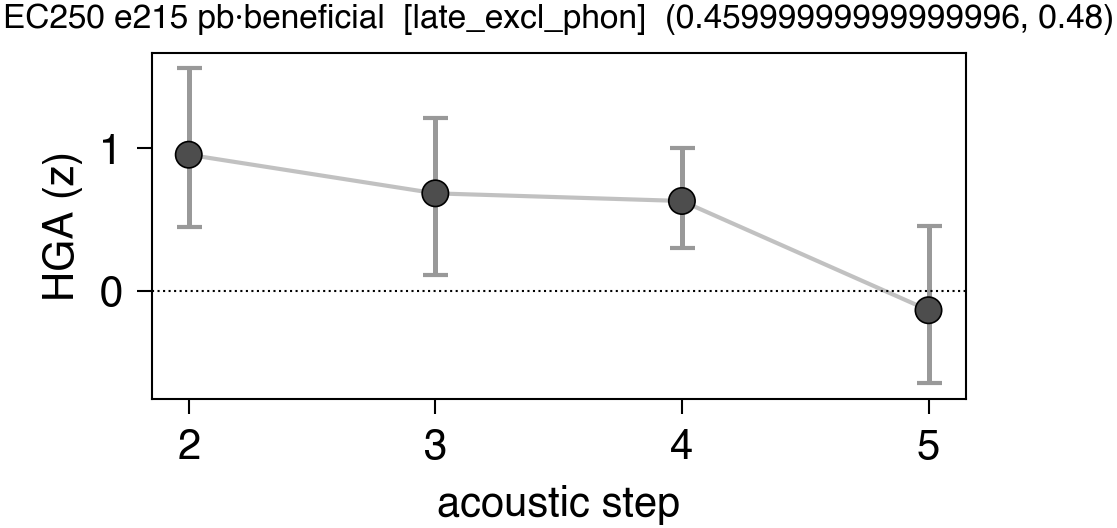

In [183]:
f, ax = plt.subplots(figsize=(3.5, 1.5))
plot_step_tuning(step_tuning,
                 subject="EC250",
                 electrode_idx=215,
                 phoneme_pair="pb",
                 word_end="beneficial",
                 window_kind="late_excl_phon",
                 ax=ax)

### Explo 2: late acoustic regression

In [184]:
row

subject                         EC282
electrode_idx                      84
phoneme_pair                       bm
word_end                    mountains
real_test_roc_auc            0.763889
p_value_target               0.041592
null_mean_target             0.487094
n_permutations_target            5000
significant_target               True
real_ho_test_roc_auc              0.5
p_value_transfer             0.494501
null_mean_transfer           0.498921
n_permutations_transfer          5000
significant_transfer            False
s_early_offset                     80
p_value_target_fdr           0.282229
significant_target_fdr          False
p_value_transfer_fdr         0.972891
significant_transfer_fdr        False
smin                               80
smax                              118
early_test_roc_auc              0.834
early_decoder_smin                 53
early_decoder_smax                 68
Name: 87, dtype: object

In [185]:
# %% Per-trial HGA in each site's late-acoustic window, for a graded step regression
late_acoustic_trial_rows = []

for _, row in tqdm(late_acoustic_windows.iterrows(), total=late_acoustic_windows.shape[0], desc="Extracting late-acoustic HGA"):
    ep_i = epochs_dict[row.subject]
    md_i = ep_i.metadata
    we_mask = (md_i.word_end == row.word_end).values
    if not we_mask.any():
        continue

    data_i = ep_i.copy().apply_baseline((None, 0)).get_data(picks=row.electrode_idx).squeeze(1)
    smin_i, smax_i = int(row.smin_bootstrap), int(row.smax_bootstrap)
    hga_late_i = data_i[:, smin_i:smax_i + 1].mean(axis=1)  # inclusive upper bound, matches how this window is used elsewhere in this notebook

    md_we = md_i[we_mask]
    contrast_sign = np.sign(row.mean_diff_raw_med)
    late_acoustic_trial_rows.append(pd.DataFrame({
        "subject": row.subject,
        "electrode_idx": row.electrode_idx,
        "phoneme_pair": row.phoneme_pair,
        "word_end": row.word_end,
        "epoch_idx": md_we.index,
        "resampled": md_we["resampled"].values,
        "behavior_dummy_forced": md_we["behavior_dummy_forced"].values,
        "contrast_sign": contrast_sign,
        "hga_late_acoustic": hga_late_i[we_mask],
        # sign-flipped by site polarity so a pooled regression slope is
        # interpretable across sites tuned in opposite directions (same
        # convention as mean_diff_aligned elsewhere in this codebase)
        "hga_late_acoustic_aligned": hga_late_i[we_mask] * contrast_sign,
        "smin_bootstrap": smin_i,
        "smax_bootstrap": smax_i,
    }))

late_acoustic_trial_df = pd.concat(late_acoustic_trial_rows, ignore_index=True)
late_acoustic_trial_df.to_csv(FD / "late_acoustic_trial_df.csv", index=False)
late_acoustic_trial_df

Extracting late-acoustic HGA:   0%|          | 0/14 [00:00<?, ?it/s]

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


,subject,electrode_idx,phoneme_pair,word_end,epoch_idx,resampled,behavior_dummy_forced,contrast_sign,hga_late_acoustic,hga_late_acoustic_aligned,smin_bootstrap,smax_bootstrap
0,EC243,87,dn,desolate,1,6.0,1,-1.0,2.701000,-2.701000,70,80
1,EC243,87,dn,desolate,12,3.0,0,-1.0,1.614503,-1.614503,70,80
2,EC243,87,dn,desolate,19,2.0,0,-1.0,-0.103637,0.103637,70,80
3,EC243,87,dn,desolate,22,4.0,0,-1.0,0.816242,-0.816242,70,80
4,EC243,87,dn,desolate,26,5.0,1,-1.0,0.155309,-0.155309,70,80
...,...,...,...,...,...,...,...,...,...,...,...,...
1939,EC282,84,bm,mountains,406,4.0,1,-1.0,2.011118,-2.011118,86,94
1940,EC282,84,bm,mountains,408,3.0,1,-1.0,-0.818018,0.818018,86,94
1941,EC282,84,bm,mountains,410,5.0,1,-1.0,-0.549710,0.549710,86,94
1942,EC282,84,bm,mountains,416,6.0,1,-1.0,1.945187,-1.945187,86,94


In [186]:
# %% Linear mixed-effects: graded acoustic-step effect in the late-acoustic window,
# ambiguous steps only (endpoints 1/6 excluded — those anchor the window's own
# definition, so including them would be circular)
import statsmodels.formula.api as smf

reg_df = late_acoustic_trial_df.query("resampled not in (1, 6)").copy()
reg_df["resampled_centered"] = reg_df["resampled"] - 3.5
reg_df["site"] = (
    reg_df["subject"].astype(str) + "_" + reg_df["electrode_idx"].astype(str) + "_"
    + reg_df["phoneme_pair"] + "_" + reg_df["word_end"]
)
reg_df["subject_electrode_we"] = (
    reg_df["subject"].astype(str) + ":" + reg_df["electrode_idx"].astype(str) + ":" + reg_df["word_end"]
)
model_base = smf.mixedlm(
    "hga_late_acoustic_aligned ~ behavior_dummy_forced",
    data=reg_df, groups=reg_df["subject_electrode_we"],
).fit(reml=False)  # ML, to match an LRT-style comparison
model_full = smf.mixedlm(
    "hga_late_acoustic_aligned ~ resampled_centered + behavior_dummy_forced",
    data=reg_df, groups=reg_df["subject_electrode_we"],
).fit(reml=False)
lr_stat = 2 * (model_full.llf - model_base.llf)
lr_p = stats.chi2.sf(lr_stat, df=1)

RESULTS["late_acoustic_lme_acoustic_coef_p"] = model_full.pvalues["resampled_centered"]
RESULTS["late_acoustic_lme_lr_stat"] = lr_stat
RESULTS["late_acoustic_lme_lr_p"] = lr_p

print(model_base.summary())
print(model_full.summary())
print(stats.chi2.sf(lr_stat, df=1))
print(f"Likelihood ratio test: χ²(1) = {lr_stat:.3f}, p = {1 - stats.chi2.cdf(lr_stat, df=1):.3g}")

                 Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: hga_late_acoustic_aligned
No. Observations: 1296    Method:             ML                       
No. Groups:       14      Scale:              0.4417                   
Min. group size:  48      Log-Likelihood:     -1342.1205               
Max. group size:  96      Converged:          Yes                      
Mean group size:  92.6                                                 
------------------------------------------------------------------------
                         Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------------------
Intercept                -0.232     0.193  -1.204  0.229  -0.610   0.146
behavior_dummy_forced     0.287     0.040   7.112  0.000   0.208   0.367
Group Var                 0.509     0.294                               

                 Mixed Linear Model Regression Results
Model:            M

## Dump results

### First add some methods details

In [187]:
RESULTS["task_responsive_t_threshold"] = cfg["analysis"]["speech_responsive"]["t_threshold"]

In [188]:
RESULTS

{'n_subjects': 10,
 'n_subjects_lh': np.int64(9),
 'e1_word_end': 'desolate',
 'e1_word_end_stripped': 'esolate',
 'e1_word_end_other_phoneme': 'nesolate',
 'e1_behavior_chose_consistent': np.int64(10),
 'e1_behavior_chose_inconsistent': np.int64(14),
 'e1_late_acoustic_decoding_roc_auc': np.float64(0.7118056),
 'e1_late_acoustic_decoding_p': np.float64(0.0303939212157568),
 'e1_late_acoustic_decoding_q': np.float64(0.2659468106378724),
 'e1_late_acoustic_contrast_latency': np.float64(0.33999999999999997),
 'e1_late_perceptual_contrast_latency': np.float64(0.4599999999999999),
 'e1_late_perceptual_contrast_pod_latency': np.float64(0.16299999999999992),
 'e1_late_perceptual_contrast_p': np.float64(0.0076598468030639),
 'e1_late_perceptual_contrast_q': np.float64(0.0727685446291074),
 'e1_early_perceptual_contrast_p': np.float64(0.0014),
 'e1_early_perceptual_contrast_q': np.float64(0.0443333333333333),
 'early_perceptual_acoustic_same_word_pearson_r': np.float64(0.539025387007127),
 'ea

In [189]:
import json
def _jsonable(o):
    if isinstance(o, np.generic):      # int64, float64, bool_, str_
        return o.item()
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(f"{type(o).__name__} is not JSON serializable: {o!r}")

with (FD / "results.json").open("w") as f:
    json.dump(RESULTS, f, indent=4, sort_keys=True, default=_jsonable)